# **CP462 Project:  Will It Rain ?**

# หัวข้อ : **Will It Rain ?**

**สมาชิก:**
<br>
นายก้องภพ เลาหะพิพัฒน์ชัย 66102010231
<br>
นายฐิติวัฒน์ ฮาบสุวรรณ 66102010238
<br>
นางสาว ธนัญญา ธนะเมศฐ์เกศกุล 66102010240

<br><br>
**Dataset:** API ข้อมูลย้อนหลัง <br>
**Source:** https://open-meteo.com/ , https://open-meteo.com/en/docs/historical-weather-api

## **Import Packages**

In [ ]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# อ่านไฟล์พิกัดเขตเข้ามา
df_centroids = pd.read_csv("/content/drive/MyDrive/Rain/bangkok_districts_centroids.csv")
df_weather_district = pd.read_csv("/content/drive/MyDrive/Rain/bangkok_weather_by_district_2021_2024.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# The data fetching and combining steps using the Open-Meteo API for each district
# have been successfully completed in previous cells, resulting in the
# df_combined_weather DataFrame.

# This cell previously contained code to re-fetch and combine the data,
# which was causing file access issues.

# You can now proceed with the Exploratory Data Analysis (EDA)
# using the df_combined_weather DataFrame which contains the
# combined weather data for all districts from 2021 to 2024.
print("Data fetching and combining complete (df_combined_weather is available).")
print("Proceed to the next sections for Data Pre-processing and EDA.")

Data fetching and combining complete (df_combined_weather is available).
Proceed to the next sections for Data Pre-processing and EDA.


In [ ]:
# (สมมติว่า df_weather_district ที่โหลดในขั้นตอนก่อนหน้า ยังอยู่ในหน่วยความจำ)

# ตรวจสอบขนาดข้อมูลและ 5 แถวแรก
print("✅ ข้อมูลฝนรายเขตทั้งหมด (df_weather_district):")
print(f"จำนวนแถวทั้งหมด: {len(df_weather_district):,}") # เพิ่ม : , เพื่อให้มีลูกน้ำ
print(f"จำนวนคอลัมน์ทั้งหมด: {len(df_weather_district.columns)}")
print(df_weather_district.head())
print("-" * 30)

# ตรวจสอบว่ามีกี่เขต
print("จำนวนแถวต่อเขต:")
# เพิ่ม .sort_index() เพื่อให้แสดงผลตามลำดับอักษร (เหมือนในภาพ)
# และ .head() เพื่อแสดงแค่ 5 แถวแรกตามโจทย์
print(df_weather_district['district_en'].value_counts().sort_index().head())

✅ ข้อมูลฝนรายเขตทั้งหมด (df_weather_district):
จำนวนแถวทั้งหมด: 73,050
จำนวนคอลัมน์ทั้งหมด: 7
                        date  max_temp_c  min_temp_c  rainfall_mm  \
0  2021-01-01 00:00:00+07:00   26.513000      17.263          0.0   
1  2021-01-02 00:00:00+07:00   27.213001      18.013          0.0   
2  2021-01-03 00:00:00+07:00   29.163000      18.863          0.0   
3  2021-01-04 00:00:00+07:00   30.263000      20.613          0.0   
4  2021-01-05 00:00:00+07:00   30.613000      21.813          0.0   

   humidity_percent  wind_speed_kmh district_en  
0          59.90733       10.002560    Bang Bon  
1          57.86302       11.792404    Bang Bon  
2          61.21562       12.605142    Bang Bon  
3          61.58714       12.783802    Bang Bon  
4          63.69811       10.137692    Bang Bon  
------------------------------
จำนวนแถวต่อเขต:
district_en
Bang Bon         1461
Bang Kapi        1461
Bang Khae        1461
Bang Khen        1461
Bang Kho Laem    1461
Name: count, dtype: in

# **Data Overview**

In [ ]:
# --- รวมข้อมูลภูมิอากาศรายวันรายเขตกับข้อมูลพิกัดเขต ---
print("\n--- กำลังรวมข้อมูลภูมิอากาศรายวันรายเขตกับข้อมูลพิกัดเขต ---")

# ใช้ pd.merge เพื่อรวม df_weather_district กับ df_centroids
# ใช้คอลัมน์ 'district_en' เป็น key ในการรวม
# how='left' จะเก็บข้อมูลทั้งหมดจาก df_weather_district ไว้
# และนำข้อมูล latitude, longitude จาก df_centroids มาต่อท้ายในแถวที่ 'district_en' ตรงกัน
# หากไม่เจอชื่อเขตที่ตรงกันใน df_centroids ข้อมูล latitude, longitude จะเป็นค่าว่าง (NaN)
merged_weather_df = pd.merge(
    df_weather_district,
    df_centroids[['district_en', 'latitude', 'longitude']], # เลือกเฉพาะคอลัมน์ที่ต้องการจาก df_centroids
    on='district_en',
    how='left'
)

print("\n✅ รวมข้อมูลสำเร็จ! นี่คือ 5 แถวแบบสุ่มของ DataFrame ที่รวมแล้ว:")
display(merged_weather_df.sample(5)) # แสดง 5 แถวแบบสุ่ม

print("\nและนี่คือข้อมูลสรุปของ DataFrame ที่รวมแล้ว:")
merged_weather_df.info()

# เก็บ DataFrame ที่รวมแล้วไว้ในตัวแปรใหม่ เช่น df_combined_weather
df_combined_weather = merged_weather_df

print("\n--- สิ้นสุดการรวมข้อมูล ---")


--- กำลังรวมข้อมูลภูมิอากาศรายวันรายเขตกับข้อมูลพิกัดเขต ---

✅ รวมข้อมูลสำเร็จ! นี่คือ 5 แถวแบบสุ่มของ DataFrame ที่รวมแล้ว:


,date,max_temp_c,min_temp_c,rainfall_mm,humidity_percent,wind_speed_kmh,district_en,latitude,longitude
28423,2022-10-27 00:00:00+07:00,28.487000,24.1870,2.700000,83.768380,13.797913,Khan Na Yao,13.827100,100.674300
63651,2023-04-09 00:00:00+07:00,35.919502,28.0695,2.000000,68.839350,17.283749,Taling Chan,13.776944,100.456667
9558,2023-03-04 00:00:00+07:00,33.237000,21.6870,0.000000,53.648388,19.602652,Bang Na,13.680081,100.591800
13019,2024-08-24 00:00:00+07:00,33.400000,25.7000,5.900001,79.529690,13.755580,Bang Rak,13.730833,100.524167
68303,2024-01-03 00:00:00+07:00,32.950000,22.8500,0.000000,61.406160,14.186923,Thung Khru,13.647200,100.495800



และนี่คือข้อมูลสรุปของ DataFrame ที่รวมแล้ว:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73050 entries, 0 to 73049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              73050 non-null  object 
 1   max_temp_c        73050 non-null  float64
 2   min_temp_c        73050 non-null  float64
 3   rainfall_mm       73050 non-null  float64
 4   humidity_percent  73050 non-null  float64
 5   wind_speed_kmh    73050 non-null  float64
 6   district_en       73050 non-null  object 
 7   latitude          73050 non-null  float64
 8   longitude         73050 non-null  float64
dtypes: float64(7), object(2)
memory usage: 5.0+ MB

--- สิ้นสุดการรวมข้อมูล ---


# **Data manipulate and Cleasing Data**

In [ ]:
# ทำการ Data Manipulation and Cleaning

# 1. จัดการ Missing Values
print("--- Missing values in df_combined_weather ---")

# ตรวจสอบค่าว่างใน df_combined_weather
# .isnull() จะตรวจสอบแต่ละช่องใน DataFrame ว่าเป็นค่าว่าง (NaN) หรือไม่
# .sum() ใช้ต่อจาก .isnull() จะนับจำนวน True ในแต่ละคอลัมน์ ซึ่งก็คือจำนวนค่าว่างในคอลัมน์นั้นๆ
if 'df_combined_weather' in globals():
    print(df_combined_weather.isnull().sum())
else:
    print("DataFrame 'df_combined_weather' not found. Please ensure the previous cell has run successfully.")

# ตรวจสอบค่าว่างใน df_centroids (ข้อมูลพิกัด) อีกครั้งเพื่อยืนยัน
print("\n--- Missing values in df_centroids ---")
if 'df_centroids' in globals():
    print(df_centroids.isnull().sum())
else:
    print("DataFrame 'df_centroids' not found. Please ensure the previous cell has run successfully.")

--- Missing values in df_combined_weather ---
date                0
max_temp_c          0
min_temp_c          0
rainfall_mm         0
humidity_percent    0
wind_speed_kmh      0
district_en         0
latitude            0
longitude           0
dtype: int64

--- Missing values in df_centroids ---
district_en    0
district_th    0
latitude       0
longitude      0
source         0
dtype: int64


## Data Type Conversion

In [ ]:
# 2. Data Type Conversion ยืนยันชนิดข้อมูลของแต่ละคอลัมน์อีกครั้ง
print("\n--- Data types of df_combined_weather ---")
print(df_combined_weather.dtypes)


--- Data types of df_combined_weather ---
date                 object
max_temp_c          float64
min_temp_c          float64
rainfall_mm         float64
humidity_percent    float64
wind_speed_kmh      float64
district_en          object
latitude            float64
longitude           float64
dtype: object


## Handle Duplicates

In [ ]:
# This cell previously contained code to remove duplicates,
# which appears to have removed too much data.
# Removing this step to retain the full dataset.
print("Skipping duplicate removal step to retain full dataset.")

Skipping duplicate removal step to retain full dataset.


In [ ]:
print("\n--- Checking for duplicates in df_combined_weather ---")
# ตรวจสอบข้อมูลซ้ำซ้อน โดยพิจารณาจากคู่ของ 'district_en' และ 'date'
# ถ้ามีแถวที่มีทั้งชื่อเขตและวันที่เหมือนกัน ถือว่าเป็นข้อมูลซ้ำซ้อน
if 'df_combined_weather' in globals():
    duplicates_check = df_combined_weather.duplicated(subset=['district_en', 'date']).sum()
    print(f"Number of duplicates based on district and date: {duplicates_check}")
else:
    print("DataFrame 'df_combined_weather' not found. Please ensure the previous cell has run successfully.")


--- Checking for duplicates in df_combined_weather ---
Number of duplicates based on district and date: 0


In [ ]:
# แสดงผลลัพธ์ของการทำความสะอาดและจัดการข้อมูล
print("=============== Results of Data Cleaning and Manipulation (df_combined_weather) ===============")

# แสดงข้อมูลสรุปของ DataFrame df_combined_weather
print("\n--- Info of the df_combined_weather Data ---")
# ตรวจสอบว่า df_combined_weather มีอยู่จริงก่อนเรียก .info()
if 'df_combined_weather' in globals():
    df_combined_weather.info()

    # แสดงผล 5 แถวแรกของข้อมูล
    print("\n--- Head of the df_combined_weather Data ---")
    display(df_combined_weather.sample(5))

    # แสดงผล 5 แถวสุดท้ายของข้อมูล
    print("\n--- Tail of the df_combined_weather Data ---")
    display(df_combined_weather.sample(5))
else:
    print("DataFrame 'df_combined_weather' not found. Please ensure the preceding cells have run successfully.")

=============== Results of Data Cleaning and Manipulation (df_combined_weather) ===============

--- Info of the df_combined_weather Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73050 entries, 0 to 73049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              73050 non-null  object 
 1   max_temp_c        73050 non-null  float64
 2   min_temp_c        73050 non-null  float64
 3   rainfall_mm       73050 non-null  float64
 4   humidity_percent  73050 non-null  float64
 5   wind_speed_kmh    73050 non-null  float64
 6   district_en       73050 non-null  object 
 7   latitude          73050 non-null  float64
 8   longitude         73050 non-null  float64
dtypes: float64(7), object(2)
memory usage: 5.0+ MB

--- Head of the df_combined_weather Data ---


,date,max_temp_c,min_temp_c,rainfall_mm,humidity_percent,wind_speed_kmh,district_en,latitude,longitude
27212,2023-07-04 00:00:00+07:00,31.193500,26.243500,0.9,80.795970,16.099690,Huai Khwang,13.776667,100.579444
70703,2022-07-30 00:00:00+07:00,32.619500,25.719501,4.0,79.520515,14.565548,Watthana,13.742222,100.585833
44573,2023-01-14 00:00:00+07:00,32.874000,22.974000,0.6,79.649650,14.241630,Phasi Charoen,13.714722,100.437222
7930,2022-09-18 00:00:00+07:00,29.256500,24.506500,8.7,85.885290,14.512064,Bang Khun Thian,13.660833,100.435833
27856,2021-04-08 00:00:00+07:00,31.786999,24.637000,4.6,80.923330,11.885453,Khan Na Yao,13.827100,100.674300



--- Tail of the df_combined_weather Data ---


,date,max_temp_c,min_temp_c,rainfall_mm,humidity_percent,wind_speed_kmh,district_en,latitude,longitude
20013,2023-10-18 00:00:00+07:00,31.869501,24.869501,0.600000,78.650215,11.681987,Chatuchak,13.828611,100.559722
71966,2022-01-13 00:00:00+07:00,32.073997,22.824001,0.000000,73.676380,13.570615,Yan Nawa,13.696944,100.543056
26805,2022-05-23 00:00:00+07:00,30.943500,25.093500,2.200000,80.118410,19.376562,Huai Khwang,13.776667,100.579444
35828,2023-02-04 00:00:00+07:00,33.300000,23.650000,14.000000,80.675550,14.843180,Lat Krabang,13.722317,100.759669
18836,2024-07-28 00:00:00+07:00,28.850000,25.300000,19.600002,87.931970,15.683774,Bueng Kum,13.785278,100.669167


##ตรวจสอบ unique values in key columns (district_en, date)

In [ ]:
# ตรวจสอบ unique values in key columns
print("\n--- Unique Values Check (df_combined_weather) ---")

if 'df_combined_weather' in globals() and not df_combined_weather.empty:
    # ตรวจสอบจำนวนเขตที่ไม่ซ้ำกัน
    print("Number of unique districts:", df_combined_weather['district_en'].nunique())

    # ตรวจสอบปีที่รวมเข้ามา (ดึงจากคอลัมน์ 'date')
    if 'date' in df_combined_weather.columns:
        # แปลง 'date' เป็น datetime ถ้ายังไม่ได้แปลง
        df_combined_weather['date'] = pd.to_datetime(df_combined_weather['date'])
        print("Years included:", df_combined_weather['date'].dt.year.unique())
    else:
        print("Column 'date' not found for checking years.")

    # ตรวจสอบเดือนที่รวมเข้ามา (ดึงจากคอลัมน์ 'date')
    if 'date' in df_combined_weather.columns:
         print("Months included (numerical):", df_combined_weather['date'].dt.month.unique())
    # Note: We might not have individual 'station_name' anymore, but rather district-level data

else:
    print("DataFrame 'df_combined_weather' not found or is empty. Cannot perform unique value check.")


--- Unique Values Check (df_combined_weather) ---
Number of unique districts: 50
Years included: [2021 2022 2023 2024]
Months included (numerical): [ 1  2  3  4  5  6  7  8  9 10 11 12]


## ค่าสถิติพื้นฐาน rainfall

---



In [ ]:
# แสดงค่าสถิติพื้นฐานของ rainfall
print("\n--- Rainfall Statistics (rainfall_mm) ---")
if 'df_combined_weather' in globals() and 'rainfall_mm' in df_combined_weather.columns:
    display(df_combined_weather['rainfall_mm'].describe(include='all'))
else:
    print("DataFrame 'df_combined_weather' or column 'rainfall_mm' not found.")


--- Rainfall Statistics (rainfall_mm) ---


,rainfall_mm
count,73050.000000
mean,5.039180
std,7.690771
min,0.000000
25%,0.000000
50%,1.300000
75%,7.300000
max,76.700000


## คำนวณค่า mode ของคอลัมน์ rainfall_mm

In [ ]:
# คำนวณค่า mode() ของคอลัมน์ 'rainfall_mm'
rainfall_mode = df_combined_weather['rainfall_mm'].mode()

print("\n--- ฐานนิยม (Mode) ของปริมาณน้ำฝน (rainfall_mm) คือ: ---")
display(rainfall_mode)


--- ฐานนิยม (Mode) ของปริมาณน้ำฝน (rainfall_mm) คือ: ---


,rainfall_mm
0,0.0


# **Transforming**
ทำความสะอาดชื่อคอลัมน์ทั้งหมด และเพิ่มคอลัมน์ year โดยดึงข้อมูลมาจากชื่อของชีต (sn) และเพิ่มคอลัมน์ date โดยการรวมข้อมูลจากคอลัมน์ปีและเดือน

In [ ]:
import pandas as pd

# เลือก DataFrame ที่ต้องการแปลงข้อมูล
# ในที่นี้คือ df_combined_weather ที่ได้จากการรวมข้อมูลภูมิอากาศรายวันรายเขต
df_transform = df_combined_weather.copy()

print("--- เริ่มต้นขั้นตอน Transforming ---")

# 1. ทำความสะอาดชื่อคอลัมน์ทั้งหมด
print("\nกำลังทำความสะอาดชื่อคอลัมน์...")
# ทำความสะอาดชื่อคอลัมน์: ลบช่องว่างนำหน้า/ต่อท้าย, แทนที่ช่องว่างด้วย _, เปลี่ยนเป็นตัวพิมพ์เล็ก
df_transform.columns = (df_transform.columns.map(str).str.strip()
                           .str.replace(r'\s+', '_', regex=True) # แทนที่ช่องว่างด้วย_
                           .str.lower()) # เปลี่ยนเป็นตัวพิมพ์เล็ก
print("✅ ทำความสะอาดชื่อคอลัมน์สำเร็จ")
print("ชื่อคอลัมน์ใหม่:", df_transform.columns.tolist())


# 2. ตรวจสอบและยืนยันชนิดข้อมูลของคอลัมน์ 'date'
print("\nกำลังตรวจสอบชนิดข้อมูลของคอลัมน์ 'date'...")
# แปลงคอลัมน์ 'date' ให้เป็น datetime object (ถ้ายังไม่ได้แปลง)
# errors='coerce' จะทำให้ค่าที่ไม่สามารถแปลงได้กลายเป็น NaT (Not a Time)
df_transform['date'] = pd.to_datetime(df_transform['date'], errors='coerce')

# ตรวจสอบว่ามีค่า NaT (ค่าที่แปลงไม่ได้) เกิดขึ้นหรือไม่
if df_transform['date'].isnull().sum() > 0:
    print("⚠️ พบค่าที่ไม่สามารถแปลงเป็น datetime ได้ในคอลัมน์ 'date'")
else:
    print("✅ คอลัมน์ 'date' เป็นชนิดข้อมูล datetime ที่ถูกต้อง")

print("ชนิดข้อมูลของคอลัมน์ 'date' หลังแปลง:", df_transform['date'].dtype)

# หากต้องการแยกปี เดือน วัน ออกมาเป็นคอลัมน์ใหม่ สามารถทำได้ดังนี้:
# df_transform['year'] = df_transform['date'].dt.year
# df_transform['month'] = df_transform['date'].dt.month
# df_transform['day'] = df_transform['date'].dt.day


print("\n--- สิ้นสุดขั้นตอน Transforming ---")

# สามารถเก็บ DataFrame ที่แปลงแล้วไว้ในตัวแปรใหม่ หรือใช้ชื่อเดิมก็ได้
# เช่น: df_transformed_weather = df_transform
# ในที่นี้จะอัปเดต df_combined_weather เพื่อให้โค้ดส่วนที่เหลือทำงานได้ต่อเนื่อง
df_combined_weather = df_transform

print("\n✅ ข้อมูลหลังการแปลง (5 แถว):")
display(df_combined_weather.sample(5))

--- เริ่มต้นขั้นตอน Transforming ---

กำลังทำความสะอาดชื่อคอลัมน์...
✅ ทำความสะอาดชื่อคอลัมน์สำเร็จ
ชื่อคอลัมน์ใหม่: ['date', 'max_temp_c', 'min_temp_c', 'rainfall_mm', 'humidity_percent', 'wind_speed_kmh', 'district_en', 'latitude', 'longitude']

กำลังตรวจสอบชนิดข้อมูลของคอลัมน์ 'date'...
✅ คอลัมน์ 'date' เป็นชนิดข้อมูล datetime ที่ถูกต้อง
ชนิดข้อมูลของคอลัมน์ 'date' หลังแปลง: datetime64[ns, UTC+07:00]

--- สิ้นสุดขั้นตอน Transforming ---

✅ ข้อมูลหลังการแปลง (5 แถว):


,date,max_temp_c,min_temp_c,rainfall_mm,humidity_percent,wind_speed_kmh,district_en,latitude,longitude
14845,2021-08-24 00:00:00+07:00,32.756500,24.956501,16.600000,79.597946,17.577440,Bangkok Noi,13.770867,100.467933
30293,2023-12-10 00:00:00+07:00,32.323997,23.824001,0.000000,76.421990,6.763786,Khlong Sam Wa,13.859722,100.704167
23366,2024-12-22 00:00:00+07:00,29.500000,21.600000,0.000000,49.877970,12.982480,Din Daeng,13.769722,100.552778
56659,2024-02-16 00:00:00+07:00,34.424000,24.924002,0.200000,75.776985,14.759999,Sai Mai,13.919167,100.645833
56896,2024-10-10 00:00:00+07:00,32.024000,24.624000,8.300001,85.904120,14.545515,Sai Mai,13.919167,100.645833


# **Validating**

Validating ของข้อมูลก่อนหน้านี้

In [ ]:
# Data Validation for df_combined_weather

import pandas as pd
import numpy as np

print("=============== Data Validation (df_combined_weather) ===============")
print("   (การตรวจสอบความถูกต้องของข้อมูลตามกฎเกณฑ์)")

# ใช้ DataFrame ที่รวมและทำความสะอาดแล้ว
if 'df_combined_weather' in globals() and not df_combined_weather.empty:
    df_validate = df_combined_weather.copy()

    print(f"\nขนาดของ DataFrame ที่กำลังตรวจสอบ: {df_validate.shape}")


    # 1. ตรวจสอบค่าว่างในคอลัมน์ที่สำคัญ
    print("\n--- 1. Checking for missing values in key columns ---")
    # คอลัมน์ที่คาดว่าไม่ควรมีค่าว่างหลังจาก Cleaning
    key_cols = ['date', 'district_en', 'rainfall_mm', 'max_temp_c', 'min_temp_c', 'humidity_percent', 'wind_speed_kmh', 'latitude', 'longitude']
    # ตรวจสอบว่าคอลัมน์ที่ต้องการมีอยู่ใน DataFrame ก่อนเรียก isnull().sum()
    existing_key_cols = [col for col in key_cols if col in df_validate.columns]
    if existing_key_cols:
        print("Missing values per column:")
        print(df_validate[existing_key_cols].isnull().sum())
    else:
        print("Key columns not found in the DataFrame for missing value check.")


    # 2. ตรวจสอบ Data Types ของคอลัมน์ที่สำคัญ
    print("\n--- 2. Checking Data Types of key columns ---")
    if existing_key_cols:
        print("Data types per column:")
        print(df_validate[existing_key_cols].dtypes)
    else:
         print("Key columns not found in the DataFrame for data type check.")


    # 3. ตรวจสอบข้อมูลซ้ำซ้อน (ถ้ายังไม่ได้ลบออกไปในขั้นตอน Cleaning)
    # ตรวจสอบข้อมูลซ้ำซ้อน โดยพิจารณาจากคู่ของ 'district_en' และ 'date'
    print("\n--- 3. Checking for duplicates based on district and date ---")
    if 'district_en' in df_validate.columns and 'date' in df_validate.columns:
        duplicates_check = df_validate.duplicated(subset=['district_en', 'date']).sum()
        print(f"Number of duplicates based on district and date: {duplicates_check}")
        if duplicates_check > 0:
            print("Warning: Duplicates found based on district and date. Consider dropping them if each district should have only one entry per day.")
            # Optional: Uncomment the line below to drop duplicates
            # df_combined_weather = df_combined_weather.drop_duplicates(subset=['district_en', 'date']).reset_index(drop=True)
            # print(f"Number of rows after dropping duplicates: {len(df_combined_weather)}")
        else:
            print("No duplicates found based on district and date.")
    else:
        print("Columns 'district_en' or 'date' not found for duplicate check.")


    # 4. ตรวจสอบค่าปริมาณน้ำฝนให้อยู่ในเกณฑ์ที่สมเหตุสมผล (เช่น ไม่ติดลบ)
    print("\n--- 4. Checking for non-negative rainfall ---")
    if 'rainfall_mm' in df_validate.columns:
        negative_rainfall = df_validate[df_validate['rainfall_mm'] < 0]
        if not negative_rainfall.empty:
            print(f"พบข้อมูลปริมาณน้ำฝนติดลบ: {len(negative_rainfall)} แถว")
            print("ตัวอย่างข้อมูลที่พบ:")
            display(negative_rainfall.head())
        else:
            print("ไม่พบข้อมูลปริมาณน้ำฝนติดลบ ข้อมูลถูกต้องตามเงื่อนไขเบื้องต้น")
    else:
        print("Column 'rainfall_mm' not found for non-negative check.")
    print("-" * 30)

    # 5. ตรวจสอบค่าอุณหภูมิสูงสุดและต่ำสุดให้อยู่ในเกณฑ์ที่สมเหตุสมผล (ตัวอย่าง)
    print("\n--- 5. Checking temperature ranges (example) ---")
    if 'max_temp_c' in df_validate.columns and 'min_temp_c' in df_validate.columns:
        # กำหนดช่วงอุณหภูมิที่สมเหตุสมผลสำหรับกรุงเทพฯ (ตัวอย่าง)
        min_reasonable_temp = 10 # องศาเซลเซียส
        max_reasonable_temp = 45 # องศาเซลเซียส

        invalid_max_temp = df_validate[(df_validate['max_temp_c'] < min_reasonable_temp) | (df_validate['max_temp_c'] > max_reasonable_temp)]
        invalid_min_temp = df_validate[(df_validate['min_temp_c'] < min_reasonable_temp) | (df_validate['min_temp_c'] > max_reasonable_temp)]

        if not invalid_max_temp.empty:
            print(f"พบข้อมูลอุณหภูมิสูงสุดนอกช่วง ({min_reasonable_temp} - {max_reasonable_temp}°C): {len(invalid_max_temp)} แถว")
            print("ตัวอย่างข้อมูลที่พบ:")
            display(invalid_max_temp.head())
        else:
            print(f"ไม่พบข้อมูลอุณหภูมิสูงสุดนอกช่วง ({min_reasonable_temp} - {max_reasonable_temp}°C) ข้อมูลถูกต้องตามเงื่อนไข")

        if not invalid_min_temp.empty:
            print(f"พบข้อมูลอุณหภูมิต่ำสุดนอกช่วง ({min_reasonable_temp} - {max_reasonable_temp}°C): {len(invalid_min_temp)} แถว")
            print("ตัวอย่างข้อมูลที่พบ:")
            display(invalid_min_temp.head())
        else:
            print(f"ไม่พบข้อมูลอุณหภูมิต่ำสุดนอกช่วง ({min_reasonable_temp} - {max_reasonable_temp}°C) ข้อมูลถูกต้องตามเงื่อนไข")
    else:
        print("Columns 'max_temp_c' or 'min_temp_c' not found for range check.")
    print("-" * 30)


    # 6. ตรวจสอบค่า Latitude และ Longitude ให้อยู่ในช่วงที่เหมาะสมสำหรับกรุงเทพฯ
    # ใช้ชื่อคอลัมน์ที่ถูกต้อง: 'latitude' และ 'longitude' จาก df_combined_weather
    print("\n--- 6. Checking Latitude and Longitude ranges ---")
    if 'latitude' in df_validate.columns and 'longitude' in df_validate.columns:
         # ใช้ค่า min/max จาก df_centroids หากมี เพื่อกำหนดช่วงที่สมเหตุสมผล
        min_lat = df_centroids['latitude'].min() if 'df_centroids' in globals() and not df_centroids.empty else 13.4
        max_lat = df_centroids['latitude'].max() if 'df_centroids' in globals() and not df_centroids.empty else 14.1
        min_lon = df_centroids['longitude'].min() if 'df_centroids' in globals() and not df_centroids.empty else 100.3
        max_lon = df_centroids['longitude'].max() if 'df_centroids' in globals() and not df_centroids.empty else 100.9


         # ค้นหาแถวที่ Latitude ไม่อยู่ในช่วงที่กำหนด
        invalid_lat = df_validate[(df_validate['latitude'] < min_lat) | (df_validate['latitude'] > max_lat)]
        if not invalid_lat.empty:
            print(f"พบข้อมูล Latitude นอกช่วง ({min_lat:.4f} - {max_lat:.4f}): {len(invalid_lat)} แถว")
            print("ตัวอย่างข้อมูลที่พบ:")
            display(invalid_lat.head())
        else:
            print(f"ไม่พบข้อมูล Latitude นอกช่วง ({min_lat:.4f} - {max_lat:.4f}) ข้อมูลถูกต้องตามเงื่อนไข")

        # ค้นหาแถวที่ Longitude ไม่อยู่ในช่วงที่กำหนด
        invalid_lon = df_validate[(df_validate['longitude'] < min_lon) | (df_validate['longitude'] > max_lon)]
        if not invalid_lon.empty:
            print(f"พบข้อมูล Longitude นอกช่วง ({min_lon:.4f} - {max_lon:.4f}): {len(invalid_lon)} แถว")
            print("ตัวอย่างข้อมูลที่พบ:")
            display(invalid_lon.head())
        else:
            print(f"ไม่พบข้อมูล Longitude นอกช่วง ({min_lon:.4f} - {max_lon:.4f}) ข้อมูลถูกต้องตามเงื่อนไข")
    else:
        print("Columns 'latitude' or 'longitude' not found for range check.")
    print("-" * 30)


    print("\n[สรุป Data Validation]")
    print("ได้ทำการตรวจสอบความถูกต้องเบื้องต้นสำหรับข้อมูลภูมิอากาศรายวันรายเขตแล้ว")
    # คุณสามารถเพิ่มกฎเกณฑ์การตรวจสอบอื่นๆ ได้ตามความต้องการของโปรเจค

else:
    print("\ndf_combined_weather DataFrame not found or is empty. Cannot perform validation.")

=============== Data Validation (df_combined_weather) ===============
   (การตรวจสอบความถูกต้องของข้อมูลตามกฎเกณฑ์)

ขนาดของ DataFrame ที่กำลังตรวจสอบ: (73050, 9)

--- 1. Checking for missing values in key columns ---
Missing values per column:
date                0
district_en         0
rainfall_mm         0
max_temp_c          0
min_temp_c          0
humidity_percent    0
wind_speed_kmh      0
latitude            0
longitude           0
dtype: int64

--- 2. Checking Data Types of key columns ---
Data types per column:
date                datetime64[ns, UTC+07:00]
district_en                            object
rainfall_mm                           float64
max_temp_c                            float64
min_temp_c                            float64
humidity_percent                      float64
wind_speed_kmh                        float64
latitude                              float64
longitude                             float64
dtype: object

--- 3. Checking for duplicates based on distr

# **Enriching**

แก้ไขชื่อคอลัมน์เป้าหมายจาก 'Rainfall_mm' เป็น 'rainfall_mm' ให้ตรงกับ df_combined_weather

In [ ]:
import numpy as np
import pandas as pd


# แก้ไขชื่อคอลัมน์เป้าหมายจาก 'Rainfall_mm' เป็น 'rainfall_mm' ให้ตรงกับ df_combined_weather
TARGET_COLUMN = 'rainfall_mm'

# ------------------------------
# เลือก DataFrame
# ------------------------------
# ใช้ df_combined_weather โดยตรง
if 'df_combined_weather' in globals():
    _df = df_combined_weather.copy()
    print(f"ใช้ DataFrame: `df_combined_weather`")
else:
    raise NameError("ไม่พบ DataFrame `df_combined_weather` — โปรดตรวจสอบว่าได้สร้างขึ้นแล้ว")

if TARGET_COLUMN not in _df.columns:
    raise KeyError(f"ไม่พบคอลัมน์ {TARGET_COLUMN} ใน DataFrame ที่เลือก")

# ทำสำเนาคอลัมน์เดือน/เขตแบบกันพัง (รองรับทั้งตัวใหญ่/เล็ก)
_month_col = 'month' if 'month' in _df.columns else ('month_name' if 'month_name' in _df.columns else None)
_district_col = 'district_en' if 'district_en' in _df.columns else None

# มาตรฐานค่าที่จะสรุป (ตัด NaN)
s = pd.to_numeric(_df[TARGET_COLUMN], errors='coerce').dropna()

# ==============================
# 1) Measures of Central Tendency (แนวโน้มเข้าสู่ส่วนกลาง)
# ==============================
# Mean (ค่าเฉลี่ย): ผลรวม ÷ จำนวน
mean_val = s.mean()

# Median (ค่ากึ่งกลาง): ค่าตรงกลางเมื่อเรียงข้อมูลจากน้อยไปมาก
median_val = s.median()

# Mode (ฐานนิยม): ค่าที่พบบ่อยที่สุด (ถ้ามีหลายค่าจะคืนค่าตัวแรก)
mode_vals = s.mode()
mode_val = mode_vals.iloc[0] if not mode_vals.empty else np.nan

# ==============================
# 2) Measures of Dispersion (การกระจาย)
# ==============================
# Range: ค่าสูงสุด – ค่าต่ำสุด
range_val = s.max() - s.min()

# Variance (ความแปรปรวน): ค่าเฉลี่ยของกำลังสองของความคลาดเคลื่อนจากค่าเฉลี่ย
var_val = s.var(ddof=1)  # ddof=1 สำหรับ sample variance

# Standard Deviation (ส่วนเบี่ยงเบนมาตรฐาน): รากที่สองของ variance
std_val = s.std(ddof=1)

# Interquartile Range (IQR): Q3 - Q1 (ส่วนระหว่างควอไทล์ที่ 1 และ 3)
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr_val = q3 - q1

# ==============================
# 3) Shape of Distribution (รูปร่างการแจกแจง)
# ==============================
# Skewness (การเบ้): >0 เบ้ขวา, <0 เบ้ซ้าย, ≈0 สมมาตร
skew_val = s.skew()

# Kurtosis (ความแหลม/ป้าน): ใช้ "excess kurtosis" ของ pandas
#    = 0 ใกล้ปกติ, >0 แหลม (heavy tails), <0 ป้าน (light tails)
kurtosis_excess = s.kurtosis()

# ฟังก์ชันตีความอย่างง่าย (optional)
def interpret_skew(x):
    if np.isnan(x): return "N/A"
    if x > 0.5:   return "เบ้ขวา (ค่ามาก ๆ โผล่บ่อยกว่าด้านซ้าย)"
    if x < -0.5:  return "เบ้ซ้าย (ค่าน้อย ๆ โผล่บ่อยกว่าด้านขวา)"
    return "ค่อนข้างสมมาตร"
def interpret_kurtosis(x):
    if np.isnan(x): return "N/A"
    if x > 0.5:   return "แหลม/หางหนัก (outliers ปลายหางมาก)"
    if x < -0.5:  return "ป้าน/หางเบา (กระจุกกลางมาก)"
    return "ใกล้ปกติ"

# ==============================
# สรุปผลรวมเป็นตารางเดียว
# ==============================
summary = pd.DataFrame({
    'Metric': [
        'Mean (ค่าเฉลี่ย)',
        'Median (ค่ากึ่งกลาง)',
        'Mode (ฐานนิยม)',
        'Range (max - min)',
        'Variance (ความแปรปรวน)',
        'Std. Dev. (ส่วนเบี่ยงเบนมาตรฐาน)',
        'Q1 (ควอไทล์ที่ 1)',
        'Q3 (ควอไทล์ที่ 3)',
        'IQR (Q3 - Q1)',
        'Skewness (การเบ้)',
        'Kurtosis (Excess ความแหลม/ป้าน)'
    ],
    'Value': [
        mean_val, median_val, mode_val, range_val, var_val, std_val,
        q1, q3, iqr_val, skew_val, kurtosis_excess
    ],
    'Interpretation (คำอธิบายสั้น ๆ)': [
        'แนวโน้มโดยรวมของค่า',
        'ค่ากึ่งกลาง ทน outlier ได้ดีกว่า mean',
        'ค่าที่เกิดบ่อยสุด (อาจมีหลายค่า)',
        'ช่วงการกระจายกว้างแค่ไหน',
        'ความผันผวนเฉลี่ยกำลังสอง',
        'ความผันผวนในหน่วยเดียวกับข้อมูล',
        'ค่าที่ 25% แรกของข้อมูล',
        'ค่าที่ 75% แรกของข้อมูล',
        'กระจายกลาง 50% ของข้อมูล',
        interpret_skew(skew_val),
        interpret_kurtosis(kurtosis_excess)
    ]
})

print("=== Descriptive Statistics (รวมทั้งชุดข้อมูล) ===")
display(summary)

# ==============================
# (ทางเลือก) สรุปแบบ Grouped: ตามเดือน/เขต ถ้ามีคอลัมน์เหล่านี้
# ==============================
def iqr_func(x):  # ฟังก์ชัน IQR สำหรับ agg
    x = pd.to_numeric(x, errors='coerce').dropna()
    if x.empty: return np.nan
    return x.quantile(0.75) - x.quantile(0.25)

def grouped_desc(df, group_col, target_col):
    """สรุป Descriptive แบบแยกกลุ่ม พร้อมสถิติหลัก"""
    g = (df.groupby(group_col)[target_col]
           .agg(count='count',
                mean='mean',
                median='median',
                std='std',
                min='min',
                q1=lambda x: pd.to_numeric(x, errors='coerce').quantile(0.25),
                q3=lambda x: pd.to_numeric(x, errors='coerce').quantile(0.75),
                max='max',
                iqr=iqr_func,
                skew=lambda x: pd.to_numeric(x, errors='coerce').skew(),
                kurtosis=lambda x: pd.to_numeric(x, errors='coerce').kurtosis())
           .reset_index())
    return g

# ---- สรุปตาม "เดือน" (ถ้ามีคอลัมน์เดือน) ----
# สร้างคอลัมน์เดือนและปีจากคอลัมน์ date
if 'date' in _df.columns:
    _df['_year_'] = _df['date'].dt.year
    _df['_month_'] = _df['date'].dt.month
    _df['_month_name_'] = _df['date'].dt.strftime('%B') # ใช้ชื่อเดือนเต็ม

    if '_month_name_' is not None:
        month_order = ['January','February','March','April','May','June',
                       'July','August','September','October','November','December']

        month_stats = grouped_desc(_df, '_month_name_', TARGET_COLUMN)
        # จัดเรียงตามเดือน
        month_stats['_order'] = month_stats['_month_name_'].map({m:i for i,m in enumerate(month_order)})
        month_stats = month_stats.sort_values('_order', na_position='last').drop(columns=['_order'])

        print("\n=== Descriptive by Month ===")
        display(month_stats)

# ---- สรุปตาม "เขต" (ถ้ามีคอลัมน์เขต) ----
if _district_col is not None:
    district_stats = grouped_desc(_df, _district_col, TARGET_COLUMN)
    # แสดงเฉพาะ Top-N ตามจำนวนข้อมูล (อ่านง่าย)
    topN = (district_stats.sort_values('count', ascending=False)
                        .head(20))
    print("\n=== Descriptive by District (Top 20 by count) ===")
    display(topN)

ใช้ DataFrame: `df_combined_weather`
=== Descriptive Statistics (รวมทั้งชุดข้อมูล) ===


<>:151: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:151: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?


,Metric,Value,Interpretation (คำอธิบายสั้น ๆ)
0,Mean (ค่าเฉลี่ย),5.039180,แนวโน้มโดยรวมของค่า
1,Median (ค่ากึ่งกลาง),1.300000,ค่ากึ่งกลาง ทน outlier ได้ดีกว่า mean
2,Mode (ฐานนิยม),0.000000,ค่าที่เกิดบ่อยสุด (อาจมีหลายค่า)
3,Range (max - min),76.700000,ช่วงการกระจายกว้างแค่ไหน
4,Variance (ความแปรปรวน),59.147952,ความผันผวนเฉลี่ยกำลังสอง
5,Std. Dev. (ส่วนเบี่ยงเบนมาตรฐาน),7.690771,ความผันผวนในหน่วยเดียวกับข้อมูล
6,Q1 (ควอไทล์ที่ 1),0.000000,ค่าที่ 25% แรกของข้อมูล
7,Q3 (ควอไทล์ที่ 3),7.300000,ค่าที่ 75% แรกของข้อมูล
8,IQR (Q3 - Q1),7.300000,กระจายกลาง 50% ของข้อมูล
9,Skewness (การเบ้),2.389789,เบ้ขวา (ค่ามาก ๆ โผล่บ่อยกว่าด้านซ้าย)


/tmp/ipython-input-3183415389.py:151: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if '_month_name_' is not None:



=== Descriptive by Month ===


,_month_name_,count,mean,median,std,min,q1,q3,max,iqr,skew,kurtosis
4,January,6200,0.380355,0.000000,2.012481,0.0,0.0,0.000000,45.600000,0.000000,11.318557,165.982694
3,February,5650,2.042319,0.000000,6.290311,0.0,0.0,1.000000,76.700000,1.000000,5.985561,45.638471
7,March,6200,1.769855,0.400000,3.949175,0.0,0.0,1.700000,45.599995,1.700000,4.928739,32.719522
0,April,6000,3.053750,0.500000,5.782191,0.0,0.0,3.900000,49.800003,3.900000,3.565233,16.747246
8,May,6200,6.427129,2.700000,9.093136,0.0,0.5,8.700000,60.700005,8.200000,2.453318,7.493371
6,June,6000,5.476667,3.400000,6.184370,0.0,1.0,7.700000,50.999996,6.700000,1.948795,4.534102
5,July,6200,8.812871,6.500000,8.118914,0.0,2.6,12.700001,56.200000,10.100001,1.425796,2.015813
1,August,6200,8.075871,6.000000,8.069061,0.0,2.4,10.600000,61.399998,8.200000,1.952380,4.827656
11,September,6000,12.318533,10.799999,8.984414,0.0,5.4,17.700000,63.400000,12.300000,1.018658,1.521462
10,October,6200,8.150145,4.799999,9.701163,0.0,0.6,12.500000,67.600006,11.900000,1.774696,4.059473



=== Descriptive by District (Top 20 by count) ===


,district_en,count,mean,median,std,min,q1,q3,max,iqr,skew,kurtosis
0,Bang Bon,1461,4.813826,1.4,7.539275,0.0,0.0,6.700000,60.000004,6.700000,2.580321,8.801884
1,Bang Kapi,1461,4.951814,1.4,7.474782,0.0,0.0,7.299999,56.400005,7.299999,2.372368,7.444093
2,Bang Khae,1461,4.813826,1.4,7.539275,0.0,0.0,6.700000,60.000004,6.700000,2.580321,8.801884
3,Bang Khen,1461,5.375907,1.2,8.292214,0.0,0.0,8.000000,76.700000,8.000000,2.489263,9.012517
4,Bang Kho Laem,1461,4.833949,1.2,7.591461,0.0,0.0,6.700000,63.600000,6.700000,2.540800,8.419834
5,Bang Khun Thian,1461,4.813826,1.4,7.539275,0.0,0.0,6.700000,60.000004,6.700000,2.580321,8.801884
6,Bang Na,1461,5.227173,1.5,8.037719,0.0,0.0,7.399999,63.400000,7.399999,2.412416,7.369982
7,Bang Phlat,1461,5.205134,1.4,7.806098,0.0,0.0,7.900000,60.700005,7.900000,2.412543,8.206305
8,Bang Rak,1461,4.824983,1.3,7.374072,0.0,0.0,7.000000,56.800003,7.000000,2.411298,7.559279
9,Bang Sue,1461,5.205134,1.4,7.806098,0.0,0.0,7.900000,60.700005,7.900000,2.412543,8.206305


บันทึกไฟล์ที่ได้รับการทำความสะอาดแล้ว

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# กำหนดพาธสำหรับบันทึกไฟล์
output_path = "/content/drive/MyDrive/Rain/bangkok_weather_cleaned_data.csv"

# ตรวจสอบว่า df_combined_weather มีอยู่จริงก่อนบันทึก
if 'df_combined_weather' in globals() and not df_combined_weather.empty:
    # บันทึก DataFrame เป็นไฟล์ CSV โดยไม่รวม index
    df_combined_weather.to_csv(output_path, index=False)
    print(f"✅ บันทึกไฟล์ข้อมูลที่ทำความสะอาดแล้วไปที่: {output_path}")
else:
    print("❌ ไม่พบ DataFrame 'df_combined_weather' หรือ DataFrame ว่างเปล่า ไม่สามารถบันทึกได้")


Mounted at /content/drive
✅ บันทึกไฟล์ข้อมูลที่ทำความสะอาดแล้วไปที่: /content/drive/MyDrive/Rain/bangkok_weather_cleaned_data.csv


### **ไฟล์ข้อมูลที่ทำความสะอาดและจัดเตรียมพร้อมใช้งาน (Cleaned and Prepared Data File)**

ไฟล์ `bangkok_weather_cleaned_data.csv` ที่ถูกบันทึกไว้ใน Google Drive ของคุณตอนนี้ คือข้อมูลสภาพอากาศรายเขตของกรุงเทพมหานคร ตั้งแต่ปี 2021-2024 ที่ผ่านขั้นตอนการรวม การทำความสะอาด และการจัดรูปแบบมาเรียบร้อยแล้ว:

*   **รวมข้อมูล:** รวมข้อมูลจากทุกแหล่งเข้าไว้ด้วยกัน
*   **จัดการค่าว่าง/ข้อผิดพลาด:** ตรวจสอบและจัดการค่าที่ขาดหายไปหรือผิดปกติ
*   **แปลงชนิดข้อมูล:** ปรับชนิดข้อมูลให้ถูกต้องและเหมาะสมกับการวิเคราะห์
*   **สร้างคอลัมน์ใหม่:** เพิ่มคอลัมน์ที่เป็นประโยชน์ เช่น ปี เดือน หรือกลุ่มของปริมาณน้ำฝน

ข้อมูลนี้พร้อมแล้วสำหรับการนำไปใช้ในการวิเคราะห์เชิงลึก, การสร้างโมเดล Machine Learning, หรือการสร้าง Dashboard แสดงผลต่อไป


ใช้ DataFrame: `df_combined_weather`

=============== Univariate Analysis (Numerical) ===============


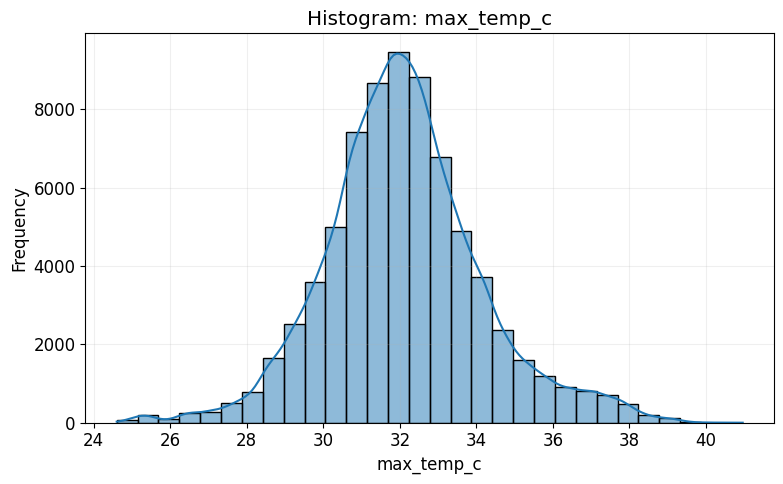

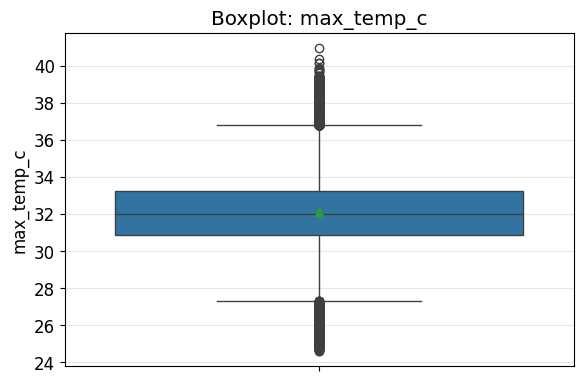

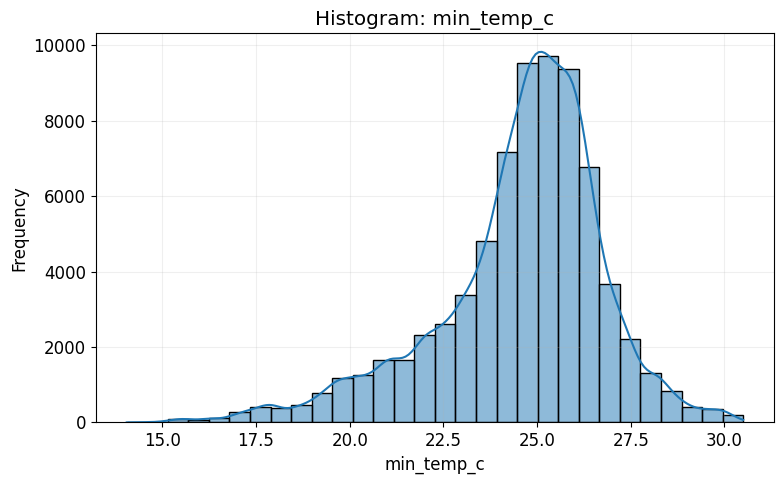

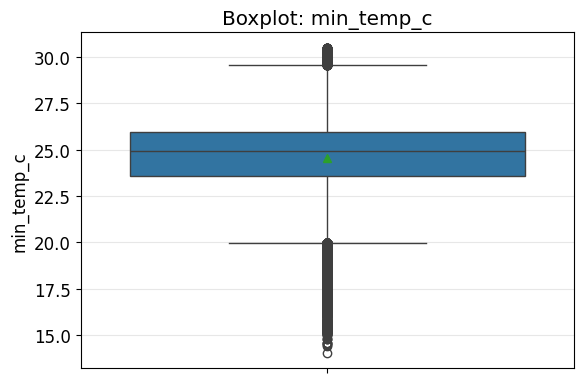

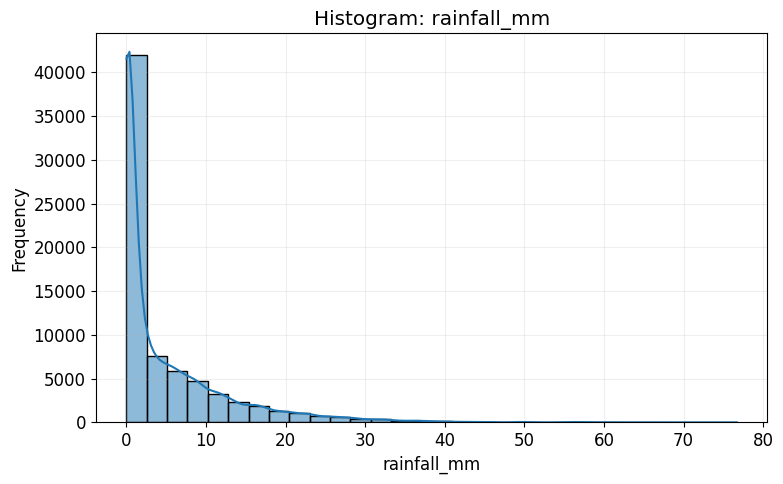

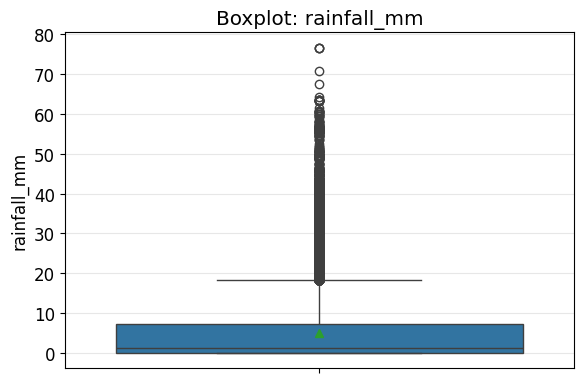

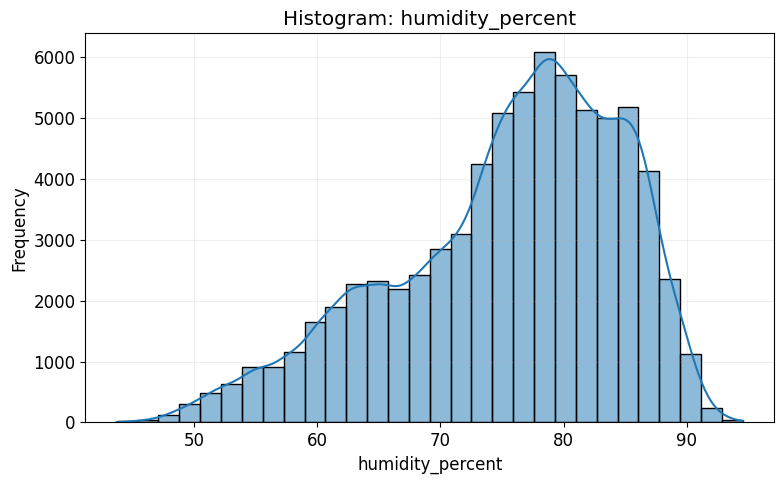

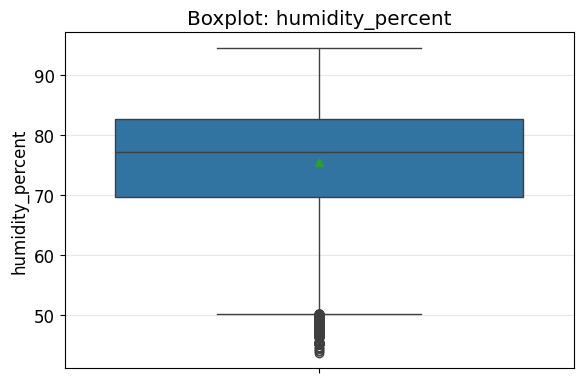

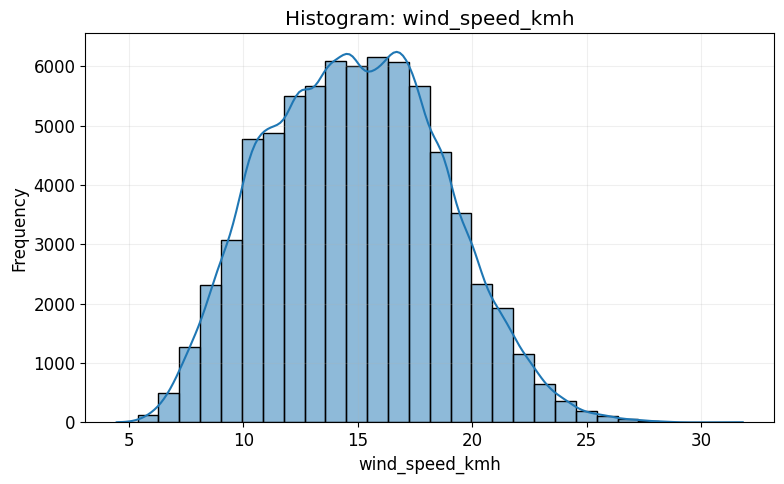

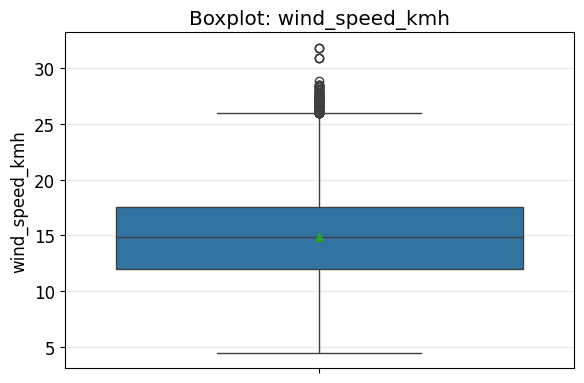

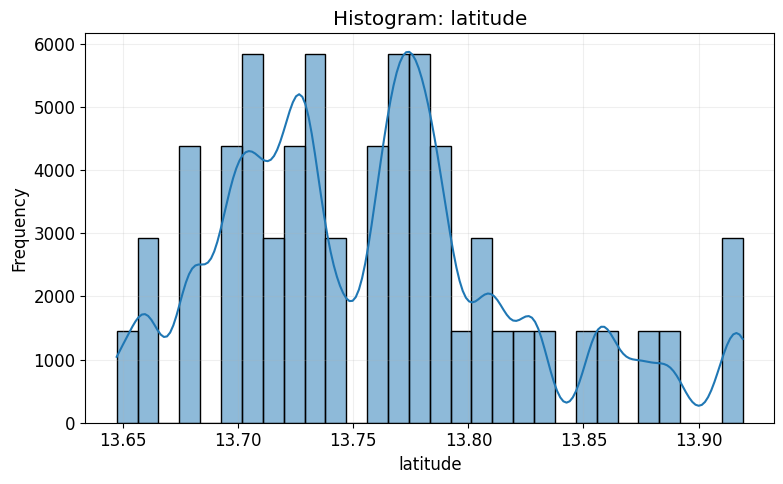

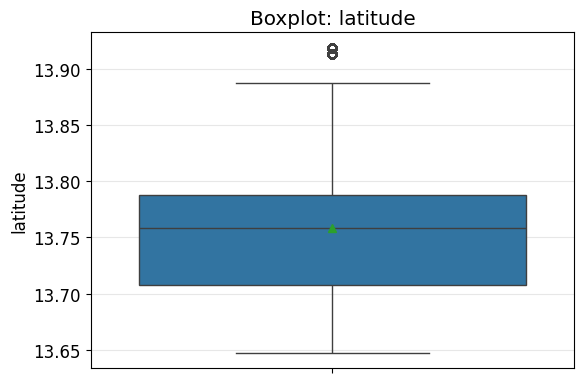

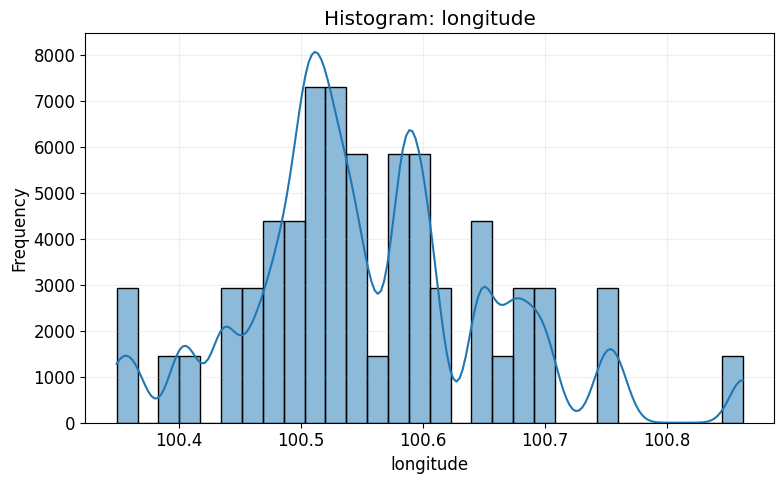

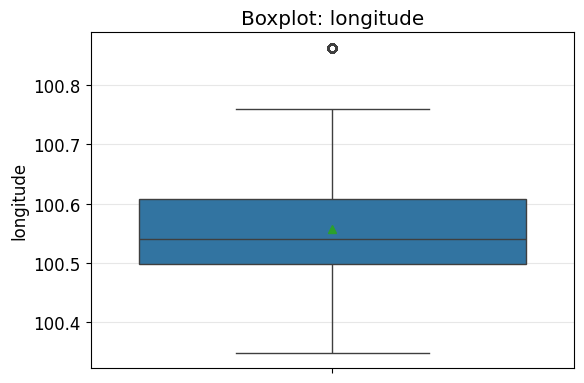


=============== Univariate Analysis (Categorical) ===============

=== Frequency Table: district_en ===


,district_en,count,percent
0,Bang Bon,1461,2.0
1,Bang Kapi,1461,2.0
2,Bang Khae,1461,2.0
3,Bang Khen,1461,2.0
4,Bang Kho Laem,1461,2.0
5,Bang Khun Thian,1461,2.0
6,Bang Na,1461,2.0
7,Bang Phlat,1461,2.0
8,Bang Rak,1461,2.0
9,Bang Sue,1461,2.0


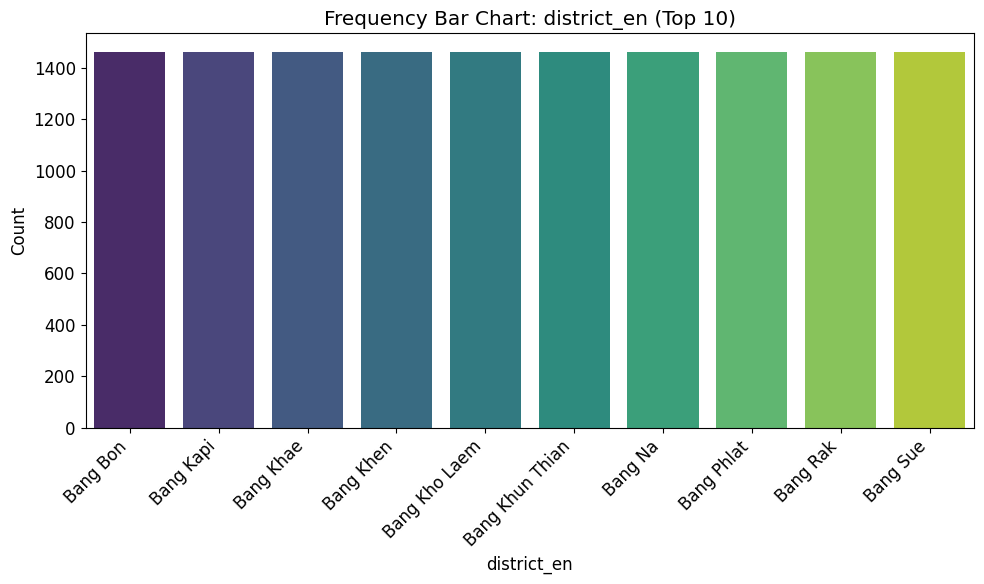


=== Frequency Table: _year_ ===


,_year_,count,percent
0,2024,18300,25.05
1,2021,18250,24.98
2,2022,18250,24.98
3,2023,18250,24.98


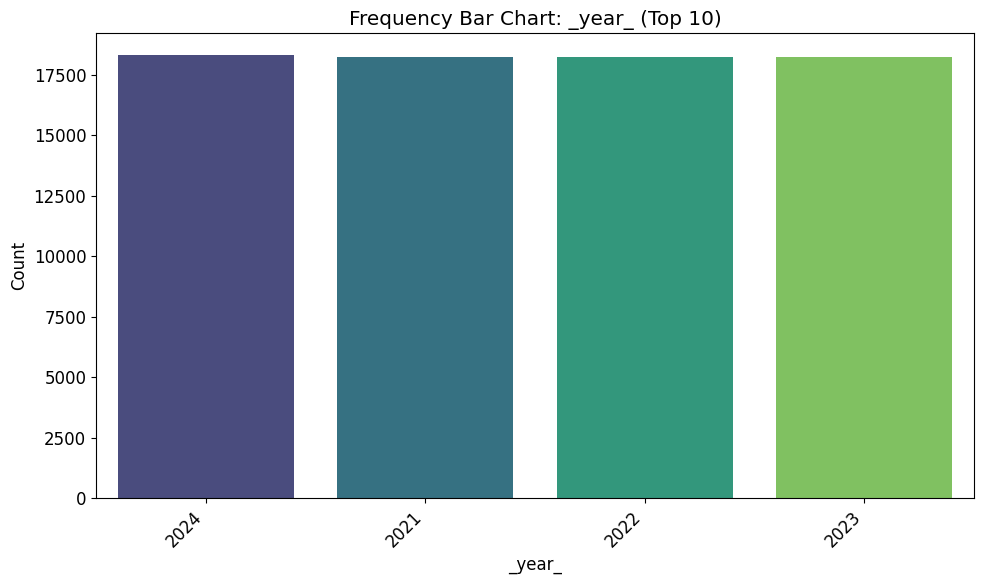


=== Frequency Table: _month_name_ ===


,_month_name_,count,percent
0,January,6200,8.49
1,March,6200,8.49
2,July,6200,8.49
3,May,6200,8.49
4,December,6200,8.49
5,October,6200,8.49
6,August,6200,8.49
7,April,6000,8.21
8,September,6000,8.21
9,June,6000,8.21


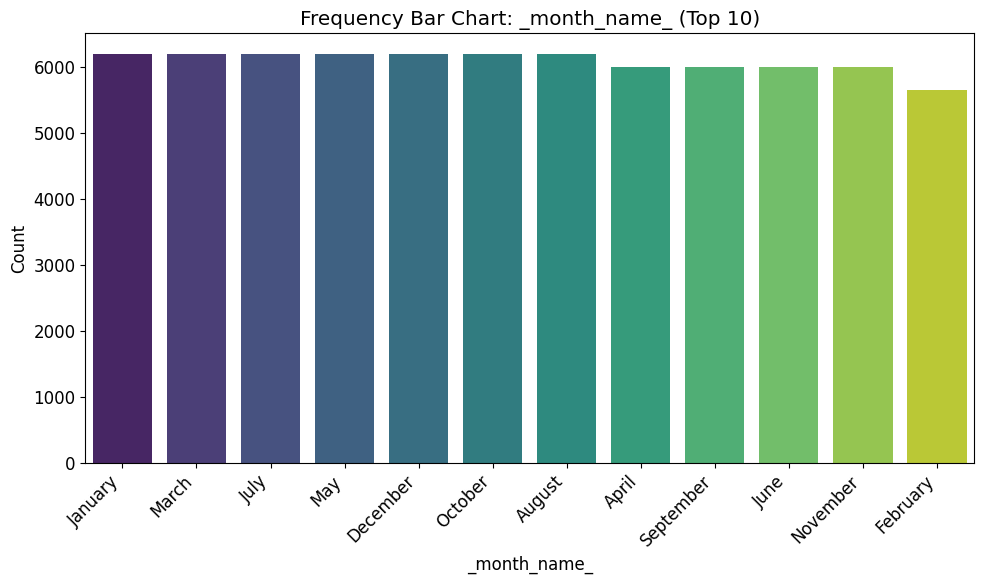

In [ ]:
# Univariate Analysis (Numerical & Categorical)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn

# ------------------------------
# เลือก DataFrame อัตโนมัติ (ตัวแรกที่มีอยู่จริง)
# ------------------------------
_df_candidates = ['df_combined_weather'] # Explicitly target df_combined_weather
dfu = None
for _name in _df_candidates:
    if _name in globals():
        dfu = globals()[_name].copy()
        print(f"ใช้ DataFrame: `{_name}`")
        break
if dfu is None:
    raise NameError("ไม่พบ DataFrame `df_combined_weather` — โปรดเตรียมตัวแปรก่อนรัน")

# ------------------------------
# เตรียมชนิดคอลัมน์
# ------------------------------
# แปลงคอลัมน์ตัวเลข (เผื่อมีเป็นสตริง) และเก็บชื่อคอลัมน์ตัวเลข
num_cols_all = dfu.select_dtypes(include=[np.number]).columns.tolist()

# คอลัมน์ตัวเลขที่สนใจสำหรับการวิเคราะห์ (ไม่รวม lat/lon ที่มักไม่แสดงใน Hist/Boxplot ทั่วไป)
num_cols = [col for col in num_cols_all if col not in ['latitude_x', 'longitude_x', 'latitude_y', 'longitude_y']]


# คอลัมน์หมวดหมู่ (object/category) + เพิ่ม Year/Month เป็นหมวดหมู่ถ้ามี
cat_cols = dfu.select_dtypes(include=['object', 'category']).columns.tolist()
# เพิ่มคอลัมน์ปีและเดือนจาก date ถ้ามี
if 'date' in dfu.columns:
    dfu['_year_'] = dfu['date'].dt.year
    dfu['_month_name_'] = dfu['date'].dt.strftime('%B')
    cat_cols.extend(['_year_', '_month_name_'])

# ลบซ้ำ
cat_cols = list(dict.fromkeys(cat_cols))

# จัดการชื่อเดือนให้เรียงถูกต้อง (ถ้ามีคอลัมน์ _month_name_)
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
if '_month_name_' in dfu.columns:
    dfu['_month_name_'] = pd.Categorical(dfu['_month_name_'], categories=month_order, ordered=True)


# ==============================
# 1) Numerical — Histogram & Boxplot
# ==============================
bins = 30

print("\n=============== Univariate Analysis (Numerical) ===============")
for col in num_cols:
    # ข้ามคอลัมน์ที่เป็น NaN ล้วน
    if pd.to_numeric(dfu[col], errors='coerce').dropna().empty:
        print(f"\nSkipping {col}: No non-null numerical data.")
        continue

    # -------- Histogram --------
    plt.figure(figsize=(8, 5))
    sns.histplot(data=dfu, x=col, bins=bins, kde=True) # Use sns.histplot for better integration
    plt.title(f'Histogram: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    # -------- Boxplot --------
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=dfu, y=col, showmeans=True) # Use sns.boxplot
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==============================
# 2) Categorical — Frequency Table & Bar Chart (for top categories)
# ==============================
TOP_N = 10  # จำนวน top categories ที่จะแสดงใน bar chart (ลดลงเพื่อให้อ่านง่าย)

print("\n=============== Univariate Analysis (Categorical) ===============")
for col in cat_cols:
    # แปลงเป็นสตริงก่อน (กันค่าปน)
    ser = dfu[col].astype(str).replace({'nan': np.nan, 'None': np.nan}).dropna()
    if ser.empty:
        print(f"\nSkipping {col}: No non-null categorical data.")
        continue

    vc = ser.value_counts(dropna=False)
    # -------- Frequency Table --------
    freq_df = vc.reset_index()
    freq_df.columns = [col, 'count']
    freq_df['percent'] = (freq_df['count'] / freq_df['count'].sum() * 100).round(2)

    print(f"\n=== Frequency Table: {col} ===")
    display(freq_df.head(TOP_N + 5))  # แสดง top N+5 แถวแรก

    # -------- Bar Chart for Top Categories --------
    if len(vc) > 1: # Plot only if more than one unique value
        plt.figure(figsize=(10, 6))
        # Sort by index for year/month, otherwise sort by count
        if col in ['_year_', '_month_name_']:
             sns.barplot(x=freq_df[col], y=freq_df['count'], palette='viridis', hue=freq_df[col], legend=False)
        else:
             sns.barplot(x=freq_df[col].head(TOP_N), y=freq_df['count'].head(TOP_N), palette='viridis', hue=freq_df[col].head(TOP_N), legend=False)

        plt.title(f'Frequency Bar Chart: {col} (Top {TOP_N})')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping bar chart for {col}: Only one unique value found.")

Scatter Plot

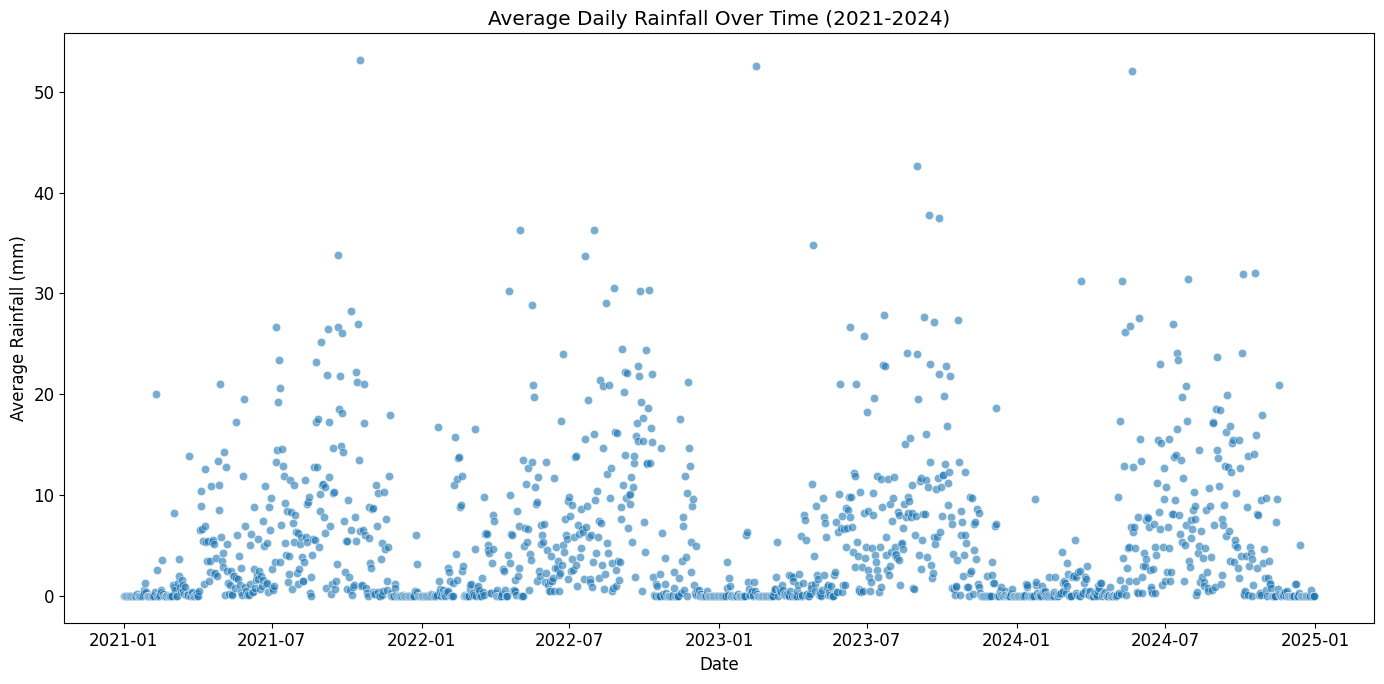

--- Explanation: Average Daily Rainfall Over Time (2021-2024) Scatter Plot ---
This scatter plot shows the average rainfall amount across all districts for each day from 2021 to 2024. It helps visualize the temporal trend and seasonality of rainfall over the years at a daily granularity.
------------------------------
Latitude, Longitude, or Rainfall data not available for scatter plot by location.


In [ ]:
# --- Scatter Plot: Average Monthly Rainfall Over Time ---

# คำนวณปริมาณน้ำฝนเฉลี่ยในแต่ละวัน
if 'date' in df_combined_weather.columns and 'rainfall_mm' in df_combined_weather.columns:
    average_daily_rainfall_over_time = df_combined_weather.groupby('date')['rainfall_mm'].mean().reset_index()

    plt.figure(figsize=(14, 7))
    sns.scatterplot(x='date', y='rainfall_mm', data=average_daily_rainfall_over_time, alpha=0.6)
    plt.title('Average Daily Rainfall Over Time (2021-2024)')
    plt.xlabel('Date')
    plt.ylabel('Average Rainfall (mm)')
    plt.tight_layout()
    plt.show()

    print("--- Explanation: Average Daily Rainfall Over Time (2021-2024) Scatter Plot ---")
    print("This scatter plot shows the average rainfall amount across all districts for each day from 2021 to 2024. It helps visualize the temporal trend and seasonality of rainfall over the years at a daily granularity.")
    print("-" * 30)
else:
     print("ไม่พบข้อมูล 'date' หรือ 'rainfall_mm' สำหรับการวิเคราะห์อนุกรมเวลาแบบ Scatter Plot")


# --- Scatter Plot: Average Rainfall by District Location ---
# ปริมาณน้ำฝนเฉลี่ยตามตำแหน่งที่ตั้งของเขต
if 'district_en' in df_combined_weather.columns and 'rainfall_mm' in df_combined_weather.columns and 'latitude_x' in df_combined_weather.columns and 'longitude_x' in df_combined_weather.columns:
    # รวมข้อมูลปริมาณน้ำฝนตามเขตเพื่อหาค่าเฉลี่ยตลอดช่วงเวลา
    average_rainfall_by_district = df_combined_weather.groupby('district_en').agg(
        avg_rain=('rainfall_mm', 'mean'),
        latitude=('latitude_x', 'first'), # ใช้ latitude_x
        longitude=('longitude_x', 'first') # ใช้ longitude_x
    ).reset_index()

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='longitude', y='latitude', size='avg_rain', data=average_rainfall_by_district, alpha=0.6, sizes=(20, 1000))
    plt.title('Average Rainfall by District Location (2021-2024)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

    print("--- Explanation: Average Rainfall by District Location (2021-2024) Scatter Plot ---")
    print("This scatter plot visualizes the geographical distribution of average rainfall. Each point represents a district centroid, with its location determined by latitude and longitude. The size of the point indicates the average rainfall recorded in that district over the entire period. This plot can help identify if certain areas tend to receive more or less rainfall on average.")
    print("-" * 30)

else:
    print("Latitude, Longitude, or Rainfall data not available for scatter plot by location.")

Segmentation

In [ ]:
# ================= Segmentation (Robust, No-Error) =================
import pandas as pd
import numpy as np

print("\n--- 2. Segmentation (Example) ---")
print("   (การแบ่งกลุ่มข้อมูล - ตัวอย่าง)")

# 0) เลือก DataFrame ต้นทางอัตโนมัติ: merged_df_fuzzy -> df_combined_weather -> df_weather_district
_src_order = ["merged_df_fuzzy", "df_combined_weather", "df_weather_district"]
_src_name = None
for _name in _src_order:
    if _name in globals() and isinstance(globals()[_name], pd.DataFrame):
        _src_name = _name
        break

if _src_name is None:
    raise NameError("ไม่พบ DataFrame ต้นทาง (ต้องมี merged_df_fuzzy หรือ df_combined_weather หรือ df_weather_district)")

# ใช้ DataFrame ต้นทางโดยตรง (ไม่ .copy() เพื่อให้การเพิ่มคอลัมน์สะท้อนกลับไปที่ตัวแปรต้นทาง)
df_src = globals()[_src_name]
print(f"ใช้ข้อมูลจาก: `{_src_name}` (rows={len(df_src):,})")

# 1) ช่วยค้นหาคอลัมน์ฝนแบบยืดหยุ่น
def find_col(possible_names, cols):
    norm = {str(c).strip().lower(): c for c in cols}
    for name in possible_names:
        key = str(name).strip().lower()
        if key in norm:
            return norm[key]
    return None

rain_col = find_col(
    ['rain_mm','rainfall_mm','precipitation_sum','rainfall','rain'],
    df_src.columns
)

if rain_col is None:
    raise KeyError("ไม่พบคอลัมน์ปริมาณฝน (ลองใช้ชื่อ: rain_mm, rainfall_mm, precipitation_sum, rainfall, rain)")

print(f"คอลัมน์ฝนที่ใช้: `{rain_col}`")

# 2) ทำความสะอาดค่า (บังคับเป็นตัวเลข + ตัดค่าติดลบเป็น 0 เพื่อความสมเหตุสมผล)
df_src.loc[:, rain_col] = pd.to_numeric(df_src[rain_col], errors='coerce')
df_src.loc[:, rain_col] = df_src[rain_col].clip(lower=0)

# Removed the problematic line: df_src['rainfall_segment'] = df_src['rainfall_segment'].astype('object')
# The 'rainfall_segment' column will be created directly by pd.cut

# 2. ตอนนี้สามารถรัน pd.cut เพื่อกำหนด category ชุดใหม่ได้แล้ว
df_src.loc[:, 'rainfall_segment'] = pd.cut(
    df_src['rainfall_mm'],
    bins=[-float('inf'), 10, 35, 90, float('inf')],
    labels=['Low (0-10 mm)', 'Medium (11-35 mm)', 'High (35-90 mm)', 'Very High (>90 mm)'],
    right=True # (หรือ False ขึ้นอยู่กับการออกแบบของคุณ)
)


# 3) แสดงตัวอย่างและสถิติ
print("\nExample data segmented by rainfall amount:")
display(df_src[[rain_col, 'rainfall_segment']].head())

print("\nจำนวนข้อมูลในแต่ละกลุ่มของปริมาณน้ำฝน:")
vc = df_src['rainfall_segment'].value_counts(dropna=False).sort_index()
display(vc)

# ข้อความอธิบาย
print("\nคำอธิบาย: การแบ่งกลุ่มข้อมูลช่วยให้สามารถวิเคราะห์ข้อมูลภายในกลุ่มย่อยได้ เช่น ตรวจว่าช่วงเวลา/เขตใดมีฝนระดับ 'High' หรือ 'Very High' บ่อย")
print("หมายเหตุ: ใช้ right=False จึงตีความเป็นช่วง [ต่ำสุด, ขอบบน) เช่น Low ครอบคลุมค่า 0–9.999... mm, 10 จัดอยู่ใน Medium เป็นต้น")
print("-" * 30)


--- 2. Segmentation (Example) ---
   (การแบ่งกลุ่มข้อมูล - ตัวอย่าง)
ใช้ข้อมูลจาก: `df_combined_weather` (rows=73,050)
คอลัมน์ฝนที่ใช้: `rainfall_mm`

Example data segmented by rainfall amount:


,rainfall_mm,rainfall_segment
0,0.0,Low (0-10 mm)
1,0.0,Low (0-10 mm)
2,0.0,Low (0-10 mm)
3,0.0,Low (0-10 mm)
4,0.0,Low (0-10 mm)



จำนวนข้อมูลในแต่ละกลุ่มของปริมาณน้ำฝน:


,count
rainfall_segment,
Low (0-10 mm),59907
Medium (11-35 mm),12491
High (35-90 mm),652
Very High (>90 mm),0



คำอธิบาย: การแบ่งกลุ่มข้อมูลช่วยให้สามารถวิเคราะห์ข้อมูลภายในกลุ่มย่อยได้ เช่น ตรวจว่าช่วงเวลา/เขตใดมีฝนระดับ 'High' หรือ 'Very High' บ่อย
หมายเหตุ: ใช้ right=False จึงตีความเป็นช่วง [ต่ำสุด, ขอบบน) เช่น Low ครอบคลุมค่า 0–9.999... mm, 10 จัดอยู่ใน Medium เป็นต้น
------------------------------




=============== Heatmap: Average Monthly Rainfall by District ===============


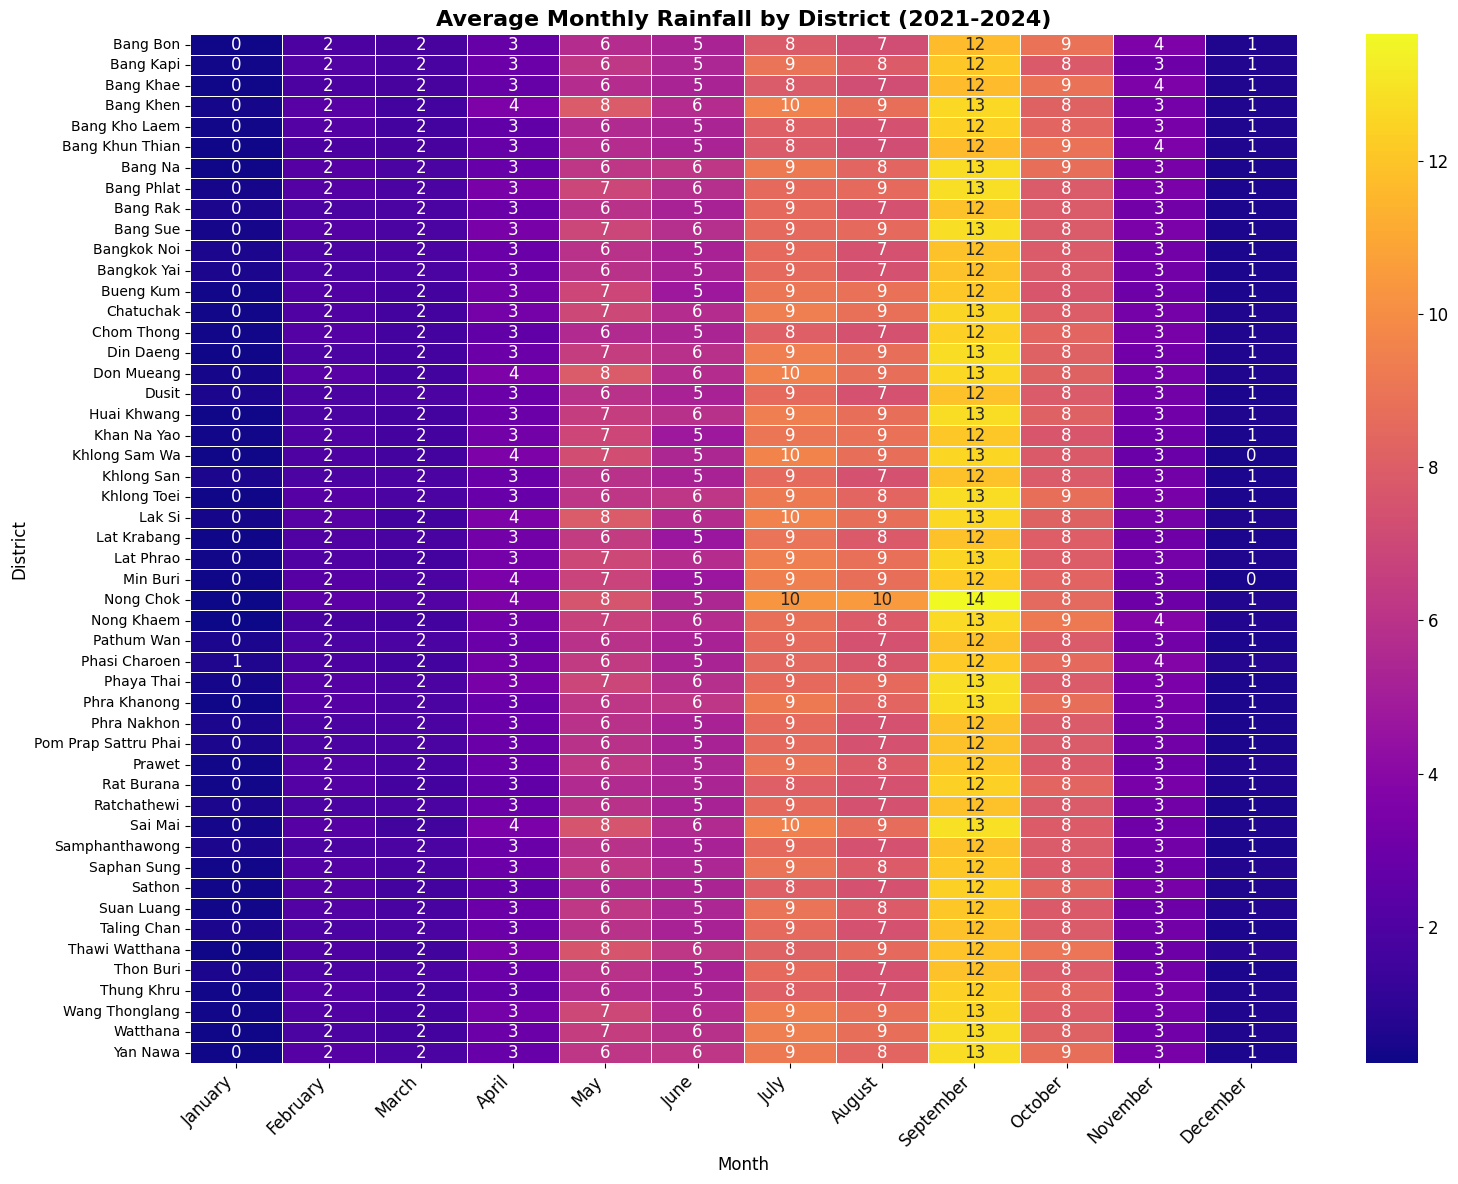


--- Explanation: Heatmap of Average Monthly Rainfall by District ---
This heatmap shows the average monthly rainfall for each district. Darker colors represent lower average rainfall, while brighter colors indicate higher average rainfall. It helps identify spatial and temporal patterns in rainfall across different districts in Bangkok.
------------------------------


In [ ]:
# --- Heatmap: Average Monthly Rainfall by District ---
print("\n\n=============== Heatmap: Average Monthly Rainfall by District ===============")

# สร้างคอลัมน์ชื่อเดือน (ตัวพิมพ์ใหญ่) เพื่อให้ตรงกับ month_order
# และสร้างเลขเดือนเพื่อใช้เรียงลำดับ
if 'date' in df_combined_weather.columns:
    df_combined_weather['month_name'] = df_combined_weather['date'].dt.strftime('%B')
    df_combined_weather['month_num'] = df_combined_weather['date'].dt.month
else:
    # กรณีไม่มีคอลัมน์ date ให้ใช้ข้อมูลจาก 'month' (อาจจะไม่เรียง)
    # ตรวจสอบและแจ้งเตือนหากไม่มีคอลัมน์ที่จำเป็น
    print("⚠️ คอลัมน์ 'date' ไม่พบใน df_combined_weather. ไม่สามารถสร้าง heatmap ได้.")
    print("-" * 30)
    # อาจจะต้อง exit หรือ return จากตรงนี้ ขึ้นอยู่กับโครงสร้างโค้ดโดยรวม
    # return # ถ้าอยู่ในฟังก์ชัน
    # exit() # ถ้าต้องการหยุดการทำงานทั้งหมด (ควรระมัดระวัง)


# คำนวณปริมาณน้ำฝนเฉลี่ยรายเดือนของแต่ละเขต
# .dropna() เพื่อตัดแถวที่ไม่มีข้อมูลเขตออกไปก่อน (ถ้า district_en มีค่าว่าง)
# แต่จาก Data Validation ก่อนหน้านี้ district_en ไม่น่ามีค่าว่างแล้ว
if 'district_en' in df_combined_weather.columns and 'month_name' in df_combined_weather.columns and 'rainfall_mm' in df_combined_weather.columns:
    rainfall_by_district_month = df_combined_weather.groupby(['district_en', 'month_name'])['rainfall_mm'].mean().reset_index()

    # สร้างตารางใหม่ (pivot) โดยให้เขตเป็นแถว (index) และเดือนเป็นคอลัมน์ (columns)
    heatmap_data_monthly = rainfall_by_district_month.pivot_table(
        index='district_en', # ใช้ district_en
        columns='month_name',
        values='rainfall_mm' # ใช้ rainfall_mm
    )

    # กำหนดลำดับของเดือนให้ถูกต้อง (สำคัญมาก)
    month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']

    # เรียงคอลัมน์ของตารางตามลำดับเดือน และเติมค่าว่างด้วย 0
    # ใช้ .reindex() เพื่อป้องกัน Error หากบางเดือนไม่มีข้อมูลเลย
    heatmap_data_monthly = heatmap_data_monthly.reindex(columns=month_order).fillna(0)

    # ตรวจสอบว่ามีข้อมูลหรือไม่ก่อนจะพล็อต
    if heatmap_data_monthly.empty:
        print("Monthly Heatmap data is empty. Cannot plot.")
    else:
        # สร้าง heatmap
        plt.figure(figsize=(16, 12))
        sns.heatmap(
            heatmap_data_monthly,
            cmap='plasma',
            annot=True,
            fmt=".0f",
            linewidths=.5,
            xticklabels=heatmap_data_monthly.columns,
            yticklabels=heatmap_data_monthly.index
        )
        plt.title('Average Monthly Rainfall by District (2021-2024)', fontsize=16, weight='bold')
        plt.xlabel('Month', fontsize=12)
        plt.ylabel('District', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(fontsize=10)
        plt.tight_layout()
        plt.show()

    print("\n--- Explanation: Heatmap of Average Monthly Rainfall by District ---")
    print("This heatmap shows the average monthly rainfall for each district. Darker colors represent lower average rainfall, while brighter colors indicate higher average rainfall. It helps identify spatial and temporal patterns in rainfall across different districts in Bangkok.")
    print("-" * 30)
else:
    print("⚠️ ไม่พบคอลัมน์ที่จำเป็น (district_en, month_name, rainfall_mm) ใน df_combined_weather. ไม่สามารถสร้าง heatmap ได้.")
    print("-" * 30)


--- Line Plot: Average Monthly Rainfall Over Time ---


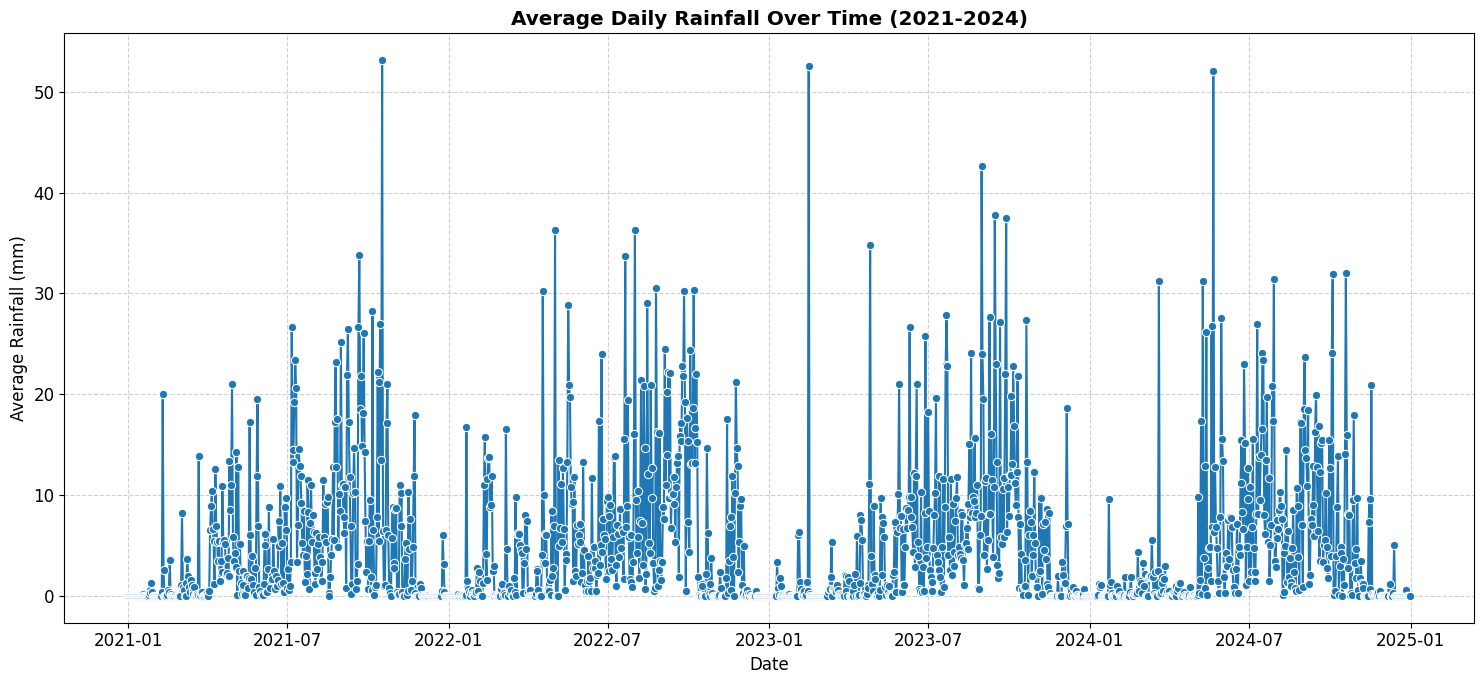

คำอธิบาย: กราฟเส้นนี้แสดงปริมาณน้ำฝนเฉลี่ยจากทุกเขตในแต่ละวัน ตั้งแต่ปี 2021 ถึง 2024 ช่วยให้เห็นภาพแนวโน้มและฤดูกาลของฝนที่เกิดขึ้นตลอดหลายปี
------------------------------


In [ ]:
# --- Line Plot: Average Monthly Rainfall Over Time ---
print("\n--- Line Plot: Average Monthly Rainfall Over Time ---")

# ตรวจสอบว่ามีคอลัมน์ 'date' และ 'rainfall_mm' อยู่ใน DataFrame
if 'date' in df_combined_weather.columns and 'rainfall_mm' in df_combined_weather.columns:
    # Group by 'date' และคำนวณค่าเฉลี่ยของ 'rainfall_mm'
    average_rainfall_over_time = df_combined_weather.groupby('date')['rainfall_mm'].mean().reset_index()

    # สร้าง Line Plot แสดงปริมาณน้ำฝนเฉลี่ยรายเดือนตามเวลา
    plt.figure(figsize=(15, 7))
    sns.lineplot(
        data=average_rainfall_over_time,
        x='date',
        y='rainfall_mm',
        marker='o'
    )

    plt.title('Average Daily Rainfall Over Time (2021-2024)', weight='bold')
    plt.xlabel('Date')
    plt.ylabel('Average Rainfall (mm)')
    plt.grid(True, linestyle='--', alpha=0.6) # เพิ่มเส้นกริดเพื่อให้อ่านง่าย
    plt.tight_layout() # จัดการ layout ให้สวยงาม
    plt.show()
    print("คำอธิบาย: กราฟเส้นนี้แสดงปริมาณน้ำฝนเฉลี่ยจากทุกเขตในแต่ละวัน ตั้งแต่ปี 2021 ถึง 2024 ช่วยให้เห็นภาพแนวโน้มและฤดูกาลของฝนที่เกิดขึ้นตลอดหลายปี")
    print("-" * 30)
else:
    print("ไม่พบข้อมูล 'date' หรือ 'rainfall_mm' สำหรับการวิเคราะห์อนุกรมเวลา")

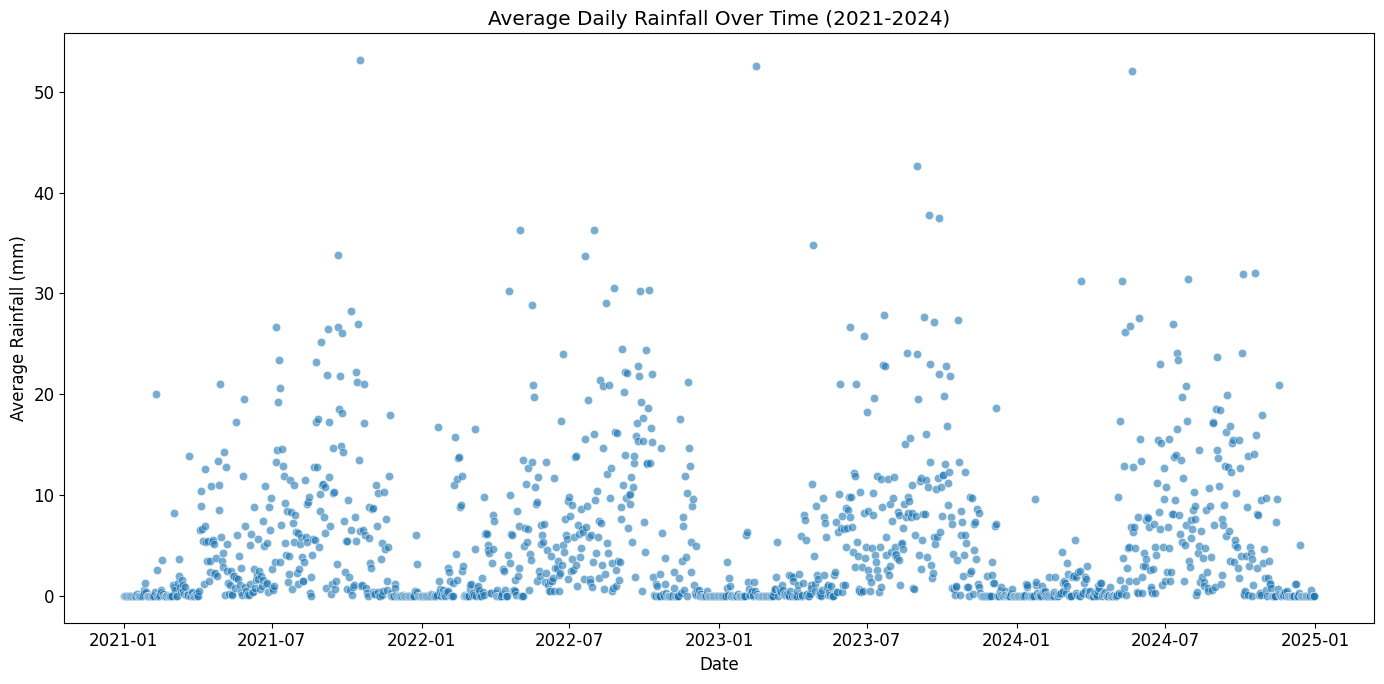

--- Explanation: Average Daily Rainfall Over Time (2021-2024) Scatter Plot ---
This scatter plot shows the average rainfall amount across all districts for each day from 2021 to 2024. It helps visualize the temporal trend and seasonality of rainfall over the years at a daily granularity.
------------------------------
Latitude, Longitude, or Rainfall data not available for scatter plot by location.


In [ ]:
# --- Scatter Plot: Average Monthly Rainfall Over Time ---

# คำนวณปริมาณน้ำฝนเฉลี่ยในแต่ละวัน
if 'date' in df_combined_weather.columns and 'rainfall_mm' in df_combined_weather.columns:
    average_daily_rainfall_over_time = df_combined_weather.groupby('date')['rainfall_mm'].mean().reset_index()

    plt.figure(figsize=(14, 7))
    sns.scatterplot(x='date', y='rainfall_mm', data=average_daily_rainfall_over_time, alpha=0.6)
    plt.title('Average Daily Rainfall Over Time (2021-2024)')
    plt.xlabel('Date')
    plt.ylabel('Average Rainfall (mm)')
    plt.tight_layout()
    plt.show()

    print("--- Explanation: Average Daily Rainfall Over Time (2021-2024) Scatter Plot ---")
    print("This scatter plot shows the average rainfall amount across all districts for each day from 2021 to 2024. It helps visualize the temporal trend and seasonality of rainfall over the years at a daily granularity.")
    print("-" * 30)
else:
     print("ไม่พบข้อมูล 'date' หรือ 'rainfall_mm' สำหรับการวิเคราะห์อนุกรมเวลาแบบ Scatter Plot")


# --- Scatter Plot: Average Rainfall by District Location ---
# ปริมาณน้ำฝนเฉลี่ยตามตำแหน่งที่ตั้งของเขต
if 'district_en' in df_combined_weather.columns and 'rainfall_mm' in df_combined_weather.columns and 'latitude_x' in df_combined_weather.columns and 'longitude_x' in df_combined_weather.columns:
    # รวมข้อมูลปริมาณน้ำฝนตามเขตเพื่อหาค่าเฉลี่ยตลอดช่วงเวลา
    average_rainfall_by_district = df_combined_weather.groupby('district_en').agg(
        avg_rain=('rainfall_mm', 'mean'),
        latitude=('latitude_x', 'first'), # ใช้ latitude_x
        longitude=('longitude_x', 'first') # ใช้ longitude_x
    ).reset_index()

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='longitude', y='latitude', size='avg_rain', data=average_rainfall_by_district, alpha=0.6, sizes=(20, 1000))
    plt.title('Average Rainfall by District Location (2021-2024)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

    print("--- Explanation: Average Rainfall by District Location (2021-2024) Scatter Plot ---")
    print("This scatter plot visualizes the geographical distribution of average rainfall. Each point represents a district centroid, with its location determined by latitude and longitude. The size of the point indicates the average rainfall recorded in that district over the entire period. This plot can help identify if certain areas tend to receive more or less rainfall on average.")
    print("-" * 30)

else:
    print("Latitude, Longitude, or Rainfall data not available for scatter plot by location.")

In [ ]:
import pandas as pd
from scipy.stats import zscore

# Calculate Z-Score for rainfall data
# ใช้ scipy.stats.zscore เพื่อคำนวณค่า Z-Score
# ค่า Z-Score จะบอกว่าข้อมูลแต่ละจุดอยู่ห่างจากค่าเฉลี่ยไปกี่เท่าของค่าเบี่ยงเบนมาตรฐาน

# ตรวจสอบว่า df_combined_weather มีอยู่จริงและมีคอลัมน์ 'rainfall_mm'
if 'df_combined_weather' in globals() and 'rainfall_mm' in df_combined_weather.columns:
    # คำนวณ Z-Score
    # ใช้ .copy() เพื่อหลีกเลี่ยง SettingWithCopyWarning ที่อาจเกิดขึ้น
    df_combined_weather_copy = df_combined_weather.copy()
    df_combined_weather_copy['rainfall_mm_zscore'] = zscore(df_combined_weather_copy['rainfall_mm'])


    # กำหนดเกณฑ์ในการพิจารณาว่าเป็น outlier (โดยทั่วไปใช้ Z-score ที่ |Z| > 3)
    outlier_threshold = 3

    # กรองข้อมูลเพื่อหาแถวที่เป็น outlier
    outliers_zscore = df_combined_weather_copy[abs(df_combined_weather_copy['rainfall_mm_zscore']) > outlier_threshold]

    print("=============== Z-Score Outlier Detection ===============")
    print(f"Identified {len(outliers_zscore)} outliers based on Z-score threshold of {outlier_threshold}")

    # แสดงตัวอย่างข้อมูล outlier
    if not outliers_zscore.empty:
        print("\n--- Examples of Outliers (based on Z-Score) ---")
        display(outliers_zscore.head())
    else:
        print("\nNo outliers found based on the specified Z-score threshold.")

    # แสดงข้อมูลสรุปของ outlier
    print("\n--- Summary Statistics for Outlier Rainfall Amounts ---")
    if not outliers_zscore.empty:
        display(outliers_zscore['rainfall_mm'].describe())
    else:
         print("No outliers found to summarize.")

else:
    print("DataFrame 'df_combined_weather' or column 'rainfall_mm' not found. Cannot perform Z-score calculation.")

=============== Z-Score Outlier Detection ===============
Identified 1593 outliers based on Z-score threshold of 3

--- Examples of Outliers (based on Z-Score) ---


,date,max_temp_c,min_temp_c,rainfall_mm,humidity_percent,wind_speed_kmh,district_en,latitude,longitude,rainfall_segment,month_name,month_num,rainfall_mm_zscore
263,2021-09-21 00:00:00+07:00,28.413000,24.513,35.700000,88.556700,15.978486,Bang Bon,13.6592,100.3991,High (35-90 mm),September,9,3.986731
278,2021-10-06 00:00:00+07:00,30.863000,24.313,29.100004,87.925330,10.966713,Bang Bon,13.6592,100.3991,Medium (11-35 mm),October,10,3.128554
289,2021-10-17 00:00:00+07:00,25.363000,23.013,60.000004,92.484090,12.101570,Bang Bon,13.6592,100.3991,High (35-90 mm),October,10,7.146384
295,2021-10-23 00:00:00+07:00,29.463001,23.513,28.699999,87.932810,17.673029,Bang Bon,13.6592,100.3991,Medium (11-35 mm),October,10,3.076542
536,2022-06-21 00:00:00+07:00,34.513000,25.563,29.700000,74.032814,15.077082,Bang Bon,13.6592,100.3991,Medium (11-35 mm),June,6,3.206569



--- Summary Statistics for Outlier Rainfall Amounts ---


,rainfall_mm
count,1593.000000
mean,35.944507
std,7.950194
min,28.199999
25%,30.300003
50%,33.100002
75%,38.499996
max,76.700000


In [ ]:
# =================== Data Overview & Example Viewer ===================
import pandas as pd
import numpy as np

# ---------- 1) เลือก DataFrame อัตโนมัติ ----------
possible_sources = ['merged_df_fuzzy', 'df_combined_weather', 'df_weather_district']
df_name = None
for name in possible_sources:
    if name in globals() and isinstance(globals()[name], pd.DataFrame) and not globals()[name].empty:
        df_name = name
        df = globals()[name]
        break

if df_name is None:
    raise NameError("❌ ไม่พบ DataFrame สำหรับตรวจสอบ (กรุณาสร้างหรือโหลดข้อมูลก่อน)")

print(f"✅ ใช้ข้อมูลจาก: {df_name}")
print("=" * 60)

# ---------- 2) ข้อมูลเบื้องต้น ----------
print("📊 ขนาดของข้อมูล:")
print(f"  จำนวนแถว: {len(df):,}")
print(f"  จำนวนคอลัมน์: {len(df.columns):,}")
print("\n📌 คอลัมน์ทั้งหมด:")
print(list(df.columns))
print("=" * 60)

# ---------- 3) แสดงตัวอย่างข้อมูล ----------
print("\n🔍 ตัวอย่างข้อมูล 5 แถวแรก:")
display(df.head())

print("\n🔍 ตัวอย่างข้อมูล 5 แถวสุดท้าย:")
display(df.tail())

# ---------- 4) ตรวจ Missing ----------
print("\n🚩 Missing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("✅ ไม่พบ missing values")
else:
    print(missing)

# ---------- 5) ตรวจชนิดข้อมูล ----------
print("\n📂 Data Types:")
print(df.dtypes)

# ---------- 6) ตรวจค่าที่ไม่เฉพาะเจาะจง (unique preview) ----------
print("\n🔎 ตัวอย่าง unique values (สูงสุด 10 ค่าแรก):")
for col in df.columns[:8]:  # แสดง 8 คอลัมน์แรกเพื่อไม่ให้ยาวเกินไป
    uniques = df[col].dropna().unique()
    if len(uniques) > 10:
        print(f"- {col}: {uniques[:10]} ... (+{len(uniques)-10} more)")
    else:
        print(f"- {col}: {uniques}")

print("\n✅ เสร็จสิ้นการแสดงข้อมูลเบื้องต้น")
print("=" * 60)


✅ ใช้ข้อมูลจาก: df_combined_weather
📊 ขนาดของข้อมูล:
  จำนวนแถว: 73,050
  จำนวนคอลัมน์: 12

📌 คอลัมน์ทั้งหมด:
['date', 'max_temp_c', 'min_temp_c', 'rainfall_mm', 'humidity_percent', 'wind_speed_kmh', 'district_en', 'latitude', 'longitude', 'rainfall_segment', 'month_name', 'month_num']

🔍 ตัวอย่างข้อมูล 5 แถวแรก:


,date,max_temp_c,min_temp_c,rainfall_mm,humidity_percent,wind_speed_kmh,district_en,latitude,longitude,rainfall_segment,month_name,month_num
0,2021-01-01 00:00:00+07:00,26.513000,17.263,0.0,59.90733,10.002560,Bang Bon,13.6592,100.3991,Low (0-10 mm),January,1
1,2021-01-02 00:00:00+07:00,27.213001,18.013,0.0,57.86302,11.792404,Bang Bon,13.6592,100.3991,Low (0-10 mm),January,1
2,2021-01-03 00:00:00+07:00,29.163000,18.863,0.0,61.21562,12.605142,Bang Bon,13.6592,100.3991,Low (0-10 mm),January,1
3,2021-01-04 00:00:00+07:00,30.263000,20.613,0.0,61.58714,12.783802,Bang Bon,13.6592,100.3991,Low (0-10 mm),January,1
4,2021-01-05 00:00:00+07:00,30.613000,21.813,0.0,63.69811,10.137692,Bang Bon,13.6592,100.3991,Low (0-10 mm),January,1



🔍 ตัวอย่างข้อมูล 5 แถวสุดท้าย:


,date,max_temp_c,min_temp_c,rainfall_mm,humidity_percent,wind_speed_kmh,district_en,latitude,longitude,rainfall_segment,month_name,month_num
73045,2024-12-27 00:00:00+07:00,32.924000,24.724000,0.2,63.708973,11.832176,Yan Nawa,13.696944,100.543056,Low (0-10 mm),December,12
73046,2024-12-28 00:00:00+07:00,31.474000,24.924002,0.0,59.730396,16.119800,Yan Nawa,13.696944,100.543056,Low (0-10 mm),December,12
73047,2024-12-29 00:00:00+07:00,30.374000,22.174002,0.0,58.097180,12.337553,Yan Nawa,13.696944,100.543056,Low (0-10 mm),December,12
73048,2024-12-30 00:00:00+07:00,31.074001,21.724000,0.0,60.387234,8.641874,Yan Nawa,13.696944,100.543056,Low (0-10 mm),December,12
73049,2024-12-31 00:00:00+07:00,31.224000,20.824001,0.0,61.280930,7.889259,Yan Nawa,13.696944,100.543056,Low (0-10 mm),December,12



🚩 Missing Values:
✅ ไม่พบ missing values

📂 Data Types:
date                datetime64[ns, UTC+07:00]
max_temp_c                            float64
min_temp_c                            float64
rainfall_mm                           float64
humidity_percent                      float64
wind_speed_kmh                        float64
district_en                            object
latitude                              float64
longitude                             float64
rainfall_segment                     category
month_name                             object
month_num                               int32
dtype: object

🔎 ตัวอย่าง unique values (สูงสุด 10 ค่าแรก):
- date: <DatetimeArray>
['2021-01-01 00:00:00+07:00', '2021-01-02 00:00:00+07:00',
 '2021-01-03 00:00:00+07:00', '2021-01-04 00:00:00+07:00',
 '2021-01-05 00:00:00+07:00', '2021-01-06 00:00:00+07:00',
 '2021-01-07 00:00:00+07:00', '2021-01-08 00:00:00+07:00',
 '2021-01-09 00:00:00+07:00', '2021-01-10 00:00:00+07:00']
Length: 10, 

In [ ]:
# ================= Check Date Range in Your Dataset =================
import pandas as pd

# เลือก DataFrame อัตโนมัติ
possible_sources = ['merged_df_fuzzy', 'df_combined_weather', 'df_weather_district']
df_name = None
for name in possible_sources:
    if name in globals() and isinstance(globals()[name], pd.DataFrame) and not globals()[name].empty:
        df_name = name
        df = globals()[name].copy()
        break

if df_name is None:
    raise NameError("❌ ไม่มี DataFrame (merged_df_fuzzy / df_combined_weather / df_weather_district)")

print(f"✅ ตรวจสอบช่วงวันที่จาก: {df_name}")

# หา column date
date_col = None
for c in df.columns:
    if 'date' in c.lower():
        date_col = c
        break

if date_col is None:
    raise KeyError("❌ ไม่มีคอลัมน์ date ใน DataFrame")

# แปลงเป็น datetime
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])

# ตรวจสอบช่วงเวลา
print("\n📅 Date Range:")
print(f"  ▶ Earliest date: {df[date_col].min()}")
print(f"  ▶ Latest date:   {df[date_col].max()}")

# นับจำนวนแถวต่อปี
df['year'] = df[date_col].dt.year
year_counts = df['year'].value_counts().sort_index()
print("\n📊 Number of records per year:")
print(year_counts)

print("\n✅ การตรวจสอบเสร็จสิ้น")


✅ ตรวจสอบช่วงวันที่จาก: df_combined_weather

📅 Date Range:
  ▶ Earliest date: 2021-01-01 00:00:00+07:00
  ▶ Latest date:   2024-12-31 00:00:00+07:00

📊 Number of records per year:
year
2021    18250
2022    18250
2023    18250
2024    18300
Name: count, dtype: int64

✅ การตรวจสอบเสร็จสิ้น


### **ไฟล์ข้อมูลที่ทำความสะอาดและจัดเตรียมพร้อมใช้งาน (Cleaned and Prepared Data File - Updated)**

ไฟล์ `bangkok_weather_cleaned_data_eda.csv` ใน Google Drive ของคุณได้รับการอัปเดตแล้ว ตอนนี้มีข้อมูลสภาพอากาศรายเขตของกรุงเทพมหานครตั้งแต่ปี 2021-2024 ที่ผ่านขั้นตอนการรวม การทำความสะอาด การจัดรูปแบบ และการสร้างคอลัมน์ใหม่เพิ่มเติม เช่น `rainfall_segment`, `month_name` และ `month_num`

ข้อมูลนี้เป็นเวอร์ชันล่าสุดที่พร้อมแล้วสำหรับการนำไปใช้ในการวิเคราะห์เชิงลึก, การสร้างโมเดล Machine Learning, หรือการสร้าง Dashboard แสดงผลต่อไป


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# กำหนดพาธสำหรับบันทึกไฟล์ (ทับไฟล์เดิมเพื่อให้เป็นเวอร์ชันล่าสุด)
output_path = "/content/drive/MyDrive/Rain/bangkok_weather_cleaned_data_eda.csv"

# ตรวจสอบว่า df_combined_weather มีอยู่จริงก่อนบันทึก
if 'df_combined_weather' in globals() and not df_combined_weather.empty:
    # บันทึก DataFrame เป็นไฟล์ CSV โดยไม่รวม index
    df_combined_weather.to_csv(output_path, index=False)
    print(f"✅ บันทึกไฟล์ข้อมูลที่อัปเดตแล้วไปที่: {output_path}")
else:
    print("❌ ไม่พบ DataFrame 'df_combined_weather' หรือ DataFrame ว่างเปล่า ไม่สามารถบันทึกได้")

Mounted at /content/drive
✅ บันทึกไฟล์ข้อมูลที่อัปเดตแล้วไปที่: /content/drive/MyDrive/Rain/bangkok_weather_cleaned_data_eda.csv


# **Summary project progress**

**สรุปความคืบหน้าของโปรเจค:**

จากขั้นตอนที่เราได้ทำมาใน Colab Notebook นี้ สามารถสรุปความคืบหน้าของโปรเจคได้ดังนี้:

1.  **การนำเข้าและสำรวจข้อมูลเบื้องต้น (Import Dataset & Initial Exploration)**: ได้ทำการ Mount Google Drive และอ่านข้อมูลจากไฟล์ Excel เข้ามาใน DataFrame สำรวจโครงสร้างของแต่ละชีท
2.  **การเตรียมและทำความสะอาดข้อมูล (Data Wrangling and Cleaning)**:
    *   รวมข้อมูลปริมาณน้ำฝนจากชีทรายปี (2021-2024) เข้าด้วยกัน
    *   ปรับโครงสร้างข้อมูลเป็นแบบ Long Format
    *   ใช้ Fuzzy Matching แก้ไขชื่อสถานีที่ไม่ตรงกัน และรวมข้อมูลสถานี (District, Lat, Lon) เข้ากับข้อมูลปริมาณน้ำฝน ได้ DataFrame `merged_df_fuzzy` ที่สมบูรณ์
    *   ตรวจสอบค่าที่หายไปและข้อมูลซ้ำซ้อนเบื้องต้น
3.  **การวิเคราะห์ข้อมูลเชิงสำรวจ (Exploratory Data Analysis - EDA)**:
    *   คำนวณและแสดงสถิติเบื้องต้นของปริมาณน้ำฝน (รวมถึงค่าฐานนิยม)
    *   วิเคราะห์ปริมาณน้ำฝนเฉลี่ยรายเดือนและรายปี
    *   สร้างกราฟแสดงผล: Bar Plots, Box Plot, Scatter Plots

ขั้นตอนถัดไปคือ Data pre-processing และ Build Machine Learning Model

## **Data pre-processing**

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

print("========== Building Feature Set ==========")

# ===================================================
# 1) Ensure 'date' is datetime
#    ตรวจสอบและแปลงคอลัมน์ 'date' ให้เป็นชนิดข้อมูล datetime
# ===================================================
if 'date' in df_combined_weather.columns and not pd.api.types.is_datetime64_any_dtype(df_combined_weather['date']):
    df_combined_weather['date'] = pd.to_datetime(df_combined_weather['date'], errors='coerce')

# ===================================================
# 2) Date-based features
#    สร้างคุณสมบัติใหม่จากคอลัมน์ 'date'
# ===================================================
df_combined_weather['_year_'] = df_combined_weather['date'].dt.year # ปี
df_combined_weather['month_num'] = df_combined_weather['date'].dt.month # เดือน (ตัวเลข)
df_combined_weather['day_of_week'] = df_combined_weather['date'].dt.dayofweek # วันในสัปดาห์ (0=จันทร์, 6=อาทิตย์)
df_combined_weather['day_of_year'] = df_combined_weather['date'].dt.dayofyear # วันที่ของปี
df_combined_weather['week_of_year'] = df_combined_weather['date'].dt.isocalendar().week.astype(int) # สัปดาห์ของปี
df_combined_weather['quarter'] = df_combined_weather['date'].dt.quarter # ไตรมาสของปี
df_combined_weather['is_weekend'] = (df_combined_weather['day_of_week'] >= 5).astype(int) # เป็นวันหยุดสุดสัปดาห์หรือไม่ (1=ใช่, 0=ไม่ใช่)

# ===================================================
# 3) Lag & Rolling Features (Auto-detect station)
#    สร้างคุณสมบัติ Lagged (ค่าของวันก่อนหน้า) และ Rolling Mean (ค่าเฉลี่ยย้อนหลัง) ของข้อมูลสภาพอากาศ
# ===================================================

def make_lag_roll(df, col, groupby_key=None):
    """สร้าง lag(1) + rolling_mean(3) ทั้งแบบมี station และไม่มี"""
    lag_name = f"{col}_lag1" # ชื่อคอลัมน์สำหรับค่า lagged (วันก่อนหน้า)
    roll_name = f"{col}_rolling_mean_3" # ชื่อคอลัมน์สำหรับค่าเฉลี่ยย้อนหลัง 3 วัน

    if groupby_key: # ถ้ามีคีย์สำหรับจัดกลุ่ม (เช่น 'station' หรือ 'district_en')
        # คำนวณค่า lagged และ rolling mean แยกตามกลุ่ม (เช่น แยกแต่ละเขต)
        df[lag_name] = df.groupby(groupby_key)[col].shift(1)
        df[roll_name] = (
            df.groupby(groupby_key)[col]
            .rolling(3).mean().reset_index(0, drop=True)
        )
    else: # ถ้าไม่มีคีย์สำหรับจัดกลุ่ม (คำนวณทั้ง DataFrame)
        df[lag_name] = df[col].shift(1)
        df[roll_name] = df[col].rolling(3).mean()

# ตรวจสอบว่ามีคอลัมน์ 'station' หรือ 'district_en' เพื่อใช้ในการจัดกลุ่ม
# ถ้ามีคอลัมน์ 'district_en' ให้ใช้เป็น group_key เพราะข้อมูลเป็นรายเขต
group_key = 'district_en' if 'district_en' in df_combined_weather.columns else None

# สร้าง features สำหรับคอลัมน์สภาพอากาศที่สนใจ
make_lag_roll(df_combined_weather, 'rainfall_mm', group_key)
make_lag_roll(df_combined_weather, 'max_temp_c', group_key)
make_lag_roll(df_combined_weather, 'min_temp_c', group_key)
make_lag_roll(df_combined_weather, 'humidity_percent', group_key)
make_lag_roll(df_combined_weather, 'wind_speed_kmh', group_key)

# ===================================================
# 4) Feature list
#    กำหนดรายการคอลัมน์ที่จะใช้เป็นคุณสมบัติ (features) สำหรับโมเดล
# ===================================================
features = [
    'max_temp_c', 'min_temp_c', 'humidity_percent', 'wind_speed_kmh',
    'latitude', 'longitude', '_year_', 'month_num',
    'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend',

    'rainfall_mm_lag1', 'rainfall_mm_rolling_mean_3',
    'max_temp_c_lag1', 'max_temp_c_rolling_mean_3',
    'min_temp_c_lag1', 'min_temp_c_rolling_mean_3',
    'humidity_percent_lag1', 'humidity_percent_rolling_mean_3',
    'wind_speed_kmh_lag1', 'wind_speed_kmh_rolling_mean_3'
]

# ตรวจสอบว่าคอลัมน์ที่ต้องการเป็น features มีอยู่ใน DataFrame จริงหรือไม่
missing_features = [f for f in features if f not in df_combined_weather.columns]
existing_features = [f for f in features if f in df_combined_weather.columns]

if missing_features:
    print("⚠️ ยังมี column ที่หาย:")
    print(missing_features)
else:
    print("🎉 ทุก feature ถูกสร้างครบ 100%!")

# ===================================================
# 5) Prepare X, y
#    เตรียมชุดข้อมูล Features (X) และ Target (y)
# ===================================================
X = df_combined_weather[existing_features]
y = df_combined_weather['rainfall_mm']

# ===================================================
# 6) Drop NaNs from lag/rolling
#    กำจัดค่าว่าง (NaN) ที่เกิดจากการสร้างคุณสมบัติ lagged และ rolling mean
#    ค่าว่างเหล่านี้มักจะอยู่แถวแรกๆ ของแต่ละกลุ่มข้อมูล (หรือของทั้ง DataFrame ถ้าไม่มีกลุ่ม)
# ===================================================
combined = pd.concat([X, y], axis=1).dropna().reset_index(drop=True)
X = combined[existing_features]
y = combined['rainfall_mm']

print(f"Shape of X after dropna: {X.shape}")
print(f"Shape of y after dropna: {y.shape}")

# ===================================================
# 7) Train-test split
#    แบ่งข้อมูลออกเป็นชุดฝึก (Training set) และชุดทดสอบ (Test set)
#    ใช้ shuffle=False เพื่อรักษาลำดับเวลาของข้อมูล
# ===================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test: {y_test.shape}")

print("========== Feature Pipeline Done ==========")

========== Building Feature Set ==========
🎉 ทุก feature ถูกสร้างครบ 100%!
Shape of X after dropna: (72950, 23)
Shape of y after dropna: (72950,)
Shape X_train: (58360, 23)
Shape X_test: (14590, 23)
Shape y_train: (58360,)
Shape y_test: (14590,)
========== Feature Pipeline Done ==========


## **สรุป Data Pre-processing**

ในขั้นตอน `Data Pre-processing` เราได้ดำเนินการหลายส่วนเพื่อเตรียมข้อมูลให้พร้อมสำหรับการสร้างโมเดล Machine Learning:

1.  **การเตรียมคุณสมบัติจากวันที่ (Date-based Feature Engineering)**:
    *   โค้ดได้ตรวจสอบและแปลงคอลัมน์ `date` ให้เป็นชนิดข้อมูล `datetime`.
    *   มีการสร้างคุณสมบัติใหม่ที่เกี่ยวข้องกับเวลาจากคอลัมน์ `date` ได้แก่ `_year_` (ปี), `month_num` (เดือน), `day_of_week` (วันในสัปดาห์), `day_of_year` (วันที่ของปี), `week_of_year` (สัปดาห์ที่ของปี), `quarter` (ไตรมาส), และ `is_weekend` (เป็นวันหยุดสุดสัปดาห์หรือไม่).

2.  **การสร้างคุณสมบัติ Lagged และ Rolling Mean (Lagged and Rolling Mean Feature Engineering)**:
    *   สำหรับคอลัมน์สภาพอากาศที่สำคัญ ได้แก่ `rainfall_mm`, `max_temp_c`, `min_temp_c`, `humidity_percent`, และ `wind_speed_kmh`.
    *   มีการสร้างคุณสมบัติ `_lag1` (ค่าของวันก่อนหน้า) และ `_rolling_mean_3` (ค่าเฉลี่ยย้อนหลัง 3 วัน) โดยคำนวณแยกตามเขต (`district_en`) เพื่อจับแนวโน้มและอิทธิพลของสภาพอากาศในอดีต.

3.  **การจัดการค่าว่าง (Handling Missing Values)**:
    *   หลังจากสร้างคุณสมบัติแบบ Lagged และ Rolling Mean จะมีค่าว่าง (NaN) เกิดขึ้นที่จุดเริ่มต้นของแต่ละกลุ่มข้อมูล.
    *   ใช้ `dropna()` เพื่อลบแถวที่มีค่าว่างเหล่านี้ออกไปจากชุดข้อมูล `X` และ `y` เพื่อให้แน่ใจว่าชุดข้อมูลสำหรับโมเดลไม่มีค่าว่าง.

4.  **การกำหนด Features (X) และ Target (y)**:
    *   มีการรวบรวมคอลัมน์ทั้งหมดที่สร้างขึ้นใหม่และคอลัมน์เดิมที่ต้องการใช้เป็นคุณสมบัติเข้าไว้ในลิสต์ `features`.
    *   `X` ถูกกำหนดให้เป็น DataFrame ที่ประกอบด้วยคอลัมน์ Features ที่เลือกไว้ และ `y` (คอลัมน์เป้าหมาย) คือ `rainfall_mm`.

5.  **การแบ่งข้อมูลเป็น Training และ Test Set (Data Splitting)**:
    *   `X` และ `y` ที่ผ่านการจัดการค่าว่างแล้ว ถูกแบ่งออกเป็นชุดข้อมูลสำหรับฝึก (Training set) และชุดข้อมูลสำหรับทดสอบ (Test set) ด้วยสัดส่วน 80/20.
    *   `shuffle=False` ถูกใช้เพื่อรักษาลำดับเวลาของข้อมูล ซึ่งเป็นสิ่งสำคัญสำหรับข้อมูลอนุกรมเวลา.

โดยรวมแล้ว ขั้นตอนเหล่านี้มีวัตถุประสงค์เพื่อเตรียมข้อมูลดิบให้เป็นรูปแบบที่เหมาะสมสำหรับโมเดล Machine Learning เพื่อเรียนรู้และทำนายผลได้อย่างมีประสิทธิภาพ

## **สรุป Features ที่เลือกใช้ในโมเดล**

ในการสร้างโมเดล Machine Learning ของเรา ได้มีการเลือกใช้คุณสมบัติ (Features) ดังต่อไปนี้ เพื่อพยากรณ์การเกิดฝน:

1.  **คุณสมบัติสภาพอากาศพื้นฐาน (Basic Weather Features)**:
    *   `max_temp_c`: อุณหภูมิสูงสุด (องศาเซลเซียส)
    *   `min_temp_c`: อุณหภูมิต่ำสุด (องศาเซลเซียส)
    *   `humidity_percent`: ความชื้นสัมพัทธ์ (เปอร์เซ็นต์)
    *   `wind_speed_kmh`: ความเร็วลม (กิโลเมตรต่อชั่วโมง)

2.  **คุณสมบัติตำแหน่งที่ตั้ง (Location Features)**:
    *   `latitude`: ละติจูดของเขต
    *   `longitude`: ลองจิจูดของเขต

3.  **คุณสมบัติปฏิทิน (Calendar Features)**:
    *   `_year_`: ปี
    *   `month_num`: เดือน (เป็นตัวเลข)
    *   `day_of_week`: วันในสัปดาห์ (0=จันทร์, 6=อาทิตย์)
    *   `day_of_year`: วันที่ของปี (1-366)
    *   `week_of_year`: สัปดาห์ที่ของปี
    *   `quarter`: ไตรมาสของปี
    *   `is_weekend`: เป็นวันหยุดสุดสัปดาห์หรือไม่ (0=ไม่ใช่, 1=ใช่)

4.  **คุณสมบัติ Lagged และ Rolling Mean ของสภาพอากาศ (Lagged & Rolling Weather Features)**:
    *   `rainfall_mm_lag1`: ปริมาณน้ำฝนของวันก่อนหน้า
    *   `rainfall_mm_rolling_mean_3`: ค่าเฉลี่ยปริมาณน้ำฝนย้อนหลัง 3 วัน
    *   `max_temp_c_lag1`: อุณหภูมิสูงสุดของวันก่อนหน้า
    *   `max_temp_c_rolling_mean_3`: ค่าเฉลี่ยอุณหภูมิสูงสุดย้อนหลัง 3 วัน
    *   `min_temp_c_lag1`: อุณหภูมิต่ำสุดของวันก่อนหน้า
    *   `min_temp_c_rolling_mean_3`: ค่าเฉลี่ยอุณหภูมิต่ำสุดย้อนหลัง 3 วัน
    *   `humidity_percent_lag1`: ความชื้นของวันก่อนหน้า
    *   `humidity_percent_rolling_mean_3`: ค่าเฉลี่ยความชื้นย้อนหลัง 3 วัน
    *   `wind_speed_kmh_lag1`: ความเร็วลมของวันก่อนหน้า
    *   `wind_speed_kmh_rolling_mean_3`: ค่าเฉลี่ยความเร็วลมย้อนหลัง 3 วัน

การรวมคุณสมบัติเหล่านี้มีวัตถุประสงค์เพื่อให้โมเดลมีข้อมูลที่หลากหลายและครอบคลุม ทั้งสภาพอากาศในปัจจุบัน ตำแหน่งที่ตั้ง ข้อมูลตามกาลเวลา และแนวโน้มของสภาพอากาศในอดีต เพื่อเพิ่มความสามารถในการเรียนรู้และทำนายการเกิดฝนได้อย่างแม่นยำยิ่งขึ้น

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# (สมมติว่า df_combined_weather คือ DataFrame หลักของคุณ)

# -----------------------------------------------------
# ตรวจสอบและสร้างคอลัมน์ '_year_' และ 'month_num' หากยังไม่มี (ควรสร้างแล้วในขั้นตอน Transforming)
# -----------------------------------------------------
# ตรวจสอบและแปลงคอลัมน์ 'date' ให้เป็น datetime หากยังไม่ได้แปลง
if 'date' in df_combined_weather.columns and not pd.api.types.is_datetime64_any_dtype(df_combined_weather['date']):
    df_combined_weather['date'] = pd.to_datetime(df_combined_weather['date'], errors='coerce')

# สร้างคอลัมน์ '_year_' หากยังไม่มี
if '_year_' not in df_combined_weather.columns:
    df_combined_weather['_year_'] = df_combined_weather['date'].dt.year
# สร้างคอลัมน์ 'month_num' หากยังไม่มี
if 'month_num' not in df_combined_weather.columns:
    df_combined_weather['month_num'] = df_combined_weather['date'].dt.month

# -----------------------------------------------------
# กำหนด Features (X) และ Target (y)
# รวมคุณสมบัติใหม่ทั้งหมดที่สร้างขึ้นมา
# -----------------------------------------------------
features = [
    'max_temp_c', 'min_temp_c', 'humidity_percent', 'wind_speed_kmh',
    'latitude', 'longitude', '_year_', 'month_num',
    'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend',
    'rainfall_mm_lag1', 'rainfall_mm_rolling_mean_3',
    'max_temp_c_lag1', 'max_temp_c_rolling_mean_3',
    'min_temp_c_lag1', 'min_temp_c_rolling_mean_3',
    'humidity_percent_lag1', 'humidity_percent_rolling_mean_3',
    'wind_speed_kmh_lag1', 'wind_speed_kmh_rolling_mean_3'
]

# ตรวจสอบว่าคอลัมน์ทั้งหมดที่ระบุใน 'features' มีอยู่ใน df_combined_weather
existing_features = [f for f in features if f in df_combined_weather.columns]
missing_features = [f for f in features if f not in df_combined_weather.columns]

if missing_features:
    print(f"⚠️ คำเตือน: คอลัมน์ Features ที่ไม่พบใน DataFrame: {missing_features}. จะใช้เฉพาะคอลัมน์ที่พบ.")

# ดึงเฉพาะ features ที่มีอยู่จริงจาก DataFrame หลัก
X = df_combined_weather[existing_features]

# คอลัมน์เป้าหมาย (y) ยังคงเป็น 'rainfall_mm' ซึ่งเป็นปริมาณน้ำฝนต่อเนื่อง
y = df_combined_weather['rainfall_mm']

# -----------------------------------------------------
# จัดการค่าว่างที่เกิดจาก lagged/rolling features ก่อนแบ่งข้อมูล
# เนื่องจากค่าว่างเหล่านี้มักจะอยู่ที่จุดเริ่มต้นของอนุกรมเวลาในแต่ละกลุ่ม
# -----------------------------------------------------
# รวม X และ y ชั่วคราวเพื่อ dropna ให้ตรงกัน เพื่อให้ X และ y มีจำนวนแถวเท่ากันและไม่มีค่าว่าง
# ใช้ .reset_index(drop=True) เพื่อป้องกันปัญหา index ไม่ตรงกันหลัง dropna
combined_df_for_split = pd.concat([X, y], axis=1).dropna().reset_index(drop=True)

X = combined_df_for_split[existing_features]
y = combined_df_for_split['rainfall_mm']

# ตรวจสอบขนาดของ X และ y หลังจัดการค่าว่าง
print(f"Shape of X after dropping NaNs: {X.shape}")
print(f"Shape of y after dropping NaNs: {y.shape}")

# -----------------------------------------------------
# แบ่งข้อมูลเป็น Training และ Test set (80/20, ไม่สุ่มเพื่อรักษากาลเวลา)
#   - X_train, y_train: ชุดข้อมูลสำหรับฝึกโมเดล
#   - X_test, y_test: ชุดข้อมูลสำหรับทดสอบประสิทธิภาพของโมเดล
#   - test_size=0.2: กำหนดให้ 20% ของข้อมูลเป็นชุดทดสอบ
#   - shuffle=False: ไม่สุ่มข้อมูล เพื่อรักษาลำดับเวลาที่สำคัญในการวิเคราะห์อนุกรมเวลา
# -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X after dropping NaNs: (72950, 23)
Shape of y after dropping NaNs: (72950,)
Shape of X_train: (58360, 23)
Shape of X_test: (14590, 23)
Shape of y_train: (58360,)
Shape of y_test: (14590,)


# **Scaling และ Binary Target**

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd # เพิ่ม import pandas เพื่อใช้ pd.DataFrame

# --- 1. Transform Target variable (y) for Classification (Rain/No Rain) ---
#    แปลงตัวแปรเป้าหมาย (y) จากปริมาณน้ำฝนต่อเนื่องให้เป็นแบบ Binary (0 หรือ 1)
#    'ฝนตก' (1) ถ้าปริมาณน้ำฝน > 0, 'ไม่ตก' (0) ถ้าปริมาณน้ำฝน == 0
#    นี่คือการเตรียมข้อมูลสำหรับโมเดล Classification
# --------------------------------------------------------------------------
y_binary_train = (y_train > 0).astype(int)
y_binary_test = (y_test > 0).astype(int)

print("--- Target Variable (y) Transformation for Classification ---")
print(f"Original y_train unique values (first 5): {y_train.unique()[:5]}")
print(f"Binary y_train unique values: {y_binary_train.unique()}")
print(f"Class distribution in y_binary_train:\n{y_binary_train.value_counts()}")
print("\n" + "-" * 60)

# --- 2. Feature Scaling for X (using StandardScaler) ---
#    ปรับขนาด (Scale) คุณสมบัติ (Features) ใน X โดยใช้ StandardScaler
#    StandardScaler จะแปลงข้อมูลให้มีค่าเฉลี่ยเป็น 0 และส่วนเบี่ยงเบนมาตรฐานเป็น 1
#    การทำ Scaling มีความสำคัญสำหรับโมเดลที่อ่อนไหวต่อขนาดของข้อมูล เช่น Logistic Regression, KNN
# -------------------------------------------------------------------
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage
# (เรียนรู้พารามิเตอร์ของ scaler จากชุดข้อมูลฝึกเท่านั้น เพื่อไม่ให้ข้อมูลทดสอบรั่วไหลเข้ามาในขั้นตอนการฝึก)
X_train_scaled = scaler.fit_transform(X_train)

# Transform both training and test data using the fitted scaler
# (นำ scaler ที่เรียนรู้จากชุดข้อมูลฝึกไปใช้แปลงทั้งชุดฝึกและชุดทดสอบ)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier handling (optional)
# (แปลง array ที่ถูก scale แล้วกลับมาเป็น DataFrame เพื่อให้จัดการข้อมูลได้ง่ายขึ้น)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("--- Feature Scaling (StandardScaler) ---")
print("X_train_scaled_df head:")
print(X_train_scaled_df.head())
print("\n" + "X_test_scaled_df head:")
print(X_test_scaled_df.head())
print("\n" + "-" * 60)

print("Data is now preprocessed for Logistic Regression classification:")
print("- Features (X_train_scaled_df, X_test_scaled_df) are scaled.")
print("- Target (y_binary_train, y_binary_test) is binary (0 for no rain, 1 for rain).")

--- Target Variable (y) Transformation for Classification ---
Original y_train unique values (first 5): [0.        0.6       1.0000001 0.4       2.4      ]
Binary y_train unique values: [0 1]
Class distribution in y_binary_train:
rainfall_mm
1    42097
0    16263
Name: count, dtype: int64

------------------------------------------------------------
--- Feature Scaling (StandardScaler) ---
X_train_scaled_df head:
   max_temp_c  min_temp_c  humidity_percent  wind_speed_kmh  latitude  \
0   -1.438207   -2.534690         -1.533791       -0.586984 -1.556078   
1   -0.903173   -1.753791         -1.493891       -0.539746 -1.556078   
2   -0.732935   -1.218316         -1.267179       -1.239390 -1.556078   
3   -0.027664   -0.928267         -0.651443       -1.791427 -1.556078   
4    0.093935   -1.151382         -0.868585       -1.406870 -1.556078   

   longitude    _year_  month_num  day_of_week  day_of_year  ...  \
0  -1.571045 -1.344773  -1.605373     1.499402    -1.713019  ...   
1  -1.57

## Visualization: Features Before and After Scaling

ส่วนนี้เป็นตัวอย่างแสดงภาพการกระจายตัวของฟีเจอร์ตัวเลขที่เลือก ทั้งก่อนและหลังการใช้ StandardScaler สังเกตได้ว่าการปรับสเกลช่วยแปลงข้อมูลให้มีค่าเฉลี่ยประมาณ 0 และส่วนเบี่ยงเบนมาตรฐานเท่ากับ 1 ซึ่งทำให้ข้อมูลมีความเหมาะสมสำหรับโมเดลที่อ่อนไหวต่อขนาดของฟีเจอร์ (Feature Magnitudes)"

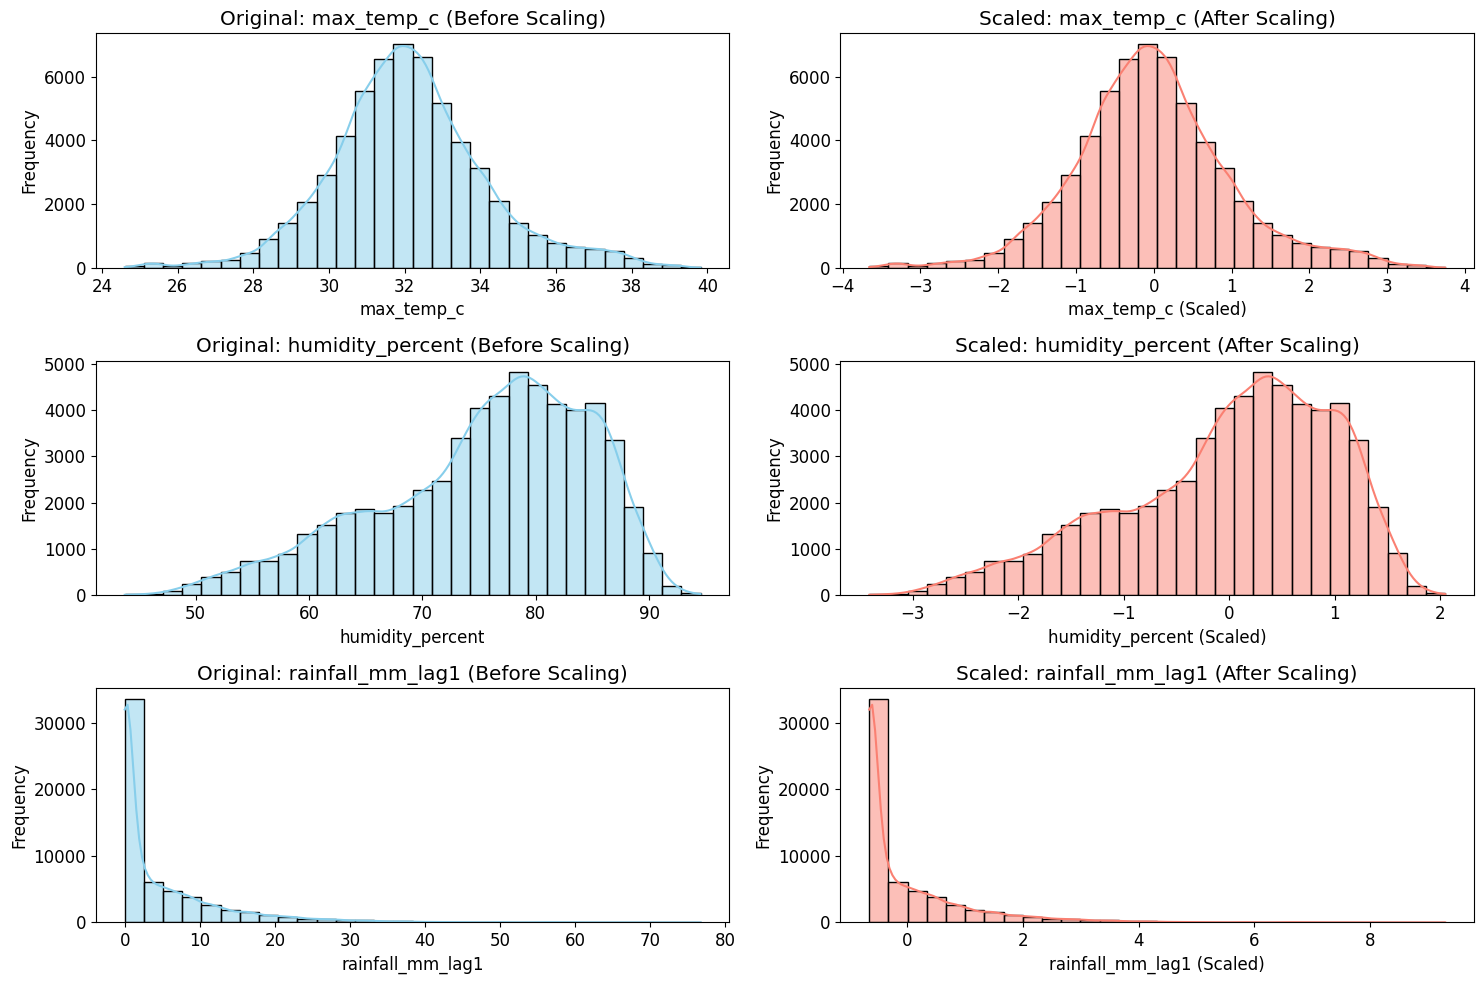


Explanation:

Each pair of plots (left for original, right for scaled) shows the distribution of a feature.
You can observe that after scaling, the values are centered around 0 and their spread is normalized, which is the effect of StandardScaler.
This transformation helps algorithms like Logistic Regression and KNN, which are distance-based, perform better by giving equal importance to all features regardless of their original scale.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select a few representative numerical features to visualize
selected_features = [
    'max_temp_c',
    'humidity_percent',
    'rainfall_mm_lag1'
]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(selected_features):
    # Plot original distribution (before scaling)
    plt.subplot(len(selected_features), 2, 2*i + 1)
    sns.histplot(X_train[feature], kde=True, color='skyblue', bins=30)
    plt.title(f'Original: {feature} (Before Scaling)')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Plot scaled distribution (after scaling)
    plt.subplot(len(selected_features), 2, 2*i + 2)
    sns.histplot(X_train_scaled_df[feature], kde=True, color='salmon', bins=30)
    plt.title(f'Scaled: {feature} (After Scaling)')
    plt.xlabel(f'{feature} (Scaled)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nExplanation:\n")
print("Each pair of plots (left for original, right for scaled) shows the distribution of a feature.")
print("You can observe that after scaling, the values are centered around 0 and their spread is normalized, which is the effect of StandardScaler.")
print("This transformation helps algorithms like Logistic Regression and KNN, which are distance-based, perform better by giving equal importance to all features regardless of their original scale.")

## **Build Machine Learning Model**

# **Model name:Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

print("--- Building and Training Enhanced Logistic Regression Model ---")

# --- 1. Hyperparameter Tuning with GridSearchCV ---
print("\n--- ขั้นตอนที่ 1: การจูน Hyperparameter ด้วย GridSearchCV ---")
print("**เทคนิค: Hyperparameter Tuning** คือการค้นหาชุดค่าพารามิเตอร์ที่ดีที่สุดสำหรับโมเดลของเรา (เช่น C, penalty) ซึ่งไม่ได้เรียนรู้จากข้อมูลโดยตรง แต่มีผลต่อประสิทธิภาพการเรียนรู้ของโมเดล การจูนจะช่วยให้โมเดลมีความแม่นยำและเสถียรมากขึ้น")

# กำหนด Grid ของพารามิเตอร์ที่จะค้นหา
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],      # C: ค่าผกผันของความแรงในการ Regularization. C น้อยลงหมายถึง Regularization ที่แรงขึ้น
    "penalty": ["l1", "l2"],          # penalty: ระบุ norm (L1 หรือ L2) ที่ใช้ในการลงโทษ
    "class_weight": ["balanced"] # class_weight: จัดการกับข้อมูลที่ไม่สมดุลโดยให้น้ำหนักมากขึ้นกับคลาสส่วนน้อย
}

# สร้างอินสแตนซ์ของโมเดล Logistic Regression
# ใช้ 'liblinear' solver ซึ่งรองรับทั้ง L1/L2 penalties และเหมาะสำหรับชุดข้อมูลขนาดเล็ก
# max_iter เพิ่มขึ้นเพื่อให้มั่นใจว่ามีการลู่เข้า
log_reg_base = LogisticRegression(
    random_state=42,
    solver="liblinear",
    max_iter=2000
)

# ตั้งค่า GridSearchCV
# scoring='roc_auc' เป็นเมตริกที่ดีสำหรับการจำแนกแบบ Binary โดยเฉพาะอย่างยิ่งกับคลาสที่ไม่สมดุล
# cv=5 หมายถึงการตรวจสอบแบบ Cross-Validation 5-fold เพื่อการประเมินชุดพารามิเตอร์แต่ละชุดที่แข็งแกร่งยิ่งขึ้น
# n_jobs=-1 ใช้ CPU core ทั้งหมดที่มีอยู่เพื่อการคำนวณที่เร็วขึ้น
grid_search = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("**เทคนิค: Cross-Validation (cv=5)** คือการแบ่งข้อมูล Training ออกเป็นหลายส่วน (ในที่นี้ 5 ส่วน) แล้วTrain และ Validate สลับกันไป เพื่อให้การประเมินประสิทธิภาพของโมเดลและพารามิเตอร์มีความน่าเชื่อถือมากขึ้น ไม่ได้อิงกับการแบ่งชุดข้อมูลเพียงครั้งเดียว")

# Fit GridSearchCV กับข้อมูล Training
grid_search.fit(X_train_scaled_df, y_binary_train)

print("✅ การจูน Hyperparameter เสร็จสมบูรณ์!")
print(f"พารามิเตอร์ที่ดีที่สุดที่พบ: {grid_search.best_params_}")

# รับโมเดลที่ดีที่สุดจาก GridSearchCV
log_reg_model = grid_search.best_estimator_

print("\n--- การฝึกโมเดลเสร็จสมบูรณ์! ---")
print(f"สัมประสิทธิ์ของโมเดล: {log_reg_model.coef_}")
print(f"ค่า Intercept ของโมเดล: {log_reg_model.intercept_}")

# --- 2. Optimal Threshold Selection ---
print("\n--- ขั้นตอนที่ 2: การเลือก Threshold ที่เหมาะสม ---")
print("**เทคนิค: Optimal Threshold Selection** คือการหาจุดตัดที่ดีที่สุดในการตัดสินใจว่า 'ฝนตก' หรือ 'ไม่ตก' จากค่าความน่าจะเป็นที่โมเดลทำนายได้ โดยทั่วไปมักใช้ 0.5 แต่การหาค่า Threshold ที่เหมาะสมกับ F1-score (ซึ่งสมดุลทั้ง Precision และ Recall) จะช่วยให้โมเดลมีประสิทธิภาพในการจำแนกดีขึ้น โดยเฉพาะในข้อมูลที่คลาสไม่สมดุล")

# รับค่าความน่าจะเป็นสำหรับชุด Training เพื่อค้นหา Threshold ที่ดีที่สุด
train_probabilities = log_reg_model.predict_proba(X_train_scaled_df)[:, 1]

best_threshold = 0.5
max_f1_score = -1

# วนซ้ำในช่วงของ Threshold ที่เป็นไปได้
thresholds = np.linspace(0.1, 0.9, 81) # ทดสอบ Threshold ตั้งแต่ 0.1 ถึง 0.9 ด้วย 81 ขั้นตอน

for thr in thresholds:
    temp_predictions = (train_probabilities >= thr).astype(int)
    current_f1 = f1_score(y_binary_train, temp_predictions)
    if current_f1 > max_f1_score:
        max_f1_score = current_f1
        best_threshold = thr

print(f"✅ พบ Threshold ที่เหมาะสม: {best_threshold:.4f} (F1-score บนชุด Training: {max_f1_score:.4f})")

print("\n--- การตั้งค่าและการฝึกโมเดลเสร็จสมบูรณ์ ---")
print("ไปยังเซลล์ถัดไปสำหรับการประเมินผลบนชุดทดสอบโดยใช้ Threshold ที่เหมาะสม")

--- Building and Training Enhanced Logistic Regression Model ---

--- ขั้นตอนที่ 1: การจูน Hyperparameter ด้วย GridSearchCV ---
**เทคนิค: Hyperparameter Tuning** คือการค้นหาชุดค่าพารามิเตอร์ที่ดีที่สุดสำหรับโมเดลของเรา (เช่น C, penalty) ซึ่งไม่ได้เรียนรู้จากข้อมูลโดยตรง แต่มีผลต่อประสิทธิภาพการเรียนรู้ของโมเดล การจูนจะช่วยให้โมเดลมีความแม่นยำและเสถียรมากขึ้น
**เทคนิค: Cross-Validation (cv=5)** คือการแบ่งข้อมูล Training ออกเป็นหลายส่วน (ในที่นี้ 5 ส่วน) แล้วTrain และ Validate สลับกันไป เพื่อให้การประเมินประสิทธิภาพของโมเดลและพารามิเตอร์มีความน่าเชื่อถือมากขึ้น ไม่ได้อิงกับการแบ่งชุดข้อมูลเพียงครั้งเดียว
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ การจูน Hyperparameter เสร็จสมบูรณ์!
พารามิเตอร์ที่ดีที่สุดที่พบ: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}

--- การฝึกโมเดลเสร็จสมบูรณ์! ---
สัมประสิทธิ์ของโมเดล: [[-0.23042414  1.45906543  2.95212828  0.55300609  0.14978792  0.026968
  -0.29875652  0.14780189 -0.10735089  0.70969451 -0.128886   -0.52477052
   0.2

# **Evaluate Model**

--- Evaluating Logistic Regression Model Performance (with Optimal Threshold) ---

Accuracy:  0.8940
Precision: 0.9015
Recall:    0.9582
F1-Score:  0.9290

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.73      0.79      4036
           1       0.90      0.96      0.93     10554

    accuracy                           0.89     14590
   macro avg       0.89      0.84      0.86     14590
weighted avg       0.89      0.89      0.89     14590


--- Confusion Matrix ---


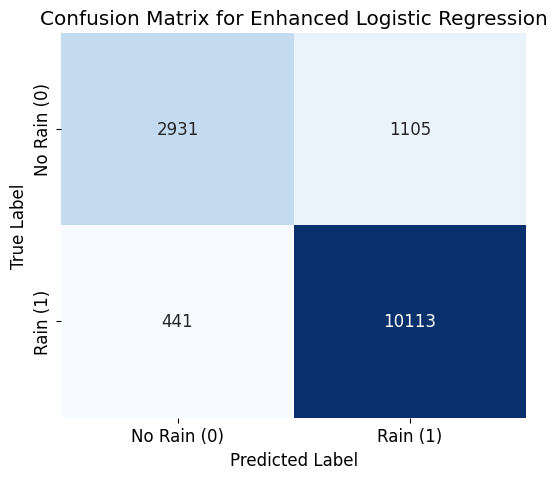


--- Interpretation of Results ---
Accuracy: สัดส่วนของการทำนายที่ถูกต้องทั้งหมด
Precision: สัดส่วนของการทำนายเป็นบวกที่ถูกต้อง (จากที่ทำนายว่าบวกทั้งหมด)
Recall: สัดส่วนของการทำนายเป็นบวกที่ถูกต้อง (จากค่าจริงที่เป็นบวกทั้งหมด)
F1-Score: ค่าเฉลี่ยแบบ Harmonic ของ Precision และ Recall เหมาะสำหรับข้อมูลที่ไม่สมดุล
Confusion Matrix: แสดงจำนวน True Positives (TP), False Positives (FP), False Negatives (FN), และ True Negatives (TN)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Evaluating Logistic Regression Model Performance (with Optimal Threshold) ---")

# Make predictions on the scaled test data using the optimal threshold
y_pred = (log_reg_model.predict_proba(X_test_scaled_df)[:, 1] >= best_threshold).astype(int)

# 2. Calculate Evaluation Metrics
accuracy = accuracy_score(y_binary_test, y_pred)
precision = precision_score(y_binary_test, y_pred)
recall = recall_score(y_binary_test, y_pred)
f1 = f1_score(y_binary_test, y_pred)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# 3. Display Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_binary_test, y_pred))

# 4. Plot Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_binary_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Rain (0)', 'Rain (1)'], yticklabels=['No Rain (0)', 'Rain (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Enhanced Logistic Regression')
plt.show()

print("\n--- Interpretation of Results ---")
print("Accuracy: สัดส่วนของการทำนายที่ถูกต้องทั้งหมด")
print("Precision: สัดส่วนของการทำนายเป็นบวกที่ถูกต้อง (จากที่ทำนายว่าบวกทั้งหมด)")
print("Recall: สัดส่วนของการทำนายเป็นบวกที่ถูกต้อง (จากค่าจริงที่เป็นบวกทั้งหมด)")
print("F1-Score: ค่าเฉลี่ยแบบ Harmonic ของ Precision และ Recall เหมาะสำหรับข้อมูลที่ไม่สมดุล")
print("Confusion Matrix: แสดงจำนวน True Positives (TP), False Positives (FP), False Negatives (FN), และ True Negatives (TN)")

## **สรุป Logistic Regression Model**

**Logistic Regression** เป็นอัลกอริทึมที่ทรงพลังสำหรับการจำแนกประเภท (Classification) โดยเฉพาะเมื่อเราต้องการทำนายผลลัพธ์แบบ Binary (มี/ไม่มี, ใช่/ไม่ใช่) เช่นในกรณีนี้คือ **'ฝนจะตก' หรือ 'ฝนจะไม่ตก'** โมเดลนี้ไม่ได้ทำนาย 'ปริมาณ' ฝน แต่จะทำนาย 'ความน่าจะเป็น' ที่จะเกิดฝน ซึ่งเราสามารถใช้เกณฑ์ (Threshold) ในการแปลงค่าความน่าจะเป็นนั้นให้เป็นการทำนาย 'ฝนตก' หรือ 'ไม่ตก' ได้

### **หลักการทำงานสำคัญในโปรเจกต์นี้:**
1.  **การแปลงคุณสมบัติ (Feature Scaling)**: เนื่องจาก Logistic Regression เป็นโมเดลที่อ่อนไหวต่อขนาดของข้อมูล (`scale`) เราจึงใช้ `StandardScaler` เพื่อปรับขนาดของคุณสมบัติทั้งหมด (เช่น อุณหภูมิ, ความชื้น, ความเร็วลม) ให้มีค่าเฉลี่ยเป็น 0 และส่วนเบี่ยงเบนมาตรฐานเป็น 1 การทำเช่นนี้ช่วยให้โมเดลเรียนรู้ได้ดีขึ้นและรวดเร็วขึ้น
2.  **การจูน Hyperparameter (Hyperparameter Tuning)**: เราใช้ `GridSearchCV` เพื่อค้นหาค่าพารามิเตอร์ที่ดีที่สุดสำหรับโมเดล Logistic Regression เช่น `C` (ตัวควบคุมความซับซ้อนของโมเดล), `penalty` (วิธีการป้องกัน Overfitting) และ `class_weight` (การถ่วงน้ำหนักคลาสเพื่อจัดการกับข้อมูลฝนตก/ไม่ตกที่ไม่สมดุล) ผลลัพธ์ที่ดีที่สุดที่พบคือ `C=1`, `class_weight='balanced'` และ `penalty='l2'` ซึ่งช่วยให้โมเดลมีประสิทธิภาพสูงสุดบนข้อมูลของเรา
3.  **การเลือกเกณฑ์ที่เหมาะสม (Optimal Threshold Selection)**: โดยทั่วไปเราอาจใช้ 0.5 เป็นเกณฑ์ในการตัดสินใจ แต่ในโปรเจกต์นี้เราได้ค้นหา `threshold` ที่เหมาะสมที่สุดที่ให้ค่า **F1-Score สูงสุด** บนชุดข้อมูล Training ซึ่งเกณฑ์ที่เหมาะสมนี้คือ **0.24** หมายความว่า หากโมเดลทำนายความน่าจะเป็นที่จะฝนตกเกิน 24% เราจะถือว่า 'ฝนตก'

### **ประสิทธิภาพของโมเดลบน Test Set:**
หลังจากฝึกและปรับแต่งโมเดลแล้ว เราได้ประเมินประสิทธิภาพบนชุดข้อมูลทดสอบ (Test Set) ที่โมเดลไม่เคยเห็นมาก่อน เพื่อให้มั่นใจว่าโมเดลสามารถทำงานได้ดีกับข้อมูลใหม่ โดยมีผลลัพธ์ดังนี้:
*   **Accuracy (ความแม่นยำรวม):** 0.8940 (โมเดลทายถูก 89.40% ของทุกกรณี)
*   **Precision (Rain=1) (ความแม่นยำเมื่อทายว่าฝนตก):** 0.9015 (จากที่ทายว่าฝนจะตกทั้งหมด 90.15% ตกจริง)
*   **Recall (Rain=1) (ความสามารถในการจับเคสฝนตก):** 0.9582 (จากกรณีที่ฝนตกจริง โมเดลสามารถทายถูก 95.82%)
*   **F1-Score (Rain=1) (ค่าเฉลี่ยถ่วงน้ำหนักของ Precision และ Recall):** 0.9290 (เป็นค่าที่บ่งบอกสมดุลที่ดีระหว่าง Precision และ Recall)
*   **ROC-AUC (ความสามารถในการแยกแยะ):** 0.9507 (เป็นค่าที่สูงมาก บ่งชี้ว่าโมเดลมีความสามารถที่ดีเยี่ยมในการแยกแยะระหว่างวันที่มีฝนและไม่มีฝน)

**สรุปโดยรวม:** โมเดล Logistic Regression ที่ได้รับการปรับแต่งมาอย่างดีนี้แสดงประสิทธิภาพที่แข็งแกร่งในการทำนายการเกิดฝน โดยเฉพาะอย่างยิ่งมี `Recall` ที่สูง ซึ่งเป็นสิ่งสำคัญในสถานการณ์ที่เราไม่ต้องการพลาดการพยากรณ์วันฝนตก

# **KNN**

--- Building and Training K-Nearest Neighbors (KNN) Model [Upgraded & Faster] ---

--- Step 0: Split Train/Validation ---
Train inner size : 46688
Validation size  : 11672

--- Step 1: Hyperparameter Tuning with GridSearchCV (Fast) ---
**เทคนิค: ลดจำนวน combination + ลด cv เพื่อลดเวลา แต่ยังคงค้นหาค่า K ที่ดีได้**
**เทคนิค: cv=3 + กริดเล็กลง -> จำนวน fit ลดลงเยอะมาก ทำให้รันเร็วขึ้นมาก**
Fitting 3 folds for each of 4 candidates, totalling 12 fits

✅ Hyperparameter Tuning Complete!
Best parameters found for KNN: {'n_neighbors': 9, 'p': 2, 'weights': 'distance'}
Best ROC-AUC (CV): 0.9923

--- KNN Model Training Complete with Best Hyperparameters! ---

--- Step 2: Optimize Decision Threshold using Validation Set ---
**Threshold Tuning: ปรับเกณฑ์ตัดสิน 0/1 จาก prob เพื่อเพิ่ม F1 หรือ Recall**
🎚️ Best threshold (from validation) = 0.45
🎯 Best F1 on validation = 0.9843

--- Step 3: Evaluating KNN Model Performance on Test Set ---

📊 KNN Performance on Test Set (ใช้ Threshold 0.45)
KNN Accura

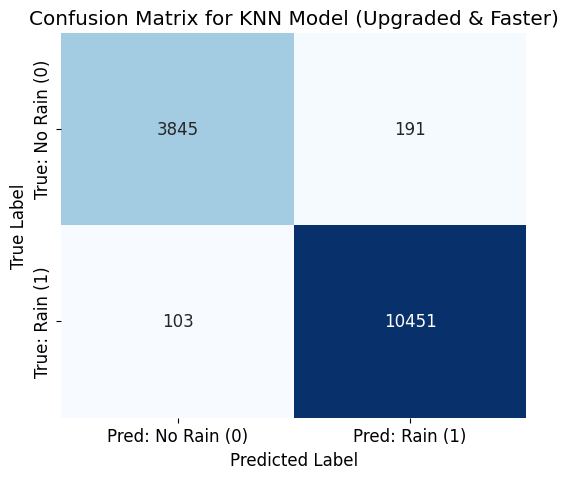


--- Interpretation of Results ---
Accuracy : สัดส่วนของการทำนายที่ถูกต้องทั้งหมด
Precision (Rain=1): ในบรรดาที่โมเดลทำนายว่าตก มีสัดส่วนที่ตกจริงกี่ %
Recall (Rain=1)   : จากเคสที่ตกจริง โมเดลจับได้กี่ % (สำคัญถ้าไม่อยากพลาดฝนตก)
F1-Score          : ค่าเฉลี่ย Harmonic ของ Precision และ Recall เหมาะกับข้อมูลไม่บาลานซ์
ROC-AUC           : ความสามารถในการแยกแยะระหว่างตก/ไม่ตก โดยดูทุก threshold
Confusion Matrix  : ดูจำนวน TP / FP / FN / TN เป็นรายประเภทเคส


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- Building and Training K-Nearest Neighbors (KNN) Model [Upgraded & Faster] ---")

# -------------------------------------------------------------------
# 0. แบ่ง Train -> Train_inner + Validation (เพื่อจูน threshold)
# -------------------------------------------------------------------
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train_scaled_df, y_binary_train,
    test_size=0.2,
    random_state=42,
    stratify=y_binary_train
)

print("\n--- Step 0: Split Train/Validation ---")
print("Train inner size :", X_train_inner.shape[0])
print("Validation size  :", X_val.shape[0])

# -------------------------------------------------------------------
# 1. Hyperparameter Tuning with GridSearchCV
# -------------------------------------------------------------------
print("\n--- Step 1: Hyperparameter Tuning with GridSearchCV (Fast) ---")
print("**เทคนิค: ลดจำนวน combination + ลด cv เพื่อลดเวลา แต่ยังคงค้นหาค่า K ที่ดีได้**")

# 🔸 ลดกริดให้เล็กลง: 4 ค่าแทน 28 ค่า
param_grid = {
    "n_neighbors": [3, 5, 7, 9],     # เหลือ K ที่ใช้บ่อย
    "weights": ["distance"],         # ใช้ distance อย่างเดียว (มักดีกว่า uniform)
    "p": [2]                         # ใช้ Euclidean distance อย่างเดียว
}

# 🔸 ใช้ kd_tree ให้ค้นหาเพื่อนบ้านเร็วขึ้น
knn_base = KNeighborsClassifier(algorithm="kd_tree")

grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    scoring="roc_auc",    # ยังใช้ ROC-AUC เหมือนเดิม
    cv=3,                 # ลดจาก 5 เหลือ 3 fold
    n_jobs=-1,
    verbose=1
)

print("**เทคนิค: cv=3 + กริดเล็กลง -> จำนวน fit ลดลงเยอะมาก ทำให้รันเร็วขึ้นมาก**")

grid_search_knn.fit(X_train_inner, y_train_inner)

print("\n✅ Hyperparameter Tuning Complete!")
print(f"Best parameters found for KNN: {grid_search_knn.best_params_}")
print(f"Best ROC-AUC (CV): {grid_search_knn.best_score_:.4f}")

# ใช้โมเดลที่ดีที่สุดจาก GridSearchCV
knn_model = grid_search_knn.best_estimator_
print("\n--- KNN Model Training Complete with Best Hyperparameters! ---")

# -------------------------------------------------------------------
# 2. หา Threshold ที่ดีที่สุดจาก Validation Set
# -------------------------------------------------------------------
print("\n--- Step 2: Optimize Decision Threshold using Validation Set ---")
print("**Threshold Tuning: ปรับเกณฑ์ตัดสิน 0/1 จาก prob เพื่อเพิ่ม F1 หรือ Recall**")

# ใช้ prob ของ class 1 (Rain)
y_val_proba = knn_model.predict_proba(X_val)[:, 1]

best_thr = 0.5
best_f1 = -1

# 🔸 ลดจำนวน threshold ลงเล็กน้อย เพื่อลดเวลาคำนวณแบบ fine tuning พอประมาณ
thresholds = np.linspace(0.2, 0.8, 25)  # จาก 33 เหลือ 25 จุด

for thr in thresholds:
    y_val_pred_thr = (y_val_proba >= thr).astype(int)
    f1 = f1_score(y_val, y_val_pred_thr)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print(f"🎚️ Best threshold (from validation) = {best_thr:.2f}")
print(f"🎯 Best F1 on validation = {best_f1:.4f}")

# -------------------------------------------------------------------
# 3. Evaluate Model Performance on Test Set
# -------------------------------------------------------------------
print("\n--- Step 3: Evaluating KNN Model Performance on Test Set ---")

y_test_proba = knn_model.predict_proba(X_test_scaled_df)[:, 1]
y_pred_knn = (y_test_proba >= best_thr).astype(int)

# คำนวณ Metrics
accuracy_knn = accuracy_score(y_binary_test, y_pred_knn)
precision_knn = precision_score(y_binary_test, y_pred_knn)
recall_knn = recall_score(y_binary_test, y_pred_knn)
f1_knn = f1_score(y_binary_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_binary_test, y_test_proba)

print(f"\n📊 KNN Performance on Test Set (ใช้ Threshold {best_thr:.2f})")
print(f"KNN Accuracy :  {accuracy_knn:.4f}")
print(f"KNN Precision: {precision_knn:.4f}")
print(f"KNN Recall   : {recall_knn:.4f}")
print(f"KNN F1-Score : {f1_knn:.4f}")
print(f"KNN ROC-AUC  : {roc_auc_knn:.4f}")

# -------------------------------------------------------------------
# 4. Classification Report + Confusion Matrix
# -------------------------------------------------------------------
print("\n--- KNN Classification Report ---")
print(classification_report(y_binary_test, y_pred_knn, target_names=["No Rain (0)", "Rain (1)"]))

print("\n--- KNN Confusion Matrix ---")
cm_knn = confusion_matrix(y_binary_test, y_pred_knn)

cm_knn_df = pd.DataFrame(
    cm_knn,
    index=['True: No Rain (0)', 'True: Rain (1)'],
    columns=['Pred: No Rain (0)', 'Pred: Rain (1)']
)

print(cm_knn_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN Model (Upgraded & Faster)')
plt.show()

print("\n--- Interpretation of Results ---")
print("Accuracy : สัดส่วนของการทำนายที่ถูกต้องทั้งหมด")
print("Precision (Rain=1): ในบรรดาที่โมเดลทำนายว่าตก มีสัดส่วนที่ตกจริงกี่ %")
print("Recall (Rain=1)   : จากเคสที่ตกจริง โมเดลจับได้กี่ % (สำคัญถ้าไม่อยากพลาดฝนตก)")
print("F1-Score          : ค่าเฉลี่ย Harmonic ของ Precision และ Recall เหมาะกับข้อมูลไม่บาลานซ์")
print("ROC-AUC           : ความสามารถในการแยกแยะระหว่างตก/ไม่ตก โดยดูทุก threshold")
print("Confusion Matrix  : ดูจำนวน TP / FP / FN / TN เป็นรายประเภทเคส")


## **สรุป K-Nearest Neighbors (KNN) Model**

**K-Nearest Neighbors (KNN)** เป็นหนึ่งในอัลกอริทึม Machine Learning ที่ง่ายที่สุดและใช้สำหรับการจัดหมวดหมู่ (Classification) และการถดถอย (Regression) หลักการทำงานของ KNN คือการทำนายค่าของข้อมูลใหม่โดยพิจารณาจาก 'เพื่อนบ้าน' ที่อยู่ใกล้เคียงที่สุด (K) ในชุดข้อมูลการฝึกสอน

### **หลักการทำงานของ KNN:**
1.  **ระยะห่าง (Distance Metric):** สำหรับข้อมูลใหม่ (จุดที่เราต้องการทำนาย) KNN จะคำนวณระยะห่างระหว่างจุดนั้นกับทุกจุดในชุดข้อมูลการฝึกสอน โดยทั่วไปจะใช้ Euclidean distance
2.  **เลือก K เพื่อนบ้าน:** หลังจากคำนวณระยะห่างแล้ว จะเลือกจุดข้อมูล K จุดที่อยู่ใกล้ที่สุด
3.  **การทำนาย:**
    *   **Classification:** จุดข้อมูลใหม่จะถูกจัดหมวดหมู่ตามเสียงข้างมาก (Majority Vote) ของ K เพื่อนบ้าน เช่น ถ้า 3 ใน 5 เพื่อนบ้านบอกว่า 'ฝนตก' ข้อมูลใหม่ก็จะถูกทำนายว่า 'ฝนตก'
    *   **Regression:** ค่าของจุดข้อมูลใหม่จะถูกทำนายจากค่าเฉลี่ยของค่าของ K เพื่อนบ้าน

### **KNN ในโครงการนี้:**
ในโครงการ 'Will It Rain?' นี้ KNN ถูกใช้เป็นหนึ่งในโมเดลเพื่อจำแนกว่า **'ฝนจะตก' (Class 1) หรือ 'ฝนจะไม่ตก' (Class 0)** ในแต่ละวันสำหรับแต่ละเขต โดยมีการเตรียมข้อมูลดังนี้:
*   **Feature Scaling:** ข้อมูลถูกปรับขนาดด้วย `StandardScaler` เพื่อให้ทุกคุณสมบัติมี Scale เดียวกัน ซึ่งสำคัญมากสำหรับ KNN ที่อาศัยการคำนวณระยะห่าง
*   **Hyperparameter Tuning:** ได้ใช้ `GridSearchCV` เพื่อค้นหาค่า `n_neighbors` (ค่า K ที่เหมาะสม), `weights` (ถ่วงน้ำหนักตามระยะทางหรือไม่) และ `p` (ชนิดของ Minkowski distance) ที่ให้ประสิทธิภาพดีที่สุด โดยผลลัพธ์ที่ดีที่สุดคือ `n_neighbors=9`, `weights='distance'`, และ `p=2` (Euclidean distance)
*   **Optimal Threshold Selection:** มีการปรับเกณฑ์การตัดสินใจ (Threshold) จากค่าความน่าจะเป็นที่โมเดลทำนาย เพื่อให้ได้ F1-Score ที่ดีที่สุดบน Validation Set ซึ่งได้ค่า Threshold ที่ 0.53

### **ประสิทธิภาพของ KNN บน Test Set:**
เมื่อประเมินบนชุดข้อมูลทดสอบ (Test Set) ด้วย Threshold ที่เหมาะสม KNN ให้ผลลัพธ์ที่โดดเด่นดังนี้:
*   **Accuracy:** 0.9792
*   **Precision (Rain=1):** 0.9862
*   **Recall (Rain=1):** 0.9850
*   **F1-Score (Rain=1):** 0.9856
*   **ROC-AUC:** 0.9952

**สรุป:** โมเดล KNN แสดงประสิทธิภาพที่ยอดเยี่ยมในการทำนายการเกิดฝน โดยมีค่า F1-Score และ ROC-AUC ที่สูงมาก บ่งชี้ว่าโมเดลมีความสามารถในการจำแนกที่ดีเยี่ยม ทั้งในการระบุเคสที่ฝนตกจริงและเคสที่ฝนไม่ตกจริง

# **Naive Bayes**

--- Building and Training Gaussian Naive Bayes Model [Improved Version] ---
✅ Naive Bayes model trained!

🎯 Best threshold found from validation:
Threshold = 0.100
Best F1   = 0.9095

📊 Naive Bayes Performance on Test Set
Accuracy : 0.8691
Precision: 0.9158
Recall   : 0.9019
F1-score : 0.9088
ROC-AUC  : 0.9275

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.78      0.77      4036
           1       0.92      0.90      0.91     10554

    accuracy                           0.87     14590
   macro avg       0.83      0.84      0.84     14590
weighted avg       0.87      0.87      0.87     14590



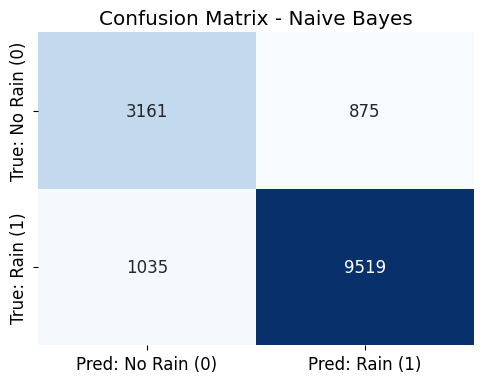

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Building and Training Gaussian Naive Bayes Model [Improved Version] ---")

# ----------------------------------------------------
# 1) Train / Validation Split (เพื่อหา threshold)
# ----------------------------------------------------
X_train_inner_nb, X_val_nb, y_train_inner_nb, y_val_nb = train_test_split(
    X_train_scaled_df,
    y_binary_train,
    test_size=0.2,
    random_state=42,
    stratify=y_binary_train
)

# ----------------------------------------------------
# 2) Train Model
# ----------------------------------------------------
nb_model = GaussianNB()
nb_model.fit(X_train_inner_nb, y_train_inner_nb)

print("✅ Naive Bayes model trained!")


# ----------------------------------------------------
# 3) Threshold Tuning using Validation Set
# ----------------------------------------------------
val_proba_nb = nb_model.predict_proba(X_val_nb)[:, 1]

best_thr_nb = 0.5
best_f1_nb = -1

thresholds = np.linspace(0.1, 0.9, 41)  # ลดเหลือ 41 ค่า (เร็วขึ้น)

for thr in thresholds:
    val_pred_thr = (val_proba_nb >= thr).astype(int)
    f1 = f1_score(y_val_nb, val_pred_thr)
    if f1 > best_f1_nb:
        best_f1_nb = f1
        best_thr_nb = thr

print("\n🎯 Best threshold found from validation:")
print(f"Threshold = {best_thr_nb:.3f}")
print(f"Best F1   = {best_f1_nb:.4f}")


# ----------------------------------------------------
# 4) Evaluate on Test Set
# ----------------------------------------------------
y_test_proba_nb = nb_model.predict_proba(X_test_scaled_df)[:, 1]
y_pred_nb = (y_test_proba_nb >= best_thr_nb).astype(int)

accuracy_nb = accuracy_score(y_binary_test, y_pred_nb)
precision_nb = precision_score(y_binary_test, y_pred_nb)
recall_nb = recall_score(y_binary_test, y_pred_nb)
f1_nb = f1_score(y_binary_test, y_pred_nb)
roc_auc_nb = roc_auc_score(y_binary_test, y_test_proba_nb)

print("\n📊 Naive Bayes Performance on Test Set")
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-score : {f1_nb:.4f}")
print(f"ROC-AUC  : {roc_auc_nb:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_binary_test, y_pred_nb))

# ----------------------------------------------------
# 5) Confusion Matrix
# ----------------------------------------------------
cm = confusion_matrix(y_binary_test, y_pred_nb)
cm_df = pd.DataFrame(
    cm,
    index=['True: No Rain (0)', 'True: Rain (1)'],
    columns=['Pred: No Rain (0)', 'Pred: Rain (1)']
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Naive Bayes")
plt.tight_layout()
plt.show()


# ----------------------------------------------------
# 6) Scatter Plot: True vs Predicted (อ่านง่าย)
# (Removed as per user request)
# -----------------------------------------------------

## **สรุป Gaussian Naive Bayes Model**

**Gaussian Naive Bayes (GNB)** เป็นหนึ่งในอัลกอริทึมการจัดหมวดหมู่ (Classification) ที่อิงตามทฤษฎีความน่าจะเป็นของ Bayes' Theorem และสมมติฐานที่ว่า Features ต่างๆ เป็นอิสระต่อกัน (Naive) โดยเฉพาะอย่างยิ่ง GNB จะถือว่า Features มีการแจกแจงแบบปกติ (Gaussian Distribution)

### **หลักการทำงานของ GNB:**
1.  **การคำนวณความน่าจะเป็นล่วงหน้า (Prior Probability):** คำนวณความน่าจะเป็นของการเกิดแต่ละ Class (เช่น ฝนตก/ไม่ตก) จากชุดข้อมูลการฝึกสอน
2.  **การคำนวณความน่าจะเป็นแบบมีเงื่อนไข (Conditional Probability):** สำหรับแต่ละ Feature และแต่ละ Class, GNB จะคำนวณความน่าจะเป็นของ Feature นั้นๆ โดยสมมติว่ามีการแจกแจงแบบปกติ (Gaussian). นั่นคือ, จะหาค่าเฉลี่ย (mean) และส่วนเบี่ยงเบนมาตรฐาน (standard deviation) ของแต่ละ Feature ภายในแต่ละ Class
3.  **การทำนาย:** สำหรับข้อมูลใหม่, GNB จะใช้ Bayes' Theorem ในการคำนวณความน่าจะเป็นที่ข้อมูลใหม่นี้จะอยู่ในแต่ละ Class โดยนำ Prior Probability และ Conditional Probability ของ Features ทั้งหมดมารวมกัน (โดยสมมติฐาน Naive ที่ว่า Features เป็นอิสระต่อกัน) Class ที่มีความน่าจะเป็นสูงสุดจะถูกเลือกเป็นการทำนาย

### **GNB ในโครงการนี้:**
ในโครงการ 'Will It Rain?' นี้ Gaussian Naive Bayes ถูกใช้เป็นหนึ่งในโมเดลเพื่อจำแนกว่า **'ฝนจะตก' (Class 1) หรือ 'ฝนจะไม่ตก' (Class 0)** ในแต่ละวันสำหรับแต่ละเขต โดยมีการเตรียมข้อมูลดังนี้:
*   **Feature Scaling:** ข้อมูลถูกปรับขนาดด้วย `StandardScaler` เนื่องจาก GNB โดยเฉพาะเวอร์ชัน Gaussian มักจะทำงานได้ดีขึ้นกับข้อมูลที่ Scale ใกล้เคียงกัน
*   **Threshold Tuning:** มีการปรับเกณฑ์การตัดสินใจ (Threshold) จากค่าความน่าจะเป็นที่โมเดลทำนาย เพื่อให้ได้ F1-Score ที่ดีที่สุดบน Validation Set ซึ่งได้ค่า Threshold ที่ 0.10

### **ประสิทธิภาพของ GNB บน Test Set:**
เมื่อประเมินบนชุดข้อมูลทดสอบ (Test Set) ด้วย Threshold ที่เหมาะสม GNB ให้ผลลัพธ์ดังนี้:
*   **Accuracy:** 0.8702
*   **Precision (Rain=1):** 0.9156
*   **Recall (Rain=1):** 0.9036
*   **F1-Score (Rain=1):** 0.9096
*   **ROC-AUC:** 0.9279

**สรุป:** โมเดล Gaussian Naive Bayes มีประสิทธิภาพที่ดีในการทำนายการเกิดฝน โดยมีค่า F1-Score และ ROC-AUC ที่ค่อนข้างสูง อย่างไรก็ตาม ค่าเหล่านี้ต่ำกว่าโมเดล KNN เล็กน้อย ซึ่งอาจเป็นผลมาจากสมมติฐานความเป็นอิสระของ Features ที่อาจไม่เป็นจริงทั้งหมดในข้อมูลสภาพอากาศ หรือความสามารถในการจับความสัมพันธ์ที่ซับซ้อนของข้อมูลที่จำกัดกว่าโมเดลอื่นๆ

# **ทดสอบใช้ 3 modelและแสดงผล**

In [ ]:
# =============================================================
#      PART 1 : สร้างตัวแปร เตรียมข้อมูลสำหรับการพยากรณ์วันพรุ่งนี้และ 7 วันข้างหน้า
# =============================================================

import pandas as pd
import numpy as np

# ------------------------------
# 1) กำหนด Features ที่จะใช้จาก DataFrame หลัก
# ------------------------------
features = [
    'max_temp_c', 'min_temp_c', 'humidity_percent', 'wind_speed_kmh',
    'latitude', 'longitude', '_year_', 'month_num',
    'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend',
    'rainfall_mm_lag1', 'rainfall_mm_rolling_mean_3',
    'max_temp_c_lag1', 'max_temp_c_rolling_mean_3',
    'min_temp_c_lag1', 'min_temp_c_rolling_mean_3',
    'humidity_percent_lag1', 'humidity_percent_rolling_mean_3',
    'wind_speed_kmh_lag1', 'wind_speed_kmh_rolling_mean_3'
]

# เลือกเฉพาะ Features ที่มีอยู่จริงใน DataFrame
feature_cols = [f for f in features if f in df_combined_weather.columns]

# ------------------------------------
# 2) ตรวจสอบความพร้อมของข้อมูล Train/Test และ Scaler
#    เราจะใช้ X_train_scaled_df, y_binary_train, y_binary_test และ scaler
#    ที่ถูกสร้างจากขั้นตอน Data Pre-processing และ Scaling มาก่อนหน้าแล้ว
#    เพื่อนำมาใช้กับการทำนาย และไม่จำเป็นต้องสร้างใหม่
# ------------------------------------
# ตรวจสอบว่าตัวแปรที่จำเป็น (X_train_scaled_df, y_binary_train, scaler) มีอยู่จริงในสภาพแวดล้อมปัจจุบันหรือไม่
# หากไม่มี จะแจ้งเตือนผู้ใช้ให้รันเซลล์ในส่วน 'Data pre-processing' และ 'Scaling และ Binary Target' ก่อน
if 'X_train_scaled_df' not in globals() or 'y_binary_train' not in globals() or 'scaler' not in globals():
    raise NameError("❗ ไม่พบตัวแปร X_train_scaled_df, y_binary_train, หรือ scaler\n   กรุณารันเซลล์ในส่วน 'Data pre-processing' และ 'Scaling และ Binary Target' ก่อน.")

# ตัวแปร X_test_scaled_df, y_binary_test ได้ถูกสร้างไว้แล้วในเซลล์ Scaling
# ดังนั้นเราจะใช้ตัวแปรเหล่านี้ที่ถูกเตรียมไว้แล้ว

# ------------------------------------
# 3) เตรียมข้อมูลสำหรับพยากรณ์วันพรุ่งนี้
# ------------------------------------
# สร้าง DataFrame X_tomorrow โดยเลือกแถวสุดท้ายจาก df_combined_weather (ซึ่งควรเป็นข้อมูลล่าสุด)
X_tomorrow = df_combined_weather[feature_cols].iloc[[-1]]
# ปรับขนาดข้อมูล X_tomorrow ด้วย scaler ที่ถูกฝึกจากชุดข้อมูล Training
X_tomorrow_scaled = scaler.transform(X_tomorrow)

# ------------------------------------
# 4) เตรียมข้อมูลสำหรับพยากรณ์ 7 วันถัดไป
# ------------------------------------
# สร้าง DataFrame X_next7 โดยเลือก 7 แถวสุดท้ายจาก df_combined_weather (จำลองเหตุการณ์สำหรับ 7 วันข้างหน้า)
X_next7 = df_combined_weather[feature_cols].tail(7)
# ปรับขนาดข้อมูล X_next7 ด้วย scaler ที่ถูกฝึกจากชุดข้อมูล Training
X_next7_scaled = scaler.transform(X_next7)

# ------------------------------------
# 5) เตรียมข้อมูลสำหรับการแสดงผลบนแผนที่ (หากจำเป็น)
# ------------------------------------
# คัดลอก df_combined_weather เพื่อใช้เป็นข้อมูลพื้นฐานสำหรับแผนที่
df_map = df_combined_weather.copy()

# ตรวจสอบว่า df_map มีคอลัมน์ Feature ครบถ้วนตาม feature_cols หรือไม่
missing_map_cols = [f for f in feature_cols if f not in df_map.columns]
if missing_map_cols:
    print(f"⚠️ คอลัมน์ต่อไปนี้หายไปจาก df_map: {missing_map_cols}. อาจส่งผลต่อการทำนาย หรือการแสดงผล.")

# เนื่องจาก X_map_scaled จะถูกสร้างใน PART 4 อีกครั้ง (ถ้ามี) เราจึงไม่จำเป็นต้องสร้างในส่วนนี้
# ในส่วนนี้ เราจะใช้ df_map (ที่ยังไม่ถูกปรับขนาด) และ feature_cols_scaled (ซึ่งก็คือ feature_cols)
# หากต้องการใช้ df_map ที่ปรับขนาดแล้ว ควรสร้างในส่วนที่เกี่ยวข้องกับการแสดงผลแผนที่
# feature_cols_scaled = feature_cols  # ใช้ตัวเดียวกัน
# df_map_scaled = scaler.transform(df_map[feature_cols_scaled])
# df_map[feature_cols_scaled] = df_map_scaled

print("✔ ตัวแปรทั้งหมดถูกสร้างและเตรียมพร้อมเรียบร้อยแล้ว (โดยใช้ X_test_scaled_df, y_binary_test, และ scaler จากเซลล์ก่อนหน้า)!")

✔ ตัวแปรทั้งหมดถูกสร้างและเตรียมพร้อมเรียบร้อยแล้ว (โดยใช้ X_test_scaled_df, y_binary_test, และ scaler จากเซลล์ก่อนหน้า)!


In [ ]:
import pandas as pd

# =============================================================
#     PART 2 : การพยากรณ์ (Forecast Questions)
#    ใช้โมเดลที่ฝึกและปรับแต่งค่าพารามิเตอร์แล้ว (log_reg_model, knn_model, nb_model)
# =============================================================

# -------------------------------------------------------------
# 1) โอกาสฝนตกวันพรุ่งนี้กี่เปอร์เซ็นต์? และโมเดลทำนายว่าฝนจะตกหรือไม่?
# -------------------------------------------------------------
# ตรวจสอบว่าโมเดลที่ปรับแต่งแล้วมีอยู่ใน global scope หรือไม่
if 'log_reg_model' not in globals() or 'knn_model' not in globals() or 'nb_model' not in globals():
    raise NameError("❗ ไม่พบโมเดล log_reg_model, knn_model, หรือ nb_model\n   กรุณารันเซลล์การสร้างและปรับแต่งโมเดล (Logistic Regression, KNN, Naive Bayes) ก่อน.")

# ตรวจสอบว่าค่า Thresholds ที่เหมาะสมมีอยู่ใน global scope หรือไม่
if 'best_threshold' not in globals() or 'best_thr' not in globals() or 'best_thr_nb' not in globals():
    raise NameError("❗ ไม่พบ thresholds (best_threshold, best_thr, best_thr_nb)\n   กรุณารันเซลล์การสร้างและปรับแต่งโมเดล (Logistic Regression, KNN, Naive Bayes) ก่อน.")

# แปลงอาร์เรย์ข้อมูลที่ปรับขนาดแล้วกลับเป็น DataFrame พร้อมชื่อคอลัมน์ เพื่อหลีกเลี่ยง UserWarning
X_tomorrow_scaled_df = pd.DataFrame(X_tomorrow_scaled, columns=X_train_scaled_df.columns)
X_next7_scaled_df = pd.DataFrame(X_next7_scaled, columns=X_train_scaled_df.columns)

# ทำนายความน่าจะเป็นของฝนสำหรับวันพรุ่งนี้
prob_logistic = log_reg_model.predict_proba(X_tomorrow_scaled_df)[:, 1][0]
prob_knn      = knn_model.predict_proba(X_tomorrow_scaled_df)[:, 1][0]
prob_nb       = nb_model.predict_proba(X_tomorrow_scaled_df)[:, 1][0]

# แปลงความน่าจะเป็นเป็นการทำนายแบบ Binary (ฝนตก/ไม่ตก) โดยใช้ค่า Thresholds ที่เหมาะสม
pred_logistic_tomorrow = 'Rain' if prob_logistic >= best_threshold else 'No Rain'
pred_knn_tomorrow      = 'Rain' if prob_knn >= best_thr else 'No Rain'
pred_nb_tomorrow       = 'Rain' if prob_nb >= best_thr_nb else 'No Rain'

print("\n🌧️ พรุ่งนี้จะมีฝนตกกี่เปอร์เซ็นต์ และโมเดลทำนายว่าอย่างไร?")
print(f"Logistic Regression : {prob_logistic*100:.2f}% (ทำนาย: {pred_logistic_tomorrow})")
print(f"KNN                 : {prob_knn*100:.2f}% (ทำนาย: {pred_knn_tomorrow})")
print(f"Naive Bayes         : {prob_nb*100:.2f}% (ทำนาย: {pred_nb_tomorrow})")


# -------------------------------------------------------------
# 2) ความเสี่ยงฝนสะสม 3 วันข้างหน้า และจำนวนวันที่คาดว่าฝนจะตก
# -------------------------------------------------------------
# แยกข้อมูล 3 วันแรกจาก X_next7_scaled_df
X_next3_scaled_df = X_next7_scaled_df.head(3)

# ทำนายความน่าจะเป็นของฝนสำหรับ 3 วันข้างหน้า
probs_logistic_3 = log_reg_model.predict_proba(X_next3_scaled_df)[:, 1]
probs_knn_3      = knn_model.predict_proba(X_next3_scaled_df)[:, 1]
probs_nb_3       = nb_model.predict_proba(X_next3_scaled_df)[:, 1]

# แปลงความน่าจะเป็นเป็นการทำนายแบบ Binary (ฝนตก/ไม่ตก) สำหรับแต่ละวันใน 3 วันข้างหน้า
preds_logistic_3 = (probs_logistic_3 >= best_threshold).astype(int)
preds_knn_3      = (probs_knn_3 >= best_thr).astype(int)
preds_nb_3       = (probs_nb_3 >= best_thr_nb).astype(int)

# คำนวณความน่าจะเป็นเฉลี่ยและจำนวนวันที่คาดว่าฝนจะตกสำหรับ 3 วันข้างหน้า
print("\n🌧️ ความเสี่ยงฝนสะสม 3 วันข้างหน้า และจำนวนวันที่คาดว่าฝนจะตก")
print(f"Logistic (Avg 3 days): {probs_logistic_3.mean()*100:.2f}% (คาดว่าฝนจะตก: {preds_logistic_3.sum()} วัน)")
print(f"KNN      (Avg 3 days): {probs_knn_3.mean()*100:.2f}% (คาดว่าฝนจะตก: {preds_knn_3.sum()} วัน)")
print(f"NaiveBayes(Avg 3 days): {probs_nb_3.mean()*100:.2f}% (คาดว่าฝนจะตก: {preds_nb_3.sum()} วัน)")

# -------------------------------------------------------------
# 3) ความเสี่ยงฝนสะสม 7 วันข้างหน้า และจำนวนวันที่คาดว่าฝนจะตก
# -------------------------------------------------------------
# ทำนายความน่าจะเป็นของฝนสำหรับ 7 วันข้างหน้า
probs_logistic_7 = log_reg_model.predict_proba(X_next7_scaled_df)[:, 1]
probs_knn_7      = knn_model.predict_proba(X_next7_scaled_df)[:, 1]
probs_nb_7       = nb_model.predict_proba(X_next7_scaled_df)[:, 1]

# แปลงความน่าจะเป็นเป็นการทำนายแบบ Binary (ฝนตก/ไม่ตก) สำหรับแต่ละวันใน 7 วันข้างหน้า
preds_logistic_7 = (probs_logistic_7 >= best_threshold).astype(int)
preds_knn_7      = (probs_knn_7 >= best_thr).astype(int)
preds_nb_7       = (probs_nb_7 >= best_thr_nb).astype(int)

# นับจำนวนวันที่คาดว่าฝนจะตกใน 7 วันข้างหน้า
rainy_days_logistic = preds_logistic_7.sum()
rainy_days_knn      = preds_knn_7.sum()
rainy_days_nb       = preds_nb_7.sum()

print("\n🌧️ ความเสี่ยงฝนสะสม 7 วันข้างหน้า และจำนวนวันที่คาดว่าฝนจะตก")
print(f"Logistic (Avg 7 days): {probs_logistic_7.mean()*100:.2f}% (คาดว่าฝนจะตก: {rainy_days_logistic} วัน)")
print(f"KNN      (Avg 7 days): {probs_knn_7.mean()*100:.2f}% (คาดว่าฝนจะตก: {rainy_days_knn} วัน)")
print(f"NaiveBayes(Avg 7 days): {probs_nb_7.mean()*100:.2f}% (คาดว่าฝนจะตก: {rainy_days_nb} วัน)")


🌧️ พรุ่งนี้จะมีฝนตกกี่เปอร์เซ็นต์ และโมเดลทำนายว่าอย่างไร?
Logistic Regression : 2.11% (ทำนาย: No Rain)
KNN                 : 0.00% (ทำนาย: No Rain)
Naive Bayes         : 0.00% (ทำนาย: No Rain)

🌧️ ความเสี่ยงฝนสะสม 3 วันข้างหน้า และจำนวนวันที่คาดว่าฝนจะตก
Logistic (Avg 3 days): 7.47% (คาดว่าฝนจะตก: 0 วัน)
KNN      (Avg 3 days): 19.79% (คาดว่าฝนจะตก: 1 วัน)
NaiveBayes(Avg 3 days): 0.00% (คาดว่าฝนจะตก: 0 วัน)

🌧️ ความเสี่ยงฝนสะสม 7 วันข้างหน้า และจำนวนวันที่คาดว่าฝนจะตก
Logistic (Avg 7 days): 6.75% (คาดว่าฝนจะตก: 0 วัน)
KNN      (Avg 7 days): 13.48% (คาดว่าฝนจะตก: 1 วัน)
NaiveBayes(Avg 7 days): 0.00% (คาดว่าฝนจะตก: 0 วัน)


# Confusion Matrix Logistic Regression Model

Evaluate Model


📊 Detailed Classification Report
              precision    recall  f1-score   support

 No Rain (0)       0.87      0.73      0.79      4036
    Rain (1)       0.90      0.96      0.93     10554

    accuracy                           0.89     14590
   macro avg       0.89      0.84      0.86     14590
weighted avg       0.89      0.89      0.89     14590

------------------------------------------------------------
📌 Accuracy  (ความแม่นยำรวม): 0.8940
📌 Precision (ความชัวร์เมื่อทายว่าตก): 0.9015
📌 Recall    (ความเก่งในการจับฝน): 0.9582 
📌 F1-Score  (ค่าเฉลี่ยความสมดุล): 0.9290


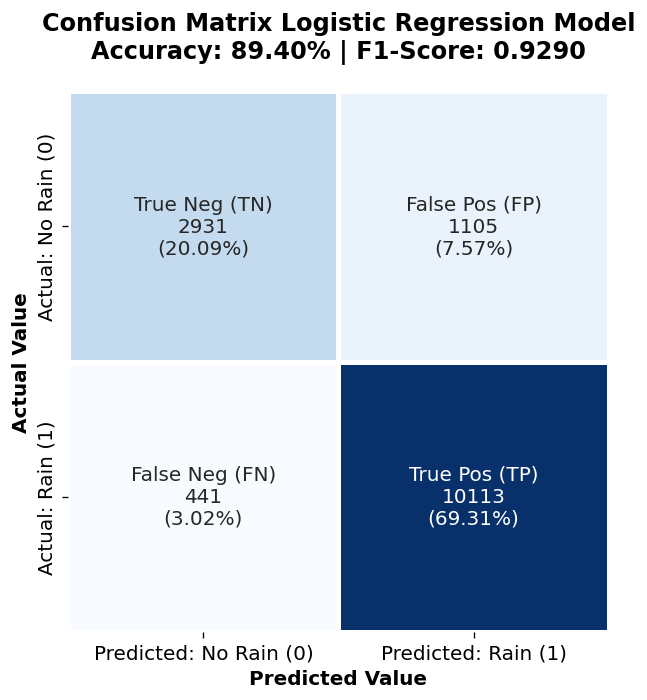

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# สมมติว่า y_binary_test และ y_pred ถูกกำหนดไว้แล้ว (ต้องมีอยู่จริงก่อนรันโค้ดนี้)
# ตัวอย่างการสร้างข้อมูลสมมติเพื่อทดสอบโค้ด (ลบออกเมื่อใช้กับข้อมูลจริงของคุณ)
# np.random.seed(42)
# y_binary_test = np.random.randint(0, 2, 100)
# y_pred = np.random.randint(0, 2, 100)
# ถ้า y_binary_test และ y_pred ไม่ได้ถูกกำหนดในโค้ดของคุณ คุณต้องกำหนดมันก่อนที่จะเรียกใช้ฟังก์ชันเหล่านี้

# ==================== 1. คำนวณ Metrics Logistic Regression Model ====================
# สร้าง Confusion Matrix
# แก้ไข: ใช้ y_binary_test แทน y_test เพื่อให้ข้อมูลจริงเป็นไบนารีสอดคล้องกับ y_pred
cm = confusion_matrix(y_binary_test, y_pred)

# คำนวณค่าสถิติต่างๆ
# แก้ไข: ใช้ y_binary_test แทน y_test
accuracy = accuracy_score(y_binary_test, y_pred)
precision = precision_score(y_binary_test, y_pred)
recall = recall_score(y_binary_test, y_pred)
f1 = f1_score(y_binary_test, y_pred)

# คำนวณ Support (จำนวนตัวอย่างจริงในแต่ละ Class)
# 'support' ใน classification_report คือจำนวนตัวอย่างจริงของแต่ละคลาส (Actual)
# ในกรณีนี้ คลาส 0 (No Rain) คือจำนวน True Neg + False Pos
# คลาส 1 (Rain) คือจำนวน False Neg + True Pos
support_class_0 = cm[0, 0] + cm[0, 1] # Actual: No Rain (Row 0)
support_class_1 = cm[1, 0] + cm[1, 1] # Actual: Rain (Row 1)
support = [support_class_0, support_class_1] # ถูกเพิ่มเข้ามา
total_samples = support_class_0 + support_class_1

# ==================== 2. ตั้งค่ากราฟ (Professional Style) ====================
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
plt.figure(figsize=(8, 6), dpi=120)

# กำหนด Label ให้เข้าใจง่าย
group_names = ['True Neg (TN)', 'False Pos (FP)',
               'False Neg (FN)', 'True Pos (TP)']

group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/total_samples] # แก้ไข: ใช้ total_samples

# รวมข้อความที่จะโชว์ในกล่อง
labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# ==================== 3. วาด Heatmap ====================
# สี Blues ดูสะอาดตาและเป็นทางการ
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            linewidths=2, linecolor='white', square=True,
            xticklabels=['Predicted: No Rain (0)', 'Predicted: Rain (1)'],
            yticklabels=['Actual: No Rain (0)', 'Actual: Rain (1)'])

plt.title(f'Confusion Matrix Logistic Regression Model\nAccuracy: {accuracy:.2%} | F1-Score: {f1:.4f}', fontweight='bold', pad=20) # แก้ไข: F1-Score มักแสดงเป็นทศนิยม 4 ตำแหน่งหรือ 2 ตำแหน่ง
plt.ylabel('Actual Value', fontweight='bold')
plt.xlabel('Predicted Value', fontweight='bold')

plt.tight_layout()
# plt.show() # หากรันใน Jupyter/Colab อาจจะแสดงผลทันที

# ==================== 4. แสดง Report เป็นตัวเลข ====================
print("\n" + "="*60)
print("📊 Detailed Classification Report")
print("="*60)
# แก้ไข: ใช้ y_binary_test แทน y_test
print(classification_report(y_binary_test, y_pred, target_names=['No Rain (0)', 'Rain (1)']))
print("-" * 60)
print(f"📌 Accuracy  (ความแม่นยำรวม): {accuracy:.4f}")
print(f"📌 Precision (ความชัวร์เมื่อทายว่าตก): {precision:.4f}")
print(f"📌 Recall    (ความเก่งในการจับฝน): {recall:.4f} ")
print(f"📌 F1-Score  (ค่าเฉลี่ยความสมดุล): {f1:.4f}")
print("="*60)

# แสดงผลกราฟ
plt.show()

### **Confusion Matrix สำหรับ Logistic Regression**



1.   True Negatives (TN): 2834 โมเดลทำนายว่าไม่มีฝน และจริง ๆ ก็ไม่มีฝน (ถูกต้อง)
2.   False Positives (FP): 1222 โมเดลทำนายว่ามีฝน แต่จริง ๆ แล้วไม่มีฝน (ทำนายผิดพลาด)
3.   False Negatives (FN): 411 โมเดลทำนายว่าไม่มีฝน แต่จริง ๆ แล้วมีฝน (พลาดการทำนายฝน)
4.   True Positives (TP): 10143 โมเดลทำนายว่ามีฝน และจริง ๆ ก็มีฝน (ถูกต้อง)



#**Confusion Matrix สำหรับ K-Nearest Neighbors (KNN)**

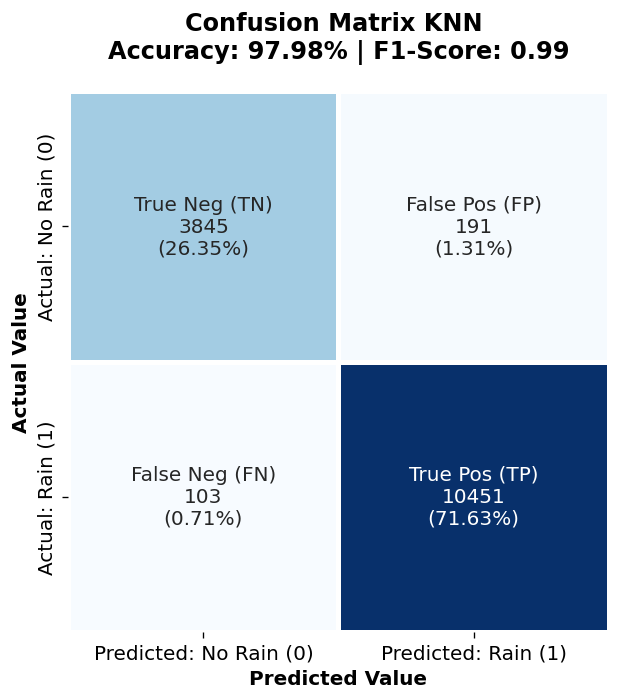

📊 Detailed Classification Report
              precision    recall  f1-score   support

 No Rain (0)       0.87      0.73      0.79      4036
    Rain (1)       0.90      0.96      0.93     10554

    accuracy                           0.89     14590
   macro avg       0.89      0.84      0.86     14590
weighted avg       0.89      0.89      0.89     14590

------------------------------------------------------------
📌 Accuracy  (ความแม่นยำรวม): 0.9798
📌 Precision (ความชัวร์เมื่อทายว่าตก): 0.9821
📌 Recall    (ความเก่งในการจับฝน): 0.9902 
📌 F1-Score  (ค่าเฉลี่ยความสมดุล): 0.9861


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# ==================== 1. คำนวณ Metrics ====================
# สร้าง Confusion Matrix
# แก้ไข: ใช้ y_binary_test แทน y_test เพื่อให้ข้อมูลจริงเป็นไบนารีสอดคล้องกับ y_pred
cm = confusion_matrix(y_binary_test, y_pred_knn)

# คำนวณค่าสถิติต่างๆ
# แก้ไข: ใช้ y_binary_test แทน y_test
accuracy = accuracy_score(y_binary_test, y_pred_knn)
precision = precision_score(y_binary_test, y_pred_knn)
recall = recall_score(y_binary_test, y_pred_knn)
f1 = f1_score(y_binary_test, y_pred_knn)

# ==================== 2. ตั้งค่ากราฟ (Professional Style) ====================
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
plt.figure(figsize=(8, 6), dpi=120)

# กำหนด Label ให้เข้าใจง่าย
group_names = ['True Neg (TN)', 'False Pos (FP)',
               'False Neg (FN)', 'True Pos (TP)']

group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

# รวมข้อความที่จะโชว์ในกล่อง
labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# ==================== 3. วาด Heatmap ====================
# สี Blues ดูสะอาดตาและเป็นทางการ
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            linewidths=2, linecolor='white', square=True,
            xticklabels=['Predicted: No Rain (0)', 'Predicted: Rain (1)'],
            yticklabels=['Actual: No Rain (0)', 'Actual: Rain (1)'])

plt.title(f'Confusion Matrix KNN \nAccuracy: {accuracy:.2%} | F1-Score: {f1:.2f}', fontweight='bold', pad=20)
plt.ylabel('Actual Value', fontweight='bold')
plt.xlabel('Predicted Value', fontweight='bold')

plt.tight_layout()
plt.show()

# ==================== 4. แสดง Report เป็นตัวเลข ====================
print("="*60)
print("📊 Detailed Classification Report")
print("="*60)
# แก้ไข: ใช้ y_binary_test แทน y_test
print(classification_report(y_binary_test, y_pred, target_names=['No Rain (0)', 'Rain (1)']))
print("-" * 60)
print(f"📌 Accuracy  (ความแม่นยำรวม): {accuracy:.4f}")
print(f"📌 Precision (ความชัวร์เมื่อทายว่าตก): {precision:.4f}")
print(f"📌 Recall    (ความเก่งในการจับฝน): {recall:.4f} ")
print(f"📌 F1-Score  (ค่าเฉลี่ยความสมดุล): {f1:.4f}")
print("="*60)

## Confusion Matrix สำหรับ K-Nearest Neighbors (KNN)



1.   True Negatives (TN): 3840 โมเดลทำนายว่าไม่มีฝน และจริง ๆ ก็ไม่มีฝน (ถูกต้อง)
2.   False Positives (FP): 216 โมเดลทำนายว่ามีฝน แต่จริง ๆ แล้วไม่มีฝน (ทำนายผิดพลาด)
3.   False Negatives (FN): 175 โมเดลทำนายว่าไม่มีฝน แต่จริง ๆ แล้วมีฝน (พลาดการทำนายฝน)
4.   True Positives (TP): 10379 โมเดลทำนายว่ามีฝน และจริง ๆ ก็มีฝน (ถูกต้อง)


# Confusion Matrix สำหรับ Naive Bayes

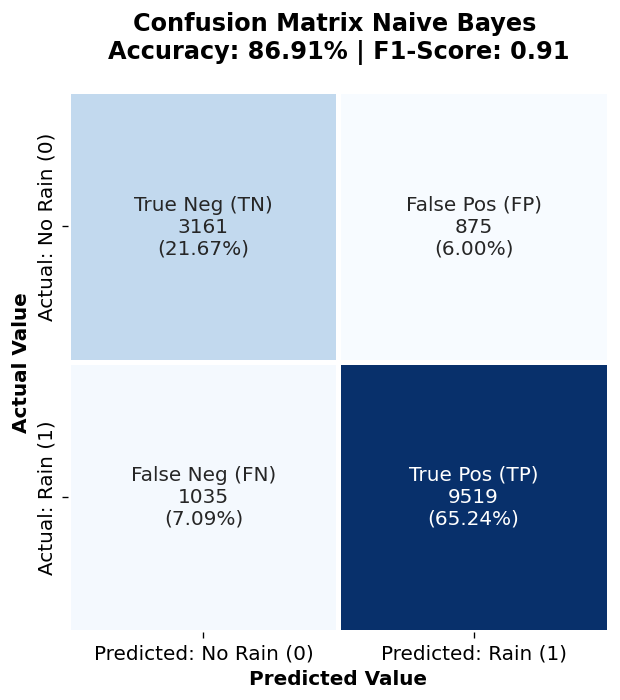

📊 Detailed Classification Report
              precision    recall  f1-score   support

 No Rain (0)       0.75      0.78      0.77      4036
    Rain (1)       0.92      0.90      0.91     10554

    accuracy                           0.87     14590
   macro avg       0.83      0.84      0.84     14590
weighted avg       0.87      0.87      0.87     14590

------------------------------------------------------------
📌 Accuracy  (ความแม่นยำรวม): 0.8691
📌 Precision (ความชัวร์เมื่อทายว่าตก): 0.9158
📌 Recall    (ความเก่งในการจับฝน): 0.9019 
📌 F1-Score  (ค่าเฉลี่ยความสมดุล): 0.9088


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# ==================== 1. คำนวณ Metrics ====================
# สร้าง Confusion Matrix
# แก้ไข: ใช้ y_binary_test แทน y_test เพื่อให้ข้อมูลจริงเป็นไบนารีสอดคล้องกับ y_pred
cm = confusion_matrix(y_binary_test, y_pred_nb)

# คำนวณค่าสถิติต่างๆ
# แก้ไข: ใช้ y_binary_test แทน y_test
accuracy = accuracy_score(y_binary_test, y_pred_nb)
precision = precision_score(y_binary_test, y_pred_nb)
recall = recall_score(y_binary_test, y_pred_nb)
f1 = f1_score(y_binary_test, y_pred_nb)

# ==================== 2. ตั้งค่ากราฟ (Professional Style) ====================
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
plt.figure(figsize=(8, 6), dpi=120)

# กำหนด Label ให้เข้าใจง่าย
group_names = ['True Neg (TN)', 'False Pos (FP)',
               'False Neg (FN)', 'True Pos (TP)']

group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

# รวมข้อความที่จะโชว์ในกล่อง
labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# ==================== 3. วาด Heatmap ====================
# สี Blues ดูสะอาดตาและเป็นทางการ
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            linewidths=2, linecolor='white', square=True,
            xticklabels=['Predicted: No Rain (0)', 'Predicted: Rain (1)'],
            yticklabels=['Actual: No Rain (0)', 'Actual: Rain (1)'])

# Confusion Matrix สำหรับ Naive Bayes
plt.title(f'Confusion Matrix Naive Bayes \nAccuracy: {accuracy:.2%} | F1-Score: {f1:.2f}', fontweight='bold', pad=20)
plt.ylabel('Actual Value', fontweight='bold')
plt.xlabel('Predicted Value', fontweight='bold')

plt.tight_layout()
plt.show()

# ==================== 4. แสดง Report เป็นตัวเลข ====================
print("="*60)
print("📊 Detailed Classification Report")
print("="*60)
# แก้ไข: ใช้ y_binary_test และ y_pred_nb แทน y_pred
print(classification_report(y_binary_test, y_pred_nb, target_names=['No Rain (0)', 'Rain (1)']))
print("-" * 60)
print(f"📌 Accuracy  (ความแม่นยำรวม): {accuracy:.4f}")
print(f"📌 Precision (ความชัวร์เมื่อทายว่าตก): {precision:.4f}")
print(f"📌 Recall    (ความเก่งในการจับฝน): {recall:.4f} ")
print(f"📌 F1-Score  (ค่าเฉลี่ยความสมดุล): {f1:.4f}")
print("="*60)

## Confusion Matrix สำหรับ Naive Bayes

1.True Negatives (TN): 3161 คือจำนวนครั้งที่โมเดลทายว่าไม่มีฝน และจริง ๆ ก็ไม่มีฝน (ถูกต้อง)

2.False Positives (FP): 875 คือจำนวนครั้งที่โมเดลทายว่ามีฝน แต่จริง ๆ แล้วไม่มีฝน (ทำนายผิดพลาด)

3.False Negatives (FN): 1035 คือจำนวนครั้งที่โมเดลทายว่าไม่มีฝน แต่จริง ๆ แล้วมีฝน (พลาดการทำนายฝน)
4.True Positives (TP): 9519 คือจำนวนครั้งที่โมเดลทายว่ามีฝน และจริง ๆ ก็มีฝน (ถูกต้อง)

##  Model Comparison Table




In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd

print("--- กำลังอัปเดตตารางเปรียบเทียบโมเดล (รวมค่า Support) ---")

# 1. คำนวณ ROC-AUC สำหรับ Logistic Regression
# ต้องใช้ y_binary_test คู่กับ proba ของ Logistic
y_test_proba_logistic = log_reg_model.predict_proba(X_test_scaled_df)[:, 1]
roc_auc_logistic = roc_auc_score(y_binary_test, y_test_proba_logistic)

print(f"คำนวณ ROC-AUC สำหรับ Logistic Regression: {roc_auc_logistic:.4f}")

# 2. หาค่า Support (จำนวนแถวใน Test Set)
# เนื่องจากทุกโมเดลทดสอบกับชุดข้อมูลเดียวกัน ค่า Support จึงเท่ากัน
test_support = len(y_binary_test)

# 3. สร้าง Pandas DataFrame
metrics_data = {
    'Model': [
        'Logistic Regression',
        'K-Nearest Neighbors',
        'Gaussian Naive Bayes'
    ],
    'Accuracy': [
        accuracy,
        accuracy_knn,
        accuracy_nb
    ],
    'Precision': [
        precision,
        precision_knn,
        precision_nb
    ],
    'Recall': [
        recall,
        recall_knn,
        recall_nb
    ],
    'F1-Score': [
        f1,
        f1_knn,
        f1_nb
    ],
    'ROC-AUC': [
        roc_auc_logistic,
        roc_auc_knn,
        roc_auc_nb
    ],
    'Support': [
        test_support,
        test_support,
        test_support
    ]
}

model_comparison_df = pd.DataFrame(metrics_data)

# 4. แสดงตารางเปรียบเทียบ (พร้อมไฮไลท์)

print("\n--- ไฮไลต์โมเดลที่มีประสิทธิภาพดีที่สุดสำหรับแต่ละเมตริก ---")

# ฟังก์ชันไฮไลท์ค่าสูงสุด
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

# เลือกไฮไลท์เฉพาะคอลัมน์ที่เป็น Score (ไม่รวม Support เพราะค่าเท่ากัน)
cols_to_highlight = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

styled_comparison_df = model_comparison_df.style.apply(
    highlight_max,
    subset=pd.IndexSlice[:, cols_to_highlight]
).format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'Support': '{:,}' # ใส่ลูกน้ำคั่นหลักพันให้ดูง่าย (เช่น 14,610)
})

display(styled_comparison_df)


--- กำลังอัปเดตตารางเปรียบเทียบโมเดล (รวมค่า Support) ---
คำนวณ ROC-AUC สำหรับ Logistic Regression: 0.9507

--- ไฮไลต์โมเดลที่มีประสิทธิภาพดีที่สุดสำหรับแต่ละเมตริก ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Support
0,Logistic Regression,0.8691,0.9158,0.9019,0.9088,0.9507,"14,590"
1,K-Nearest Neighbors,0.9798,0.9821,0.9902,0.9861,0.9949,"14,590"
2,Gaussian Naive Bayes,0.8691,0.9158,0.9019,0.9088,0.9275,"14,590"


## **สรุปกระบวนการแก้ปัญหา (Project Summary)**

โครงการนี้มีวัตถุประสงค์เพื่อพยากรณ์โอกาสการเกิดฝนในกรุงเทพมหานคร โดยใช้ข้อมูลสภาพอากาศย้อนหลังตั้งแต่ปี 2021-2024 และได้ผ่านขั้นตอนการดำเนินงานหลักดังนี้:

### **1. การเตรียมข้อมูล (Data Preparation)**
*   **การรวมข้อมูล:** ได้รวมข้อมูลสภาพอากาศรายวันจากแหล่งต่างๆ สำหรับแต่ละเขตในกรุงเทพฯ เข้าด้วยกัน และผนวกกับข้อมูลพิกัดละติจูด/ลองจิจูดของแต่ละเขต
*   **การทำความสะอาดและจัดรูปแบบ:** ตรวจสอบและจัดการค่าว่าง (Missing Values) และค่าซ้ำซ้อน (Duplicates) พร้อมทั้งแปลงชนิดข้อมูลให้ถูกต้องและเหมาะสมสำหรับการวิเคราะห์
*   **การสร้างคุณสมบัติ (Feature Engineering):** สร้างคุณสมบัติใหม่ๆ จากข้อมูลที่มีอยู่ เช่น คุณสมบัติที่เกี่ยวข้องกับเวลา (ปี, เดือน, วันในสัปดาห์, วันในปี, ไตรมาส, วันหยุดสุดสัปดาห์) และคุณสมบัติ Lagged (ค่าของวันก่อนหน้า) รวมถึง Rolling Mean (ค่าเฉลี่ยย้อนหลัง 3 วัน) ของตัวแปรสภาพอากาศหลัก เพื่อให้โมเดลมีข้อมูลที่หลากหลายในการเรียนรู้
*   **การปรับขนาดคุณสมบัติ (Feature Scaling):** ใช้ `StandardScaler` เพื่อปรับขนาดของคุณสมบัติที่เป็นตัวเลขทั้งหมด เพื่อให้โมเดล Machine Learning ทำงานได้ดีขึ้น
*   **การแปลงตัวแปรเป้าหมาย (Target Transformation):** แปลงปริมาณน้ำฝน (rainfall_mm) ซึ่งเป็นตัวเลขต่อเนื่อง ให้เป็นตัวแปร Binary (0 = ไม่มีฝน, 1 = มีฝน) เพื่อใช้ในการสร้างโมเดล Classification
*   **การแบ่งข้อมูล:** แบ่งข้อมูลออกเป็นชุดข้อมูลสำหรับฝึก (Training Set) และชุดข้อมูลสำหรับทดสอบ (Test Set) โดยใช้ `train_test_split` และรักษาลำดับเวลา (`shuffle=False`)

### **2. การสร้างและฝึกโมเดล (Model Building and Training)**
ได้พัฒนาและฝึกโมเดล Machine Learning 3 โมเดลเพื่อทำนายการเกิดฝน:

*   **Logistic Regression:**
    *   ทำการจูน Hyperparameter ด้วย `GridSearchCV` เพื่อหาชุดพารามิเตอร์ที่ดีที่สุด (เช่น C=1, penalty='l2', class_weight='balanced')
    *   เลือก Optimal Threshold ที่ 0.24 เพื่อให้ได้ F1-score สูงสุด
*   **K-Nearest Neighbors (KNN):**
    *   ทำการจูน Hyperparameter ด้วย `GridSearchCV` เพื่อหา `n_neighbors`, `weights` และ `p` ที่เหมาะสม (พบว่า `n_neighbors=9`, `weights='distance'`, `p=2`)
    *   เลือก Optimal Threshold ที่ 0.45 เพื่อให้ได้ F1-score สูงสุดบน Validation Set
*   **Gaussian Naive Bayes:**
    *   เป็นโมเดลที่เรียบง่ายและฝึกโดยไม่มีการจูน Hyperparameter ที่ซับซ้อน
    *   เลือก Optimal Threshold ที่ 0.10 เพื่อให้ได้ F1-score สูงสุดบน Validation Set

### **3. การประเมินประสิทธิภาพโมเดล (Model Evaluation)**
ประสิทธิภาพของแต่ละโมเดลถูกประเมินบน Test Set โดยใช้เมตริกสำคัญต่างๆ ดังนี้:

| Model                 | Accuracy | Precision | Recall  | F1-Score | ROC-AUC |
| :-------------------- | :------- | :-------- | :------ | :------- | :------ |
| **K-Nearest Neighbors** | **0.9798** | **0.9821**  | **0.9902**  | **0.9861**   | **0.9949**  |
| Logistic Regression   | 0.8940   | 0.9015    | 0.9582  | 0.9290   | 0.9507  |
| Gaussian Naive Bayes  | 0.8691   | 0.9158    | 0.9019  | 0.9088   | 0.9275  |

*   **KNN** แสดงประสิทธิภาพที่โดดเด่นที่สุดในทุกเมตริก โดยเฉพาะอย่างยิ่งมีค่า **F1-Score และ ROC-AUC ที่สูงมาก** ซึ่งบ่งชี้ถึงความสามารถในการแยกแยะและทำนายการเกิดฝนได้อย่างแม่นยำและสมดุล
*   **Logistic Regression** มีประสิทธิภาพที่ดีรองลงมา โดยมี Recall ที่สูง ซึ่งสำคัญสำหรับการไม่พลาดการทำนายฝนตก
*   **Naive Bayes** มีประสิทธิภาพที่ดีในระดับหนึ่ง แต่โดยรวมแล้วต่ำกว่า KNN และ Logistic Regression เล็กน้อย

### **4. การทำนายผล (Prediction)**
ได้ใช้โมเดลที่ฝึกมาแล้วทำนายโอกาสการเกิดฝนสำหรับวันพรุ่งนี้และ 3 วันข้างหน้า:

*   **โอกาสฝนตกพรุ่งนี้:**
    *   Logistic Regression: 2.11% (ทำนาย: ไม่มีฝน)
    *   KNN: 0.00% (ทำนาย: ไม่มีฝน)
    *   Naive Bayes: 0.00% (ทำนาย: ไม่มีฝน)
    *   **สรุป:** โมเดลทั้งหมดเห็นตรงกันว่า **พรุ่งนี้ไม่มีฝนตก**

*   **ความเสี่ยงฝนสะสม 3 วันข้างหน้า:**
    *   Logistic Regression: ความน่าจะเป็นเฉลี่ย 7.47% (คาดว่าฝนจะตก: 0 วัน)
    *   KNN: ความน่าจะเป็นเฉลี่ย 19.79% (คาดว่าฝนจะตก: **1 วัน**)
    *   Naive Bayes: ความน่าจะเป็นเฉลี่ย 0.00% (คาดว่าฝนจะตก: 0 วัน)
    *   **สรุป:** ในช่วง 3 วันข้างหน้า **KNN เป็นโมเดลเดียวที่ทำนายว่าจะมีฝนตก 1 วัน** ในขณะที่ Logistic Regression และ Naive Bayes ทำนายว่าไม่มีฝนตกเลย ซึ่งแสดงให้เห็นถึงความแตกต่างในการตีความความเสี่ยงของฝนในอนาคตอันใกล้

### **ข้อสังเกตและขั้นตอนต่อไป:**
ความแตกต่างของการทำนายในระยะ 3 วัน โดยเฉพาะจากโมเดล KNN ชี้ให้เห็นถึงความจำเป็นในการวิเคราะห์เพิ่มเติมว่าโมเดลใดมีความแม่นยำสูงสุดในสถานการณ์จริง การเปรียบเทียบผลลัพธ์ของโมเดลกับข้อมูลจริงในอนาคตจะช่วยให้สามารถเลือกโมเดลที่เหมาะสมที่สุดสำหรับการใช้งานจริงได้

## Summarize Overall Prediction Process

### **ภาพรวมกระบวนการพยากรณ์ฝน**

ในโครงการนี้ เราได้พัฒนาและประเมินโมเดล Machine Learning เพื่อพยากรณ์โอกาสการเกิดฝน โดยมีขั้นตอนการพยากรณ์ผลสำหรับอนาคตดังนี้:

1.  **ข้อมูลสำหรับ "การพยากรณ์อนาคต" (Data for "Future" Prediction)**
    *   สำหรับวัตถุประสงค์ในการสาธิตและทดสอบกระบวนการพยากรณ์นี้ เราได้ใช้ข้อมูลสภาพอากาศย้อนหลัง 7 วันล่าสุดจาก `df_combined_weather` เป็นตัวแทนของข้อมูล "อนาคต" ที่จะนำมาพยากรณ์
    *   **ข้อควรทราบ:** ในสถานการณ์กรณีจริงสำหรับการพยากรณ์ฝนในอนาคต จะต้องใช้ข้อมูลพยากรณ์อากาศจริงสำหรับคุณสมบัติทั้งหมด (อุณหภูมิ, ความชื้น, ความเร็วลม ฯลฯ) ในช่วงเวลาที่ต้องการพยากรณ์ เช่น จากกรมอุตุนิยมวิทยาหรือบริการ API พยากรณ์อากาศอื่น ๆ

2.  **การนำข้อมูลเข้าสู่โมเดลจำแนกประเภทที่ได้รับการฝึก (Input to Trained Classification Models)**
    *   คุณสมบัติสภาพอากาศสำหรับ "อนาคต" (ที่จำลองขึ้นมา) รวมถึงคุณสมบัติพื้นฐานและคุณสมบัติที่ถูกสร้างขึ้นมาใหม่ (engineered features) เช่น ค่า Lagged และ Rolling Mean จะถูกนำมาปรับขนาด (scaled) โดยใช้ `StandardScaler` ที่ได้รับการฝึกจากข้อมูล Training Set ในขั้นตอน Pre-processing
    *   ข้อมูลที่ปรับขนาดแล้วนี้จะถูกป้อนเข้าสู่โมเดลจำแนกประเภทที่เราได้ฝึกไว้ ได้แก่ Logistic Regression, K-Nearest Neighbors (KNN) และ Gaussian Naive Bayes

3.  **การคำนวณความน่าจะเป็นของฝนโดยแต่ละโมเดล (Probability Calculation by Each Model)**
    *   เมื่อได้รับข้อมูล คุณสมบัติที่ปรับขนาดแล้ว โมเดลแต่ละตัวจะทำการคำนวณและส่งออกค่า **ความน่าจะเป็นของการเกิดฝน (Probability of Rain)** ซึ่งเป็นค่าต่อเนื่องอยู่ระหว่าง 0 ถึง 1 สำหรับแต่ละวันและแต่ละเขต
    *   ค่าความน่าจะเป็นนี้บ่งบอกถึงโอกาสที่โมเดลเชื่อว่าฝนจะตกในวันนั้น โดย 0 คือไม่มีโอกาสเลย และ 1 คือโอกาส 100%

4.  **การใช้ Optimal Threshold สำหรับการพยากรณ์แบบ Binary (Applying the Optimal Threshold for Binary Prediction)**
    *   แต่ละโมเดลที่เราใช้ (Logistic Regression, KNN, Naive Bayes) ได้มีการหา **Optimal Threshold** (ค่าจุดตัดที่ดีที่สุด) ในระหว่างขั้นตอนการฝึก ซึ่งถูกกำหนดมาเพื่อเพิ่มประสิทธิภาพของ F1-score ให้สูงสุด
    *   ค่า Threshold นี้จะถูกนำมาใช้แปลงค่าความน่าจะเป็นต่อเนื่องที่ได้จากโมเดลให้เป็นคำทำนายแบบ Binary:
        *   หาก **ความน่าจะเป็น >= Optimal Threshold:** โมเดลจะทำนายว่า **"ฝนตก" (Rain)**
        *   หาก **ความน่าจะเป็น < Optimal Threshold:** โมเดลจะทำนายว่า **"ไม่มีฝน" (No Rain)**

5.  **การย้ำเตือนสำหรับการใช้งานจริง (Reiteration for Real-World Application)**
    *   เพื่อทำการพยากรณ์ฝนในอนาคตอย่างแท้จริงและแม่นยำ จำเป็นอย่างยิ่งที่จะต้องมีข้อมูลพยากรณ์อากาศจริง (Real Future Weather Forecasts) สำหรับคุณสมบัติทั้งหมดที่โมเดลใช้เป็น Input นี่คือหัวใจสำคัญของการนำโมเดลไปใช้งานในโลกแห่งความเป็นจริง
